# Podcast Emotion and Content Analysis

This project explores the linguistic, emotional, and topical characteristics of podcast episodes using Natural Language Processing (NLP) methods.  
By combining pre-trained language models and structured metadata, we aim to uncover the emotional tone, thematic categories, and audience alignment of each podcast episode.

Our pipeline operates at two complementary levels:
- **Turn-level analysis:** Emotion detection and safety tagging for individual speaker turns.
- **Episode-level analysis:** Aggregation of features to classify episodes into genres, estimate audience interests, and identify potentially unsafe content.


### Motivation

Podcasts are a rich and fast-growing medium, with content ranging from personal storytelling to political commentary.  
However, the scale and diversity of podcast data make manual analysis impractical.  

Automatic understanding of podcast episodes can support:
- **Listeners**, by improving recommendation and discovery systems.
- **Producers**, by providing insights into emotional tone and audience engagement.
- **Platforms**, by enabling automated content moderation and brand safety filtering.

Despite advances in text-based NLP, podcasts present unique challenges: conversational structure, speaker variability, and diverse topics.  
This project seeks to address these challenges by building an interpretable and scalable NLP pipeline tailored for podcast data.


### Project Goals

The primary objectives of this project are:

1. **Turn-level emotion detection** — Identify emotions (e.g., joy, anger, sadness) in each speaker turn using a pre-trained emotion recognition model.
2. **Episode-level categorization** — Classify each episode into broad categories such as *Technology*, *Comedy*, or *Politics*.
3. **Brand safety detection** — Flag episodes that contain unsafe or sensitive content, including hate speech, violence, or adult themes.
4. **Audience alignment prediction** — Estimate the likely audience or interest group best aligned with each episode based on its emotional and linguistic profile.

Collectively, these tasks aim to produce an interpretable summary of each episode — showing how speakers’ emotions, topics, and tone interact across the conversation.


### Expected Outcomes

By the end of this project, we aim to:
- Deliver a fully documented pipeline capable of processing large-scale podcast transcript data.
- Demonstrate emotion and safety predictions on speaker turns using transformer-based models.
- Aggregate turn-level features to classify and describe entire episodes.
- Provide interpretable summaries for each episode showing emotion distribution, category prediction, and safety assessment.

This proof of concept validates that pre-trained NLP models can be combined and scaled to perform fine-grained, multi-level podcast analysis.


## 1. Data Loading and Overview

To start, we'll load the sample datasets, `episodeLevelDataSample` and `speakerTurnDataSample`. The full datasets are over 20 GB, so we're using these smaller versions for the demonstration in this milestone.

In [1]:
import gzip
import json
import pandas as pd

episode_level = []
with gzip.open("data/episodeLevelDataSample.jsonl.gz", "rt", encoding="utf-8") as f:
    for line in f:
        episode_level.append(json.loads(line))

episode_df = pd.DataFrame(episode_level)

In [2]:
speakerTurn = []
with gzip.open("data/speakerTurnDataSample.jsonl.gz", "rt", encoding="utf-8") as f:
    for line in f:
        speakerTurn.append(json.loads(line))

speaker_df = pd.DataFrame(speakerTurn)

### Columns and Examples

#### Episode Level

The `episodeLevelDataSample` dataset provides metadata for each podcast episode in the sample, including information like the episode title, description, podcast title, and categories. The mp3url in this dataset is particularly important as it acts as a unique identifier for each episode, allowing us to link it with the corresponding speaker turn data later on. We'll use this data to understand the context of the speaker turns and potentially for tasks like episode classification and analysis based on episode-level features.

In [3]:
print("episodeLevelDataSample columns: ", episode_df.keys())

print("\n episodeLevelDataSample examples: ")
episode_df.sample(5) # Display 5 random samples from the dataset

episodeLevelDataSample columns:  Index(['transcript', 'rssUrl', 'epTitle', 'epDescription', 'mp3url',
       'podTitle', 'lastUpdate', 'itunesAuthor', 'itunesOwnerName', 'explicit',
       'imageUrl', 'language', 'createdOn', 'host', 'podDescription',
       'category1', 'category2', 'category3', 'category4', 'category5',
       'category6', 'category7', 'category8', 'category9', 'category10',
       'oldestEpisodeDate', 'episodeDateLocalized', 'durationSeconds',
       'hostPredictedNames', 'numUniqueHosts', 'guestPredictedNames',
       'numUniqueGuests', 'neitherPredictedNames', 'numUniqueNeithers',
       'mainEpSpeakers', 'numMainSpeakers', 'hostSpeakerLabels',
       'guestSpeakerLabels', 'overlapPropTurnCount', 'avgTurnDuration',
       'overlapPropDuration', 'totalSpLabels'],
      dtype='object')

 episodeLevelDataSample examples: 


,transcript,rssUrl,epTitle,epDescription,mp3url,podTitle,lastUpdate,itunesAuthor,itunesOwnerName,explicit,...,neitherPredictedNames,numUniqueNeithers,mainEpSpeakers,numMainSpeakers,hostSpeakerLabels,guestSpeakerLabels,overlapPropTurnCount,avgTurnDuration,overlapPropDuration,totalSpLabels
1372,(upbeat music) So while I will still send ema...,https://feeds.blubrry.com/feeds/worklessearnmo...,EP 22: Six-figure Launches With A TINY Listâ...,"<p dir='ltr'>When youâre selling online, mos...",https://media.blubrry.com/worklessearnmore/con...,"Work Less, Earn More",1697818146,Gillian Perkins,Gillian Perkins,0,...,NO_NEITHER_IDENTIFIED,0.0,"[SPEAKER_01, SPEAKER_02]",2.0,{'Gillian Perkins': 'SPEAKER_02'},{'Tarzan K': 'SPEAKER_01'},0.455128,16.546218,0.022528,3.0
7762,"Hello Ruthie. Hi, how are you? Good, good. We...",https://feeds.megaphone.fm/dittytv,Ruthie Foster,Those who have followed Ruthie Foster's eclect...,https://pdst.fm/e/p.podderapp.com/1394819820/c...,DittyTV's Insights | Music Interviews,1697450783,DittyTV,Ronnie Wright,0,...,NO_NEITHER_IDENTIFIED,0.0,"[SPEAKER_00, SPEAKER_01]",2.0,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,0.465116,5.016744,0.065706,2.0
5997,*Screaming* *GUNSHOT* *GUNSHOT* *GUNSHOT* *GU...,https://anchor.fm/s/14ae7b1c/podcast/rss,NIGHTTALES,Peek-Aboo--- Support this podcast: <a href='ht...,https://anchor.fm/s/14ae7b1c/podcast/play/1378...,BOSS&THEGUYS,1679655577,biggs,biggs,1,...,NO_NEITHER_IDENTIFIED,0.0,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE
4056,"(gentle music) - Hey everybody, welcome back....",https://anchor.fm/s/16b85090/podcast/rss,Preview Of COA's ( Children of Alcoholics ),<p><em>In this episode I am talking about Chil...,https://anchor.fm/s/16b85090/podcast/play/1475...,Yet here I am,1607284844,Roshelle DeSantis,Roshelle DeSantis,1,...,NO_NEITHER_IDENTIFIED,0.0,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE
4294,"Several years ago, I was on my retreat, my ye...",http://feeds.feedburner.com/StPiusXCatholicChu...,Fr Sean Homily May 17,Originally Broadcast 05/20/20 08:12pm (00h 07m...,https://podcdn.streamspot.com/d7a26c43ef_stpiu...,"St. Pius X Catholic Church, Portland, OR Podca...",1674460954,"St. Pius X Catholic Church, Portland, OR",Miller Paul,0,...,[Chris Cartwright],1.0,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE


#### Speaker Turn Level

The `speakerTurnDataSample` dataset contains information about individual speaker turns within each podcast episode. This includes the most important one which is the actual text spoken (`turnText`), the identified speaker, the start and end times of the turn, and the mp3url to link it back to the episode metadata in the episodeLevelDataSample.

In [4]:
print("speakerTurnDataSample columns: ", speaker_df.keys())

print("\n speakerTurnDataSample examples: ")
speaker_df.sample(5) # Display 5 random samples from the dataset

speakerTurnDataSample columns:  Index(['mfcc1_sma3Mean', 'mfcc2_sma3Mean', 'mfcc3_sma3Mean', 'mfcc4_sma3Mean',
       'F0semitoneFrom27.5Hz_sma3nzMean', 'F1frequency_sma3nzMean', 'turnText',
       'speaker', 'startTime', 'endTime', 'duration', 'mp3url', 'turnCount',
       'inferredSpeakerRole', 'inferredSpeakerName'],
      dtype='object')

 speakerTurnDataSample examples: 


,mfcc1_sma3Mean,mfcc2_sma3Mean,mfcc3_sma3Mean,mfcc4_sma3Mean,F0semitoneFrom27.5Hz_sma3nzMean,F1frequency_sma3nzMean,turnText,speaker,startTime,endTime,duration,mp3url,turnCount,inferredSpeakerRole,inferredSpeakerName
130606,1.571381,15.154355,28.479527,-1.476687,10.396277,528.357623,it,[SPEAKER_03],1617.22,1617.46,0.24,https://media.transistor.fm/13b53fd9/7204ad75.mp3,381,NO_INFERRED_ROLE,NO_INFERRED_SPEAKER
7387,21.733039,3.387668,9.818747,-10.458186,19.092301,609.532456,"watching it, they were like, ""Oh shit, she wa...","[SPEAKER_02, SPEAKER_00]",4224.08,4226.61,2.53,https://mcdn.podbean.com/mf/web/llr1w0/Episode...,1152,NO_INFERRED_ROLE,NO_INFERRED_SPEAKER
173396,24.371205,4.882602,32.208990,25.204119,15.645896,700.882793,desert,"[SPEAKER_01, SPEAKER_02]",2722.88,2723.53,0.65,https://anchor.fm/s/3e1c571c/podcast/play/2193...,827,NO_INFERRED_ROLE,NO_INFERRED_SPEAKER
63012,21.908148,-0.155043,19.156253,5.448112,18.382639,622.409826,"I think as you peel another layer back, their...",[SPEAKER_01],525.24,531.82,6.58,https://t.subsplash.com/r/aHR0cHM6Ly9jZG4uc3Vi...,89,NO_INFERRED_ROLE,NO_INFERRED_SPEAKER
145011,19.876078,5.950826,22.781061,-16.051385,23.020104,666.083847,"Well, there's no sort of fixation on me where...",[SPEAKER_01],4435.04,4443.61,8.57,https://anchor.fm/s/d6150dc/podcast/play/14065...,256,NO_INFERRED_ROLE,NO_INFERRED_SPEAKER


Given the large number of columns in these datasets, we want to select a subset of columns from each that are relevant to our analysis and discard the rest.

## 2. Data Preprocessing

In this section, we perform a series of preprocessing steps to prepare the dataset for downstream analysis and modeling.

The primary objective is to retain only the most relevant information from the raw `speakerTurnData` and `episodeLevelData` sources while ensuring that textual fields — particularly `turnText` — are clean, standardized, and ready for the tasks.

This involves:

* Selecting key columns that capture speaker and episode metadata.
* Cleaning and normalizing text data to remove noise (e.g., music markers, punctuation, excess whitespace).
* Filtering out irrelevant or empty content.
* Aggregating speaker turns and merging with episode-level information for a unified dataset.

### 2.1 Select Relevant Columns (Speaker-Turn Data)
We extract a subset of columns from the original dataset to create a compact version containing the most informative features for each speaker turn.

| Column                  | Description                                                |
| :---------------------- | :--------------------------------------------------------- |
| **turnText**            | Transcribed text of the speaker’s turn                     |
| **speaker**             | Identifier for the speaker                                 |
| **mp3url**              | Link to the episode (useful for grouping turns by episode) |
| **turnCount**           | Sequential position of the turn within an episode          |
| **inferredSpeakerRole** | Predicted speaker role (e.g., host, guest)                 |
| **startTime**           | Start time of a turn                                       |
| **endTime**             | End time of a turn                                         |


In [5]:
cols = ['turnText', 'speaker', 'mp3url', 'turnCount', 'inferredSpeakerRole',  'startTime', 'endTime']
speaker_df1 = pd.DataFrame(speakerTurn)[cols].copy()

speaker_df1[:20]

,turnText,speaker,mp3url,turnCount,inferredSpeakerRole,startTime,endTime
0,I'm Simon Shapiro and this is Sing Out Speak ...,[SPEAKER_00],https://www.buzzsprout.com/783020/4252475-best...,1,host,0.00,60.00
1,I'm Simon Shapiro and this is Sing Out Speak ...,[SPEAKER_00],https://www.buzzsprout.com/783020/4165286-it-s...,1,host,0.00,78.16
2,Music] [Music] [Music] [Music] [Music] [,[SPEAKER_02],https://www.buzzsprout.com/783020/4165286-it-s...,2,NO_INFERRED_ROLE,78.16,115.31
3,Music] [Music] [Music] [Music] [Music] [Music]...,[SPEAKER_01],https://www.buzzsprout.com/783020/4165286-it-s...,3,NO_INFERRED_ROLE,115.31,360.16
4,I'm Simon Shapiro and this is Sing Out Speak ...,[SPEAKER_05],https://www.buzzsprout.com/783020/3983942-toda...,1,host,0.00,36.99
5,.,"[SPEAKER_05, SPEAKER_00]",https://www.buzzsprout.com/783020/3983942-toda...,2,NO_INFERRED_ROLE,36.99,37.44
6,Well hello everyone and welcome,[SPEAKER_00],https://www.buzzsprout.com/783020/3983942-toda...,3,NO_INFERRED_ROLE,37.44,42.42
7,to Sing Out Speak Out episode number 20. I kn...,[SPEAKER_05],https://www.buzzsprout.com/783020/3983942-toda...,4,host,42.42,162.76
8,Music] [Music] [Music] [Music] [Music] [,[SPEAKER_01],https://www.buzzsprout.com/783020/3983942-toda...,5,NO_INFERRED_ROLE,162.76,172.76
9,Music] [Music] [Music] [Music] [Music] [Music]...,[SPEAKER_02],https://www.buzzsprout.com/783020/3983942-toda...,6,NO_INFERRED_ROLE,172.76,203.64


In [6]:
print(f"Total number of turns: {len(speaker_df1)}")
average_text_length = speaker_df1['turnText'].str.len().mean()
print(f"Average turn text length: {average_text_length:.2f}")
average_word_length = speaker_df1['turnText'].apply(lambda x: len(str(x).split())).mean()
print(f"Average number of words: {average_word_length:.2f}")

Total number of turns: 200000
Average turn text length: 160.21
Average number of words: 30.63


#### 2.1.1 Distribution of Turn Text Lengths

This histogram shows the distribution of the length of each speaker turn in characters. A logarithmic scale is used on the x-axis to accommodate the wide range of turn lengths, including some very long turns. Understanding turn length distribution is important for selecting appropriate NLP models and processing strategies.

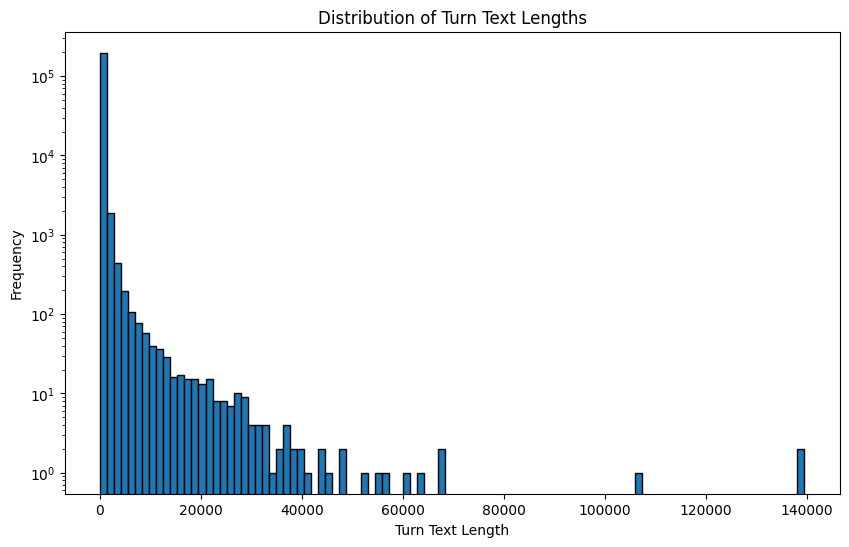

In [7]:
import matplotlib.pyplot as plt

# Plot a histogram of the turn text lengths
turn_lengths = speaker_df1['turnText'].str.len().tolist()
plt.figure(figsize=(10, 6))
plt.hist(turn_lengths, bins=100, edgecolor='black')
plt.xlabel('Turn Text Length')
plt.ylabel('Frequency')
plt.yscale('log')
plt.title('Distribution of Turn Text Lengths')
plt.show()

#### 2.1.2 Top 20 of most common length turns

In [8]:
from collections import Counter

length_counts = Counter(turn_lengths)

for length, count in length_counts.most_common(20):
    print(f"Length {length}: {count} turns")

Length 5: 14765 turns
Length 1: 9616 turns
Length 6: 9008 turns
Length 4: 8923 turns
Length 3: 7101 turns
Length 7: 6090 turns
Length 8: 5947 turns
Length 9: 5187 turns
Length 10: 4788 turns
Length 11: 4358 turns
Length 2: 3993 turns
Length 12: 3752 turns
Length 13: 3498 turns
Length 14: 3253 turns
Length 15: 2888 turns
Length 16: 2783 turns
Length 17: 2375 turns
Length 18: 2256 turns
Length 19: 2102 turns
Length 20: 1870 turns


### 2.2 Text Normalization

We standardize the text to lowercase and normalize whitespace.
This step ensures consistent tokenization and reduces vocabulary redundancy (e.g., “The” and “the” are treated the same).

In [9]:
print(speaker_df1['turnText'][0])

speaker_df1['filtered_text'] = (
    speaker_df1['turnText']
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

print(speaker_df1['filtered_text'][0])

 I'm Simon Shapiro and this is Sing Out Speak Out. Here I give you the philosophies, ideas and songs I've been working on for many years but until now I've shared just too few of because I've been afraid of you and worse I've been afraid of me. My will to connect with you and share the best of me has grown greater than any fear and that's why I am compelled to Sing Out Speak Out. So here are my five F's of being five. Fantasy. Kids are amazing at jumping into fantasy, not just make believe but believe believe. We're in the car waiting for someone to come and help us because it's broken down. I suggest let's pretend we're space man.
i'm simon shapiro and this is sing out speak out. here i give you the philosophies, ideas and songs i've been working on for many years but until now i've shared just too few of because i've been afraid of you and worse i've been afraid of me. my will to connect with you and share the best of me has grown greater than any fear and that's why i am compelled t

### 2.3 Noise Removal

The transcripts contain several types of non-linguistic artifacts such as musical cues, blank-audio markers, ellipses, and transcription symbols.

These tokens provide no semantic value and can bias subsequent NLP analysis.

To obtain cleaner text representations, we remove all non-speech elements and normalize leftover formatting.

In [10]:
import re

# --- 1. Define stronger unwanted patterns ---
# Matches variations like:
# [music], (music playing), [background music fades], music:, blank_audio etc.
unwanted_patterns = [
    r'\[.*?music.*?\]',       # [music], [background music], [music playing]
    r'\(.*?music.*?\)',       # (music), (music playing), (background music)
    r'\[.*?blank_audio.*?\]', # [blank_audio] or variations
    r'\(.*?blank_audio.*?\)', # (blank_audio)
    r'\bmusic\b',             # standalone 'music'
    r'\bblank_audio\b'        # standalone 'blank_audio'
]

# --- 2. Apply removal ---
for pattern in unwanted_patterns:
    speaker_df1['filtered_text'] = speaker_df1['filtered_text'].str.replace(pattern, '', regex=True)

# --- 3. Clean malformed or stray brackets ---
def clean_brackets(text):
    """Removes stray [ or ] while preserving valid bracketed expressions."""
    return re.sub(r'(\[[^\[\]]+\])|[\[\]]', lambda m: m.group(1) or '', text)

speaker_df1['filtered_text'] = speaker_df1['filtered_text'].apply(clean_brackets)

# --- 4. Remove conversation markers or ellipses ---
speaker_df1['filtered_text'] = (
    speaker_df1['filtered_text']
    .str.replace('>>', '', regex=False)
    .str.replace(r'\.\.\.', '', regex=True)  # remove ...
)

# --- 4. Remove near-empty or symbol-only entries ---
speaker_df1 = speaker_df1[speaker_df1['filtered_text'].str.len() > 1]
speaker_df1 = speaker_df1[~speaker_df1['filtered_text'].str.match(r'^\W*$')]

# --- 6. Final whitespace normalization ---
speaker_df1['filtered_text'] = speaker_df1['filtered_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

speaker_df1[['turnText','filtered_text']][:20]


,turnText,filtered_text
0,I'm Simon Shapiro and this is Sing Out Speak ...,i'm simon shapiro and this is sing out speak o...
1,I'm Simon Shapiro and this is Sing Out Speak ...,i'm simon shapiro and this is sing out speak o...
4,I'm Simon Shapiro and this is Sing Out Speak ...,i'm simon shapiro and this is sing out speak o...
6,Well hello everyone and welcome,well hello everyone and welcome
7,to Sing Out Speak Out episode number 20. I kn...,to sing out speak out episode number 20. i kno...
12,Music] [Music] You'll expend the restore Jump ...,you'll expend the restore jump slower on the same
13,reflection If you're never gonna change direc...,reflection if you're never gonna change direct...
14,Today is yesterday Press room on and press th...,today is yesterday press room on and press the...
15,"If you like the song, it's available at all t...","if you like the song, it's available at all th..."
17,I'm Simon Shapiro and this is Sing Out Speak ...,i'm simon shapiro and this is sing out speak o...


### 2.4 Token-Level and Structural Cleaning

At this stage, we refine the cleaned transcripts to make them suitable for modeling.
This involves removing punctuation and stopwords, merging consecutive turns from the same speaker, and filtering out low-information text segments.

#### 2.4.1 Text Standardization and Punctuation Removal

We define a text-cleaning function that lowercases the text, trims whitespace, and optionally removes punctuation.
This ensures consistency in tokenization and reduces vocabulary fragmentation

In [11]:
import string

def clean_text(text, remove_punct=True):
    """
    Lowercase, trim, and optionally remove punctuation.
    Handles missing or non-string entries safely.
    """
    if isinstance(text, str):
        if remove_punct:
            text = text.translate(str.maketrans('', '', string.punctuation))
        return text.lower().strip()
    return text

# Apply the cleaning function
speaker_df1['filtered_text'] = speaker_df1['filtered_text'].apply(clean_text)

speaker_df1[['turnText','filtered_text']][:20]


,turnText,filtered_text
0,I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro and this is sing out speak ou...
1,I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro and this is sing out speak ou...
4,I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro and this is sing out speak ou...
6,Well hello everyone and welcome,well hello everyone and welcome
7,to Sing Out Speak Out episode number 20. I kn...,to sing out speak out episode number 20 i know...
12,Music] [Music] You'll expend the restore Jump ...,youll expend the restore jump slower on the same
13,reflection If you're never gonna change direc...,reflection if youre never gonna change directi...
14,Today is yesterday Press room on and press th...,today is yesterday press room on and press the...
15,"If you like the song, it's available at all t...",if you like the song its available at all the ...
17,I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro and this is sing out speak ou...


#### 2.4.2 Merge Consecutive Turns by the Same Speaker

Some transcripts split a speaker’s speech into multiple turns even when uninterrupted.
To maintain coherent speaker contributions, we merge consecutive turns by the same speaker into single entries.

In [12]:
print(f'Number of turns before merging: {len(speaker_df1)}')

# Ensure the speaker field is a string
speaker_df1['speaker'] = speaker_df1['speaker'].apply(
    lambda x: ','.join(x) if isinstance(x, list) else str(x)
)

# Create a group index that increments when the speaker changes
speaker_df1['group'] = (speaker_df1['speaker'] != speaker_df1['speaker'].shift()).cumsum()

# Merge consecutive text segments by the same speaker
merged_df = (
    speaker_df1
    .groupby(['group', 'speaker'], as_index=False)
    .agg({
        'turnText': lambda x: ' '.join(x),
        'filtered_text': lambda x: ' '.join(x),      # concatenate text
        'startTime': 'first',                   # earliest start time
        'endTime': 'last',                      # latest end time
        'mp3url': 'first',                      # keep the episode link
        'inferredSpeakerRole': 'first',         # role stays the same for the speaker
    })
)

# Turn it back as a list
# Turn it back as a list
merged_df['speaker'] = merged_df['speaker'].apply(
    lambda x: [s.strip() for s in x.split(',')] if isinstance(x, str) else x
)

# Drop the temporary grouping column if not needed
speaker_df1 = merged_df.drop(columns=['group'], errors='ignore')

print(f'Number of turns after merging: {len(speaker_df1)}')

speaker_df1[['speaker','filtered_text']][:20]


Number of turns before merging: 186736
Number of turns after merging: 184081


,speaker,filtered_text
0,[SPEAKER_00],im simon shapiro and this is sing out speak ou...
1,[SPEAKER_05],im simon shapiro and this is sing out speak ou...
2,[SPEAKER_00],well hello everyone and welcome
3,[SPEAKER_05],to sing out speak out episode number 20 i know...
4,[SPEAKER_03],youll expend the restore jump slower on the same
5,[SPEAKER_04],reflection if youre never gonna change directi...
6,[SPEAKER_03],today is yesterday press room on and press the...
7,[SPEAKER_05],if you like the song its available at all the ...
8,[SPEAKER_03],im simon shapiro and this is sing out speak ou...
9,"[SPEAKER_03, SPEAKER_02]",hi i


#### 2.4.3 Stopword Removal

Stopwords (e.g., the, is, and) are common words that typically carry little semantic meaning.

Removing them reduces noise and emphasizes content-bearing terms.

In [13]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Remove stopwords from each turn
speaker_df1['filtered_text'] = speaker_df1['filtered_text'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])
)

speaker_df1[:20]

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/cristinasemikina/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,speaker,turnText,filtered_text,startTime,endTime,mp3url,inferredSpeakerRole
0,[SPEAKER_00],I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro sing speak give philosophies ...,0.00,78.16,https://www.buzzsprout.com/783020/4252475-best...,host
1,[SPEAKER_05],I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro sing speak give philosophies ...,0.00,36.99,https://www.buzzsprout.com/783020/3983942-toda...,host
2,[SPEAKER_00],Well hello everyone and welcome,well hello everyone welcome,37.44,42.42,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE
3,[SPEAKER_05],to Sing Out Speak Out episode number 20. I kn...,sing speak episode number 20 know crazy going ...,42.42,162.76,https://www.buzzsprout.com/783020/3983942-toda...,host
4,[SPEAKER_03],Music] [Music] You'll expend the restore Jump ...,youll expend restore jump slower,230.76,240.64,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE
5,[SPEAKER_04],reflection If you're never gonna change direc...,reflection youre never gonna change direction ...,240.64,267.48,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE
6,[SPEAKER_03],Today is yesterday Press room on and press th...,today yesterday press room press line today ye...,289.28,376.28,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE
7,[SPEAKER_05],"If you like the song, it's available at all t...",like song available places usually download st...,376.28,408.28,https://www.buzzsprout.com/783020/3983942-toda...,host
8,[SPEAKER_03],I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro sing speak give philosophies ...,0.00,37.20,https://www.buzzsprout.com/783020/3892169-satu...,host
9,"[SPEAKER_03, SPEAKER_02]",Hi I,hi,37.20,37.84,https://www.buzzsprout.com/783020/3892169-satu...,NO_INFERRED_ROLE


#### 2.4.4 Remove Extremely Short or Low-Information Turns

Short turns (single words such as “yeah”, “okay”, or “right”) often add noise to topic or embedding models.
We remove these to focus the analysis on meaningful utterances.

In [14]:
# Keep only turns with more than one word
old_len = len(speaker_df1)
speaker_df1 = speaker_df1[speaker_df1['filtered_text'].apply(lambda x: len(str(x).split()) > 1)]

print(f'Number of turns before cleanup: {old_len}')
print(f"Total number of turns: {len(speaker_df1)}")
average_text_length = speaker_df1['filtered_text'].str.len().mean()
print(f"Average turn text length: {average_text_length:.2f}")
average_word_length = speaker_df1['filtered_text'].apply(lambda x: len(str(x).split())).mean()
print(f"Average number of words: {average_word_length:.2f}")

Number of turns before cleanup: 184081
Total number of turns: 106124
Average turn text length: 171.21
Average number of words: 26.66


#### 2.4.5 Split Extremely Long Turns

Some episodes contain single, very long continuing speaker turns. If we leave these intact, a whole episode may receive one emotion label even though the speaker's tone and sentiment evolve. Below we split turns that exceed a configurable length into smaller contiguous chunks (prefer sentence boundaries where possible, otherwise by character limits). This preserves episode/speaker metadata and creates `speaker_df1_expanded` so downstream emotion analysis can show emotion progression across a single episode.


In [15]:
print("DataFrame after splitting long turn texts:")
print("\nOriginal speaker_df1 shape:", speaker_df1.shape)

# Split long texts into chunks and explode into new rows
def split_long_text(text, max_length=500):
    if isinstance(text, str):
        return [text[i:i+max_length] for i in range(0, len(text), max_length)]
    return [text]

# Apply the splitting function to filtered_text
speaker_df1['filtered_text'] = speaker_df1['filtered_text'].apply(split_long_text)

# Explode the list of split texts into new rows, keeping all other columns
speaker_df1 = speaker_df1.explode('filtered_text').reset_index(drop=True)

print("speaker_df1 after splitting and exploding long turn texts:")
display(speaker_df1.head())
print("speaker_df1 shape after splitting:", speaker_df1.shape)

DataFrame after splitting long turn texts:

Original speaker_df1 shape: (106124, 7)
speaker_df1 after splitting and exploding long turn texts:


,speaker,turnText,filtered_text,startTime,endTime,mp3url,inferredSpeakerRole
0,[SPEAKER_00],I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro sing speak give philosophies ...,0.00,78.16,https://www.buzzsprout.com/783020/4252475-best...,host
1,[SPEAKER_00],I'm Simon Shapiro and this is Sing Out Speak ...,ompelled sing speak well everyone crazy busy w...,0.00,78.16,https://www.buzzsprout.com/783020/4252475-best...,host
2,[SPEAKER_05],I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro sing speak give philosophies ...,0.00,36.99,https://www.buzzsprout.com/783020/3983942-toda...,host
3,[SPEAKER_00],Well hello everyone and welcome,well hello everyone welcome,37.44,42.42,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE
4,[SPEAKER_05],to Sing Out Speak Out episode number 20. I kn...,sing speak episode number 20 know crazy going ...,42.42,162.76,https://www.buzzsprout.com/783020/3983942-toda...,host


speaker_df1 shape after splitting: (123379, 7)


##### 2.4.5.1 Distribution of Turn Text Lengths after cleanup

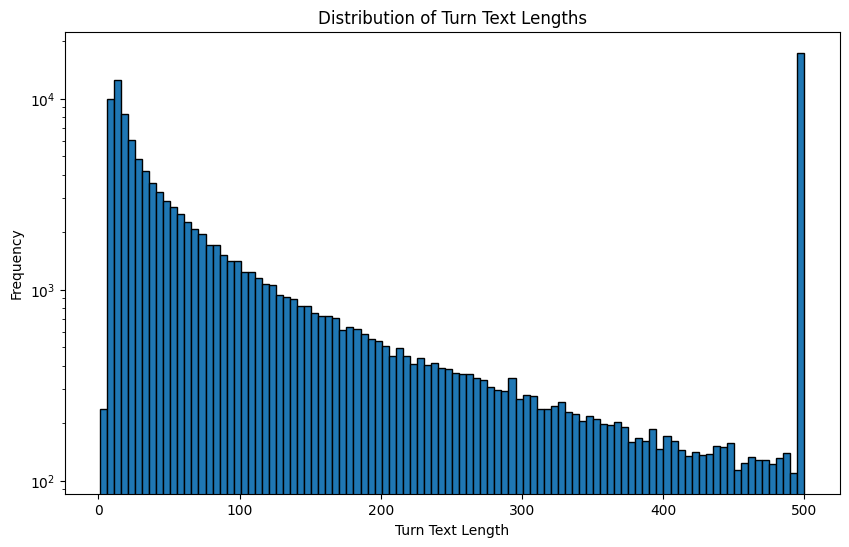

In [16]:
# Plot a histogram of the turn text lengths
turn_lengths = speaker_df1['filtered_text'].str.len().tolist()
plt.figure(figsize=(10, 6))
plt.hist(turn_lengths, bins=100, edgecolor='black')
plt.xlabel('Turn Text Length')
plt.ylabel('Frequency')
plt.yscale('log')
plt.title('Distribution of Turn Text Lengths')
plt.show()

##### 2.4.5.2 Top 20 of most common length turns

In [17]:
from collections import Counter

length_counts = Counter(turn_lengths)

for length, count in length_counts.most_common(20):
    print(f"Length {length}: {count} turns")

Length 500: 17274 turns
Length 9: 3646 turns
Length 10: 3151 turns
Length 11: 2964 turns
Length 12: 2424 turns
Length 13: 2369 turns
Length 14: 2367 turns
Length 15: 2347 turns
Length 16: 1976 turns
Length 8: 1752 turns
Length 17: 1730 turns
Length 19: 1570 turns
Length 18: 1517 turns
Length 20: 1505 turns
Length 21: 1371 turns
Length 22: 1242 turns
Length 23: 1218 turns
Length 25: 1106 turns
Length 24: 1099 turns
Length 7: 1099 turns


#### 2.4.6 Final Output

In [18]:
for index, row in speaker_df1.iloc[420:425].iterrows():
    print(f"Speaker  : {row['speaker']}")
    print(f"Original : {row['turnText'][:100]}... ({len(row['turnText'])} length)",)
    print(f"Filtered : {row['filtered_text'][:100]}... ({len(row['filtered_text'])} length)",)
    print()

Speaker  : ['SPEAKER_02']
Original : . It's all good. It's all good. All right. We also got a message from our resident general authority... (1069 length)
Filtered : good good right also got message resident general authority shannon grover love much shannon shannon... (500 length)

Speaker  : ['SPEAKER_02']
Original : . It's all good. It's all good. All right. We also got a message from our resident general authority... (1069 length)
Filtered : ats good pastor would hey anything help enough food need go grocery store pick anything like sounds ... (130 length)

Speaker  : ['SPEAKER_02']
Original :  called to talk to us about tithing and why we weren't paying tithing. Of course. I told him I belie... (485 length)
Filtered : called talk us tithing werent paying tithing course told believe lord would rather us provide famili... (273 length)

Speaker  : ['SPEAKER_02']
Original :  awesome. Then at the end, it says, "He went on to say that maybe we could put some of our expenses ... (1353 le

### 2.5 Episode-Level Preprocessing

#### 2.5.1 Select Relevant Columns
We extract a subset of columns from the original `episodeLevelData` DataFrame, focusing on those that provide contextual and categorical information about each episode.

| Column                           | Description                                                   |
| :------------------------------- | :------------------------------------------------------------ |
| **epTitle**, **epDescription**   | Episode title and description                                 |
| **mp3url**                       | Unique episode identifier (used to link with speaker turns)   |
| **podTitle**, **podDescription** | Podcast-level metadata for context and categorization         |
| **explicit**                     | Flag indicating whether the episode contains explicit content |
| **category1–category10**         | Topical categories associated with the episode                |



In [19]:
episode_df1 = episode_df[[
    'epTitle', 'mp3url', 'podTitle', 'explicit',
    'category1', 'category2', 'category3', 'category4', 'category5',
    'category6', 'category7', 'category8', 'category9', 'category10'
]].copy()

episode_df1[:20]


,epTitle,mp3url,podTitle,explicit,category1,category2,category3,category4,category5,category6,category7,category8,category9,category10
0,Best of SingOut SpeakOut No.3,https://www.buzzsprout.com/783020/4252475-best...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,None,None
1,It's All Gone,https://www.buzzsprout.com/783020/4165286-it-s...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,None,None
2,Today Is Yesterday,https://www.buzzsprout.com/783020/3983942-toda...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,None,None
3,Saturn Return,https://www.buzzsprout.com/783020/3892169-satu...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,None,None
4,Quarterlife Crisis,https://www.buzzsprout.com/783020/3791501-quar...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,None,None
5,BE: Episode 38 - Why Black Educators Feel Emot...,https://mcdn.podbean.com/mf/web/as0pgw/Why_Bla...,Brazen Education,0,education,self improvement,how to,None,None,None,None,None,None,None
6,BE: Episode 37 - The Benefits of Homeschooling...,https://mcdn.podbean.com/mf/web/0zwxdc/The_Ben...,Brazen Education,0,education,self improvement,how to,None,None,None,None,None,None,None
7,Episode 33 'California’s Higher Education Lan...,http://dts.podtrac.com/redirect.mp3/feeds.soun...,California Community Colleges Podcast,0,education,None,None,None,None,None,None,None,None,None
8,2.20: The NHL Will Continue Until Morale Improves,https://chrt.fm/track/D4A77F/traffic.megaphone...,Puck Bunnies,1,sports,hockey,None,None,None,None,None,None,None,None
9,What causes anxiety?,https://mcdn.podbean.com/mf/web/1o71dp/What_ca...,Anxiety 2 Confidence podcast,0,health,fitness,mental,education,self improvement,None,None,None,None,None


In [20]:
# How many unique episodes?
unique_episodes_count = len(episode_df1['mp3url'].unique())
print(f"Number of unique episodes: {unique_episodes_count}")


# How many different categories in total?
category_columns = [f'category{i}' for i in range(1, 9)]
all_categories = episode_df1[category_columns].values.flatten()
unique_categories = pd.Series(all_categories).dropna().unique()
total_unique_categories = len(unique_categories)
print(f"\nTotal number of unique categories: {total_unique_categories}")


Number of unique episodes: 10000

Total number of unique categories: 99


#### 2.5.2 Handle Missing and Sparse Fields

We first check for missing values in key columns.

Given the dataset’s large size, a small number of missing entries can be safely dropped without compromising representativeness

In [21]:
print("\nMissing values in episode_df1:")
print(episode_df1[['epTitle', 'mp3url', 'podTitle', 'category1']].isnull().sum())

category_columns = [f'category{i}' for i in range(1, 11)]
unique_episodes_count = len(episode_df1['mp3url'].unique())

print("\nNumber of episodes with each category:")
for col in category_columns:
    count = episode_df1[col].notnull().sum()
    print(f"{col}: {count}/{unique_episodes_count}")



Missing values in episode_df1:
epTitle      0
mp3url       0
podTitle     7
category1    9
dtype: int64

Number of episodes with each category:
category1: 9991/10000
category2: 8082/10000
category3: 4257/10000
category4: 2055/10000
category5: 1152/10000
category6: 565/10000
category7: 273/10000
category8: 13/10000
category9: 0/10000
category10: 0/10000


In [22]:
# What categories are represented and any imbalance?
# We can look at the distribution of the first category as a starting point
print("\nDistribution of Category1:")
print('Number of unique categories: ', len(episode_df1['category1'].value_counts()))
print(episode_df1['category1'].value_counts())

print("\nDistribution of Category2:")
print('Number of unique categories: ', len(episode_df1['category2'].value_counts()))
print(episode_df1['category2'].value_counts())

print("\nDistribution of Category3:")
print('Number of unique categories: ', len(episode_df1['category3'].value_counts()))
print(episode_df1['category3'].value_counts())


Distribution of Category1:
Number of unique categories:  20
category1
religion      1982
business      1153
society       1118
education      977
sports         901
health         779
news           496
comedy         490
arts           411
music          372
tv             364
leisure        338
kids           135
science        131
technology     115
fiction         58
true crime      48
history         42
government      41
games           40
Name: count, dtype: int64

Distribution of Category2:
Number of unique categories:  75
category2
spirituality        1982
culture             1118
fitness              762
self improvement     536
film                 364
                    ... 
technology             2
chemistry              2
crafts                 2
nature                 1
stand-up               1
Name: count, Length: 75, dtype: int64

Distribution of Category3:
Number of unique categories:  74
category3
christianity    1196
personal         266
mental           205
news 

In [23]:
# Check for missing values in key columns
print("\nMissing values in episode_df1:")
print(episode_df1[['epTitle', 'mp3url', 'podTitle', 'category1']].isnull().sum())


Missing values in episode_df1:
epTitle      0
mp3url       0
podTitle     7
category1    9
dtype: int64


Most episodes include only a few categories, with all values in `category9` and `category10` being empty.

We therefore remove these two columns to reduce sparsity and simplify the dataset.

In [24]:
print(f"Shape of episode_df1 before dropping missing values and columns: {episode_df1.shape}")

def drop_missing_values_and_columns_episodelvl(episode_dataframe):
    """
    Drop rows missing key metadata and remove unused category columns.
    """
    # Drop rows missing critical fields
    episode_dataframe1 = episode_dataframe.dropna(subset=['podTitle', 'category1'])

    # Drop category9 and category10 if they exist
    columns_to_drop = ['category9', 'category10']
    existing_columns_to_drop = [c for c in columns_to_drop if c in episode_dataframe1.columns]
    if existing_columns_to_drop:
        episode_dataframe1 = episode_dataframe1.drop(columns=existing_columns_to_drop)
    return episode_dataframe1

# Apply the cleanup
episode_df1 = drop_missing_values_and_columns_episodelvl(episode_df1)

print(f"Shape of episode_df1 after dropping missing values and columns: {episode_df1.shape}")


Shape of episode_df1 before dropping missing values and columns: (10000, 14)
Shape of episode_df1 after dropping missing values and columns: (9984, 12)


### 2.6 Merge TurnText - and Episode-Level Data

At this stage, we combine the cleaned speaker-turn and episode-level data to form a unified dataset at the episode level.

This step allows us to analyze or model episodes holistically — using both metadata and spoken content.

#### 2.6.1 Aggregate Speaker Turns per Episode

We first group all turnText entries by mp3url (the episode identifier) and concatenate them into a single text block for each episode.

In [25]:
# Group speaker turns by episode (mp3url) and concatenate the turnText
episode_text_df = (
    speaker_df1
    .groupby('mp3url')
    .apply(lambda df: [
        {
            "speaker": str(row['speaker']),
            "turnText": str(row['filtered_text']),
            # optional: include timing info if available
            **({"startTime": row['startTime'], "endTime": row['endTime']} 
               if 'startTime' in df.columns and 'endTime' in df.columns else {})
        }
        for _, row in df.iterrows()
    ])
    .reset_index(name='turns_list')
)

episode_text_df[:5]


/var/folders/qv/8ghds0hx12s2tw7v8qcq17580000gn/T/ipykernel_56268/236050573.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: [


,mp3url,turns_list
0,http://downloads.newcastle.edu.au/2nur/audio/f...,"[{'speaker': '['SPEAKER_04']', 'turnText': 'tw..."
1,http://downloads.newcastle.edu.au/2nur/audio/f...,"[{'speaker': '['SPEAKER_01']', 'turnText': 'er..."
2,http://dts.podtrac.com/redirect.mp3/feeds.soun...,"[{'speaker': '['SPEAKER_00']', 'turnText': 'hi..."
3,http://dts.podtrac.com/redirect.mp3/feeds.soun...,"[{'speaker': '['SPEAKER_01']', 'turnText': 'he..."
4,http://dts.podtrac.com/redirect.mp3/feeds.soun...,"[{'speaker': '['SPEAKER_03']', 'turnText': 'go..."


#### 2.6.2 Merge Turns with Episode

We then merge the aggregated text with `episode_df1` using `mp3url` as the join key.

In [26]:
# Merge the combined text with episode-level dataframe
episode_df1 = pd.merge(episode_df1, episode_text_df, on='mp3url', how='left')
print(f'Number of episodes before cleanup: {len(episode_df1)}')

# Keep only episodes that actually exist in speaker_df1
valid_urls = set(speaker_df1['mp3url'])
episode_df1 = episode_df1[episode_df1['mp3url'].isin(valid_urls)].reset_index(drop=True)
print(f'Number of episodes after cleanup: {len(episode_df1)}')

episode_df1[:5]

Number of episodes before cleanup: 9984
Number of episodes after cleanup: 907


,epTitle,mp3url,podTitle,explicit,category1,category2,category3,category4,category5,category6,category7,category8,turns_list
0,Best of SingOut SpeakOut No.3,https://www.buzzsprout.com/783020/4252475-best...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,"[{'speaker': '['SPEAKER_00']', 'turnText': 'im..."
1,Today Is Yesterday,https://www.buzzsprout.com/783020/3983942-toda...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,"[{'speaker': '['SPEAKER_05']', 'turnText': 'im..."
2,Saturn Return,https://www.buzzsprout.com/783020/3892169-satu...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,"[{'speaker': '['SPEAKER_03']', 'turnText': 'im..."
3,Quarterlife Crisis,https://www.buzzsprout.com/783020/3791501-quar...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,"[{'speaker': '['SPEAKER_00']', 'turnText': 'im..."
4,Episode 33 'California’s Higher Education Lan...,http://dts.podtrac.com/redirect.mp3/feeds.soun...,California Community Colleges Podcast,0,education,None,None,None,None,None,None,None,"[{'speaker': '['SPEAKER_00']', 'turnText': 'hi..."


This results in one row per episode, containing:

* metadata (e.g., title, categories),
* and the entire spoken transcript as turns_list.

##### 2.6.2.1 Distribution of Turns per Episode
This histogram shows the distribution of the number of speaker turns within each podcast episode. This helps us understand the typical conversational structure and density of the episodes in the dataset.

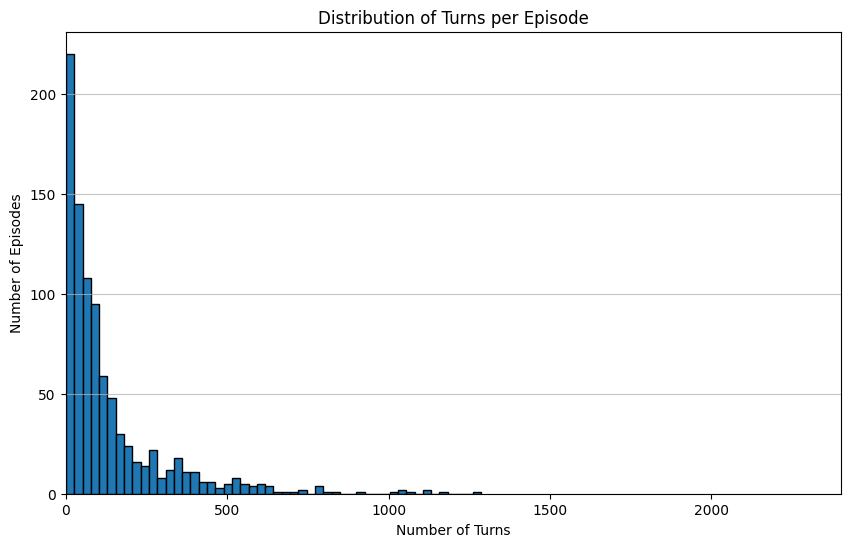

In [27]:
# Calculate the number of turns per episode
turns_per_episode_counts = episode_df1['turns_list'].apply(len).tolist()

# Plot a histogram of the number of turns per episode
plt.figure(figsize=(10, 6))
plt.hist(turns_per_episode_counts, bins=50, edgecolor='black')
plt.title('Distribution of Turns per Episode')
plt.xlabel('Number of Turns')
plt.ylabel('Number of Episodes')
plt.xlim(0, 2400)
plt.grid(axis='y', alpha=0.75)
plt.show()

In [28]:
# How many turns per episode?
turns_per_episode = episode_df1['turns_list'].apply(len).mean()
print(f"Average turns per episode: {turns_per_episode:.2f}")

# How many speakers per episode?
# The 'speaker' column appears to be lists of speaker labels.
def count_unique_speakers_list(speaker_list):
    # Ensure the input is a list before counting unique speakers
    if isinstance(speaker_list, list):
        return len(set(speaker_list))
    else:
        # Print the problematic entry and its type if it's not a list
        print(f"Unexpected type in speaker column: {speaker_list}, Type: {type(speaker_list)}")
        return 0 # Handle cases where the entry is not a list

speaker_df1['num_speakers'] = speaker_df1['speaker'].apply(count_unique_speakers_list)
speakers_per_episode = speaker_df1.groupby('mp3url')['num_speakers'].max().mean()
print(f"Average speakers per episode: {speakers_per_episode:.2f}")

Average turns per episode: 136.03
Average speakers per episode: 1.90


*Note: The y-axis is logarithmic.*

An interesting observation is that the **vast majority** of `turnText` segments are quite short. This suggests that in episodes featuring multiple speakers, frequent interruptions or rapid exchanges may lead to very brief interactions. This pattern is important to keep in mind when feeding the emotion model, as an abundance of short turns could distort the overall emotion distribution at the episode level.

On the other hand, there are also a number of turns **exceeding 10,000 characters**, which are likely outliers caused by transcription or merging artifacts. These unusually long turns can also bias model performance and will require a separate cleaning or truncation strategy in later preprocessing steps. **(TO DO)**


#### 2.6.3 Add Episode Title to Speaker Level Dataset

We can also add the episode titles to speakerLevel dataset, which will come in handy later.

In [29]:
# Merge speaker_df1 with episode_df1 to get the episode title
speaker_df1 = pd.merge(speaker_df1, episode_df1[['mp3url', 'epTitle']], on='mp3url', how='left')

# Display the first few rows to verify the new column
display(speaker_df1.head())

,speaker,turnText,filtered_text,startTime,endTime,mp3url,inferredSpeakerRole,num_speakers,epTitle
0,[SPEAKER_00],I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro sing speak give philosophies ...,0.00,78.16,https://www.buzzsprout.com/783020/4252475-best...,host,1,Best of SingOut SpeakOut No.3
1,[SPEAKER_00],I'm Simon Shapiro and this is Sing Out Speak ...,ompelled sing speak well everyone crazy busy w...,0.00,78.16,https://www.buzzsprout.com/783020/4252475-best...,host,1,Best of SingOut SpeakOut No.3
2,[SPEAKER_05],I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro sing speak give philosophies ...,0.00,36.99,https://www.buzzsprout.com/783020/3983942-toda...,host,1,Today Is Yesterday
3,[SPEAKER_00],Well hello everyone and welcome,well hello everyone welcome,37.44,42.42,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE,1,Today Is Yesterday
4,[SPEAKER_05],to Sing Out Speak Out episode number 20. I kn...,sing speak episode number 20 know crazy going ...,42.42,162.76,https://www.buzzsprout.com/783020/3983942-toda...,host,1,Today Is Yesterday


#### 2.6.4 Extract and Summarize Categories

Finally, we extract the unique set of categories across all category columns to understand the topical diversity of the dataset.

In [30]:
# Extract all category columns
category_columns = [f'category{i}' for i in range(1, 9)]

# Flatten and get unique non-null category values
all_categories = (
    pd.Series(episode_df1[category_columns].values.flatten())
    .dropna()
    .unique()
    .tolist()
)

print(f"Total number of unique categories found: {len(all_categories)}")
print("All unique categories:", all_categories)


Total number of unique categories found: 70
All unique categories: ['music', 'society', 'culture', 'philosophy', 'education', 'self improvement', 'religion', 'spirituality', 'history', 'health', 'fitness', 'news', 'commentary', 'sports', 'business', 'marketing', 'technology', 'entertainment', 'mental', 'arts', 'food', 'christianity', 'politics', 'science', 'natural', 'tv', 'film', 'personal', 'journals', 'true crime', 'comedy', 'kids', 'family', 'careers', 'entrepreneurship', 'performing', 'earth', 'leisure', 'hobbies', 'reviews', 'relationships', 'social', 'improv', 'how to', 'games', 'fiction', 'medicine', 'interviews', 'investing', 'stand-up', 'government', 'video games', 'books', 'places', 'travel', 'basketball', 'baseball', 'parenting', 'stories', 'documentary', 'design', 'buddhism', 'home', 'garden', 'courses', 'visual', 'drama', 'soccer', 'non-profit', 'management']


##### 2.6.4.1 Distribution of Top 20 Most Frequent Categories (all categories)

Here we present the **top 20 most frequent categories**, aggregated across all category fields (`category1` to `category8`). This overview provides a clear picture of the dataset’s thematic landscape, highlighting the dominant topics and revealing potential areas for more granular or targeted analysis.


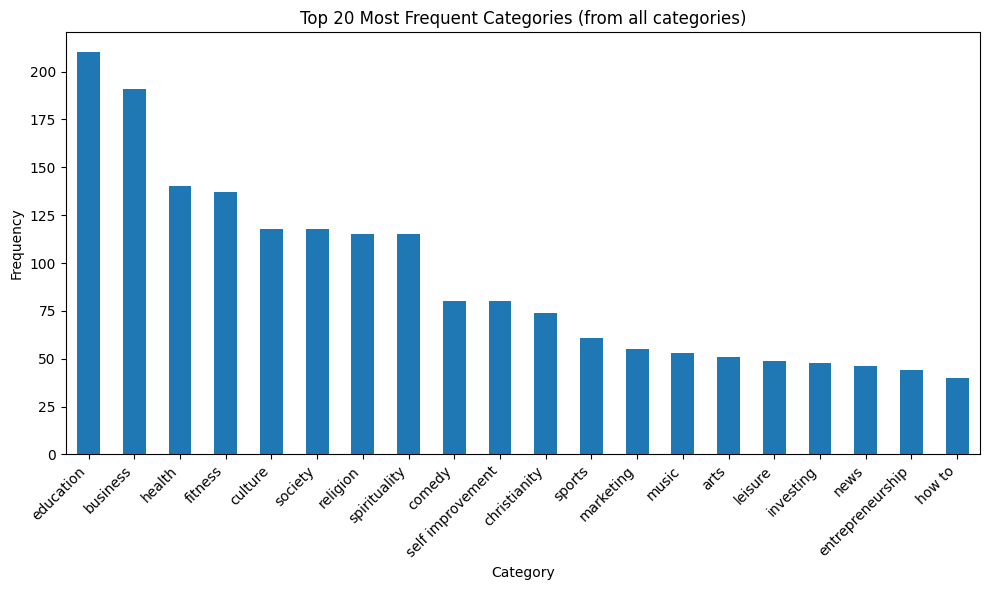

In [31]:
# Combine all category columns into a single Series
all_categories_series = pd.Series(episode_df1[category_columns].values.flatten()).dropna()

# Get the top 20 most frequent categories
top_20_categories = all_categories_series.value_counts().head(20)

# Create a bar chart of the top 20 categories
plt.figure(figsize=(10, 6))
top_20_categories.plot(kind='bar')
plt.title('Top 20 Most Frequent Categories (from all categories)')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 2.6.4.2 Distribution of Top 20 Most Frequent Categories (from category1)

Here we show the **top 20 most frequent categories in `category1`**. This provides insights into the primary genres and main topics covered by the podcasts in the dataset. Analyzing the distribution of the primary category is crucial for understanding the core thematic composition of the data and for informing decisions about episode-level classification tasks.

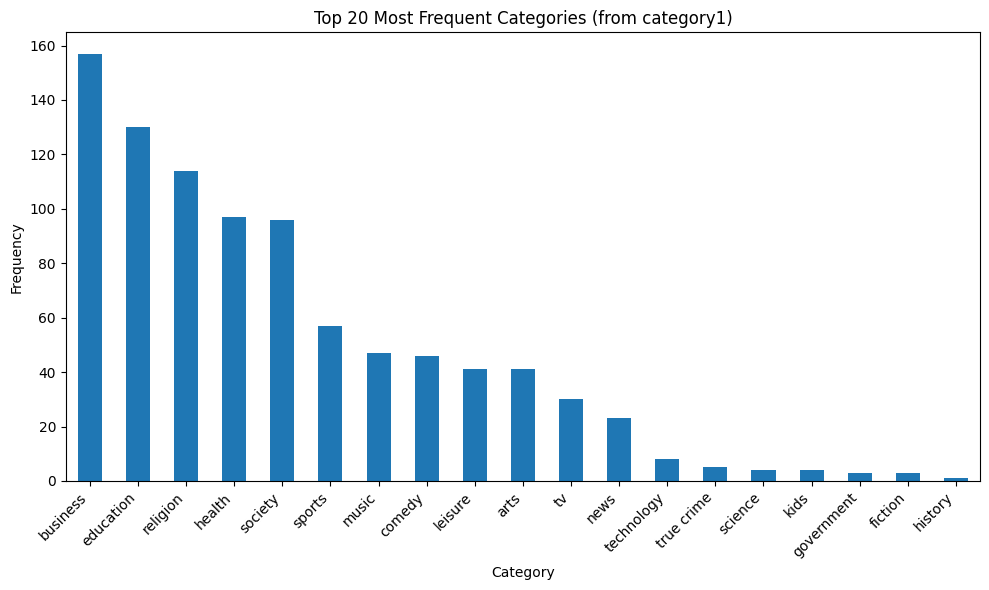

In [32]:
# Combine all category columns into a single Series
all_categories = episode_df1['category1'].values.flatten()
all_categories_series = pd.Series(all_categories).dropna()

# Get the top 20 most frequent categories
top_20_categories = all_categories_series.value_counts().head(20)

# Create a bar chart of the top 20 categories
plt.figure(figsize=(10, 6))
top_20_categories.plot(kind='bar')
plt.title('Top 20 Most Frequent Categories (from category1)')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 2.6.4.3 Distribution of Top 20 Most Frequent Categories (from category2)

And here we show the top 20 most frequent categories in category2. Examining this distribution helps reveal common secondary themes or sub-genres present in the podcast episodes.

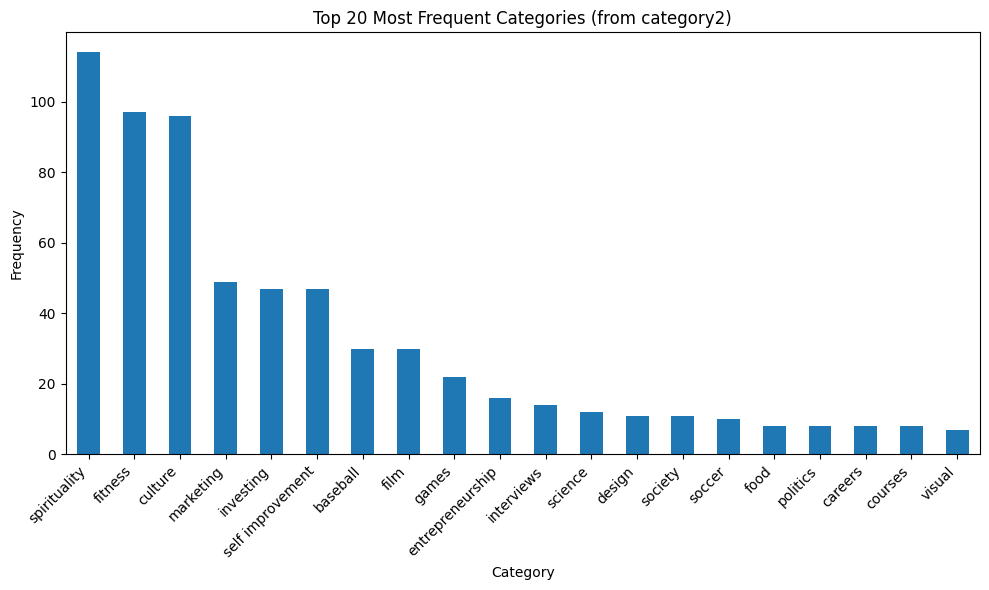

In [33]:
# Combine all category columns into a single Series
all_categories = episode_df1['category2'].values.flatten()
all_categories_series = pd.Series(all_categories).dropna()

# Get the top 20 most frequent categories
top_20_categories = all_categories_series.value_counts().head(20)

# Create a bar chart of the top 20 categories
plt.figure(figsize=(10, 6))
top_20_categories.plot(kind='bar')
plt.title('Top 20 Most Frequent Categories (from category2)')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2.6.5 Final Results 

In [34]:
for i in range(10, 15):
    ep_title = episode_df1.loc[i, 'epTitle']
    mp3_url = episode_df1.loc[i, 'mp3url']
    turns = episode_df1.loc[i, 'turns_list']
    categories = episode_df1.loc[i, category_columns]
    category_list = [cat for cat in categories if cat is not None]


    print(f"\n{'='*60}")
    print(f"Episode {i+1}: {ep_title}")
    print(f"MP3 URL   : {mp3_url}")
    print(f"Categories: {category_list}")
    print(f"Turns     : {len(turns)}")
    print(f"{'-'*60}")

    for t in turns[:8]:  # show first 8 turns
        preview = t['turnText'][:100].replace('\n', ' ') + ('...' if len(t['turnText']) > 100 else '')
        print(f"[{t['speaker']}] {preview}")
    if len(turns) > 8:
        print(f"... ({len(turns) - 8} more turns)")
    print(f"{'='*60}\n")



Episode 11: Why is it so hard to lose weight the 2nd time?
MP3 URL   : https://traffic.megaphone.fm/APO4719798278.mp3
Categories: ['health', 'fitness']
Turns     : 20
------------------------------------------------------------
[['SPEAKER_01']] lets go make excuses im talking im talking lets go youre timing one minute im talking im talking you...
[['SPEAKER_00']] welcome get fit radio host irene cook radio show helps lead healthy lifestyle well point anybody eve...
[['SPEAKER_00']]  theyve kept first try 95 people unsuccessful keeping weight try try lets talk losing weight second ...
[['SPEAKER_00']] cess first time many times people lose weight might lose 5 pounds 6 pounds dont really consider big ...
[['SPEAKER_00']] ealthy fluctuation subsequent amount weight majority goes huge lifestyle change adapt new program ch...
[['SPEAKER_00']] fficult lose weight every time gain back crazy concrete psychological reason case constant cycle yet...
[['SPEAKER_00']] kes feel full increases anot

## 3. Split Datasets

In this section, we split the dataset into **training** and **validation** sets.

In [35]:
from sklearn.model_selection import train_test_split

train, val = train_test_split(episode_df1, test_size=0.2, random_state=42)

print("Split Overview")
print("-" * 40)
print(f"Total episodes     : {len(episode_df1)}")
print(f"Train episodes     : {len(train)}")
print(f"Validation episodes: {len(val)}\n")


Split Overview
----------------------------------------
Total episodes     : 907
Train episodes     : 725
Validation episodes: 182



## 4. Emotional Detector


This section applies automated emotion detection to the podcast dataset to uncover the emotional landscape of conversations. Using a pre-trained transformer-based emotion classification model (j-hartmann/emotion-english-distilroberta-base) , we analyze the emotional content of individual speaker turns across all episodes. By detecting emotions at the turn level, we can aggregate and visualize emotional patterns at the episode level, revealing how emotions evolve throughout conversations, which emotions dominate different episodes, and how emotional diversity and volatility vary across the podcast corpus. These insights help identify emotionally charged episodes, understand narrative arcs, and explore relationships between emotional content and other podcast characteristics such as category or speaker composition.

### 4.1 Emotional Detector (Small Sample)

Before applying emotion classification to the entire dataset, we demonstrate the emotion detection pipeline on a small sample of 20 random episodes. This proof-of-concept allows us to verify that the emotion classifier works correctly, inspect sample outputs, and understand what the predictions look like in practice. By processing a manageable subset first, we can quickly validate the pipeline, identify any issues with text processing or model behavior, and gain confidence before investing computational resources in analyzing the full ~123,000 turns across all episodes.

In [36]:
import torch

device = 'cpu'
if torch.backends.mps.is_available() : device = 'mps'
if torch.cuda.is_available(): device = 'cuda'

print("Using device: ", device)

Using device:  mps


Note: emotion_score is the confidence score (probability) of the top/dominant emotion prediction for a given turn.

In [37]:
from transformers import pipeline

# Sample a few episodes and flatten their turns
df_sample = episode_df1.dropna(subset=['turns_list']).sample(20, random_state=41) # Sample 20 episodes
turns_df = (
    df_sample
    .explode('turns_list', ignore_index=True)
    .dropna(subset=['turns_list'])
)

# Extract episode title and text
turns_df = pd.DataFrame([
    {'epTitle': row.epTitle, 'turnText': row.turns_list.get('turnText', '').strip()}
    for _, row in turns_df.iterrows() if 'turnText' in row.turns_list
])
turns_df = turns_df[turns_df['turnText'] != '']

# Load emotion detection model
emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None,
    device=device
)

# Run model in batches
batch_size = 8
texts = turns_df['turnText'].tolist()

def batched_emotions(texts, batch_size=8):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        preds = emotion_classifier(batch, truncation=True)
        results.extend(preds)
    return results

batch_results = batched_emotions(texts, batch_size)

# Extract labels and scores
turns_df['emotion'] = [r[0]['label'] if r else None for r in batch_results]
turns_df['emotion_score'] = [r[0]['score'] if r else None for r in batch_results]

turns_df.head(20)


/opt/miniconda3/envs/nlp/lib/python3.12/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/miniconda3/envs/nlp/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/miniconda3/envs/nlp/lib/python3.12/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


,epTitle,turnText,emotion,emotion_score
0,Ep2: Planet Puffin - The Puffins’ Return,podcast supported advertising outside uk mus,neutral,0.823450
1,Ep2: Planet Puffin - The Puffins’ Return,ic hey im ryan reynolds mint mobile like oppos...,surprise,0.476022
2,Ep2: Planet Puffin - The Puffins’ Return,hating thats right cutting price mint unlimite...,anger,0.597853
3,Ep2: Planet Puffin - The Puffins’ Return,bbc sounds radio podcasts see morning light he...,neutral,0.597641
4,Ep2: Planet Puffin - The Puffins’ Return,youll love anothers night eye mint,joy,0.508911
5,Ep2: Planet Puffin - The Puffins’ Return,usic beautiful spring day campions sun time gr...,sadness,0.529731
6,Ep2: Planet Puffin - The Puffins’ Return,usic soon,neutral,0.778194
7,Ep2: Planet Puffin - The Puffins’ Return,step path watch every footstep also develop di...,fear,0.978999
8,Ep2: Planet Puffin - The Puffins’ Return,yeah model walked mark way along cliff path ti...,fear,0.616882
9,Ep2: Planet Puffin - The Puffins’ Return,told us could wanted sure werent going tread p...,neutral,0.672224


### 4.1.3 Emotion Classification for Full Dataset
Now, we apply the pre-trained emotion classification model to all speaker turns in the podcast dataset. The model processes each turn text and assigns emotion labels along with confidence scores for all seven emotions (anger, disgust, fear, joy, neutral, sadness, surprise). This turn-level emotion prediction forms the foundation for all subsequent emotion analyses, enabling us to track emotional shifts within episodes and aggregate emotions at both turn and episode levels. Results are cached to  data/emotion_cache/emotion_predictions.csv to avoid redundant computation across multiple analysis runs.

In [38]:
from scipy.stats import entropy
import os
import time
import numpy as np

# Define paths for caching
cache_dir = "data/emotion_cache"
os.makedirs(cache_dir, exist_ok=True)

predictions_cache = os.path.join(cache_dir, "emotion_predictions.csv")
summaries_cache = os.path.join(cache_dir, "emotion_summaries.csv")

print(f"Cache directory created: {cache_dir}")

Cache directory created: data/emotion_cache


In [39]:
def predict_emotions_full_dataset(episode_df, emotion_classifier, batch_size=8, cache_path=None):
    """
    Predict emotions for all turns in the full dataset.
    
    Args:
        episode_df: DataFrame with 'turns_list' column containing dicts with 'turnText'
        emotion_classifier: Loaded emotion classification pipeline
        batch_size: Number of texts to process at once
        cache_path: Optional path to save predictions (CSV format)
    
    Returns:
        DataFrame with columns: mp3url, epTitle, speaker, turnText, startTime, endTime, 
                               emotion, emotion_score, anger_prob, disgust_prob, fear_prob,
                               joy_prob, neutral_prob, sadness_prob, surprise_prob
    """
    
    # Flatten turns from all episodes into individual rows
    all_turns = []
    
    for _, row in episode_df.iterrows():
        ep_title = row['epTitle']
        mp3_url = row['mp3url']
        turns_list = row['turns_list']
        
        if not isinstance(turns_list, list):
            continue
        
        for turn in turns_list:
            if not isinstance(turn, dict) or 'turnText' not in turn:
                continue
            
            turn_text = turn.get('turnText', '').strip()
            if not turn_text:
                continue
            
            all_turns.append({
                'mp3url': mp3_url,
                'epTitle': ep_title,
                'speaker': turn.get('speaker', 'Unknown'),
                'turnText': turn_text,
                'startTime': turn.get('startTime', None),
                'endTime': turn.get('endTime', None)
            })
    
    turns_df = pd.DataFrame(all_turns)
    print(f"Total turns to process: {len(turns_df)}")
    
    # Predict emotions in batches (with ALL probabilities)
    texts = turns_df['turnText'].tolist()
    emotions = []
    scores = []
    anger_probs = []
    disgust_probs = []
    fear_probs = []
    joy_probs = []
    neutral_probs = []
    sadness_probs = []
    surprise_probs = []
    
    # Load emotion detection model
    emotion_classifier = pipeline(
        "text-classification",
        model="j-hartmann/emotion-english-distilroberta-base",
        top_k=None,
        device=device
    )
    
    print("Predicting emotions (extracting ALL emotion probabilities)...")
    start_time = time.time()
    
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        # Use top_k=None to get ALL emotion probabilities, not just top-1
        predictions = emotion_classifier(batch, truncation=True, top_k=None)
        
        for pred_list in predictions:
            if pred_list:
                # Top prediction for emotion and score
                top_pred = pred_list[0]
                emotions.append(top_pred['label'])
                scores.append(top_pred['score'])
                
                # Extract ALL emotion probabilities
                probs_dict = {pred['label']: pred['score'] for pred in pred_list}
                anger_probs.append(probs_dict.get('anger', 0))
                disgust_probs.append(probs_dict.get('disgust', 0.0))
                fear_probs.append(probs_dict.get('fear', 0.0))
                joy_probs.append(probs_dict.get('joy', 0.0))
                neutral_probs.append(probs_dict.get('neutral', 0.0))
                sadness_probs.append(probs_dict.get('sadness', 0.0))
                surprise_probs.append(probs_dict.get('surprise', 0.0))
            else:
                emotions.append('neutral')
                scores.append(0.0)
                anger_probs.append(0.0)
                disgust_probs.append(0.0)
                fear_probs.append(0.0)
                joy_probs.append(0.0)
                neutral_probs.append(1.0)
                sadness_probs.append(0.0)
                surprise_probs.append(0.0)
        
        if (i // batch_size + 1) % 10 == 0:
            elapsed = time.time() - start_time
            print(f"Processed {min(i+batch_size, len(texts))}/{len(texts)} turns in {elapsed:.1f}s")
    
    # Add all columns to dataframe
    turns_df['emotion'] = emotions
    turns_df['emotion_score'] = scores
    turns_df['anger_prob'] = anger_probs
    turns_df['disgust_prob'] = disgust_probs
    turns_df['fear_prob'] = fear_probs
    turns_df['joy_prob'] = joy_probs
    turns_df['neutral_prob'] = neutral_probs
    turns_df['sadness_prob'] = sadness_probs
    turns_df['surprise_prob'] = surprise_probs
    
    elapsed = time.time() - start_time
    print(f"Emotion prediction complete in {elapsed:.1f}s")
    
    # Cache results if path provided
    if cache_path:
        turns_df.to_csv(cache_path, index=False)
        print(f"Predictions cached to {cache_path}")
        print(f"Included emotion probability columns: anger_prob, disgust_prob, fear_prob, joy_prob, neutral_prob, sadness_prob, surprise_prob")
    
    return turns_df

# Check if cached predictions exist; if not, run prediction
if os.path.exists(predictions_cache):
    print(f"Loading cached predictions from {predictions_cache}...")
    turns_df_full = pd.read_csv(predictions_cache)
    print(f"Loaded {len(turns_df_full)} turns from cache")
else:
    print("No cache found. Running full-dataset emotion prediction...")
    turns_df_full = predict_emotions_full_dataset(
        episode_df1, emotion_classifier, batch_size=8, cache_path=predictions_cache
    )


Loading cached predictions from data/emotion_cache/emotion_predictions.csv...
Loaded 123379 turns from cache


### 4.1.4 Episode-Level Emotion Aggregation 

For each episode, we aggregate emotions from all turns while preserving chronological order via `startTime`. This enables us to:
- Compute emotion distribution ratios for the episode
- Calculate summary statistics: dominant emotion, diversity (entropy), volatility (emotion switches)
- Visualize emotional evolution over time within each episode


In [40]:
def aggregate_emotions_by_episode(turns_df, cache_path=None):
    """
    Aggregate turn-level emotions to episode level with time-aware ordering.
    
    Args:
        turns_df: DataFrame with emotion predictions per turn
        cache_path: Optional path to save episode summaries
    
    Returns:
        DataFrame with one row per episode containing:
        - emotion_counts: count of each emotion in the episode
        - emotion_ratios: proportion of each emotion
        - dominant_emotion: most frequent emotion
        - diversity: entropy of emotion distribution (higher = more varied)
        - volatility: number of emotion transitions / total turns
        - emotion_sequence: chronological list of emotions
    """
    
    summaries = []
    
    for mp3_url in turns_df['mp3url'].unique():
        episode_turns = turns_df[turns_df['mp3url'] == mp3_url].copy()
        
        # Sort by startTime to get chronological order
        # Handle missing startTime gracefully
        if 'startTime' in episode_turns.columns:
            episode_turns = episode_turns.sort_values('startTime', na_position='last')
        
        # Get episode metadata
        ep_title = episode_turns['epTitle'].iloc[0]
        
        # Count emotions
        emotion_counts = episode_turns['emotion'].value_counts().to_dict()
        total_turns = len(episode_turns)
        emotion_ratios = {k: v/total_turns for k, v in emotion_counts.items()}
        
        # Dominant emotion (most frequent)
        dominant_emotion = max(emotion_counts, key=emotion_counts.get)
        
        # Diversity: entropy of emotion distribution
        emotion_probs = np.array(list(emotion_ratios.values()))
        diversity = entropy(emotion_probs)
        
        # Volatility: number of emotion transitions
        emotion_sequence = episode_turns['emotion'].tolist()
        transitions = sum(1 for i in range(len(emotion_sequence)-1) if emotion_sequence[i] != emotion_sequence[i+1])
        volatility = transitions / max(1, total_turns - 1)  # Avoid division by zero
        
        summaries.append({
            'mp3url': mp3_url,
            'epTitle': ep_title,
            'total_turns': total_turns,
            'dominant_emotion': dominant_emotion,
            'diversity': diversity,
            'volatility': volatility,
            'emotion_sequence': emotion_sequence,
            'emotion_counts': emotion_counts,
            'emotion_ratios': emotion_ratios
        })
    
    summaries_df = pd.DataFrame(summaries)
    
    print(f"Aggregated {len(summaries_df)} episodes")
    print(f"Average emotion diversity: {summaries_df['diversity'].mean():.3f}")
    print(f"Average volatility: {summaries_df['volatility'].mean():.3f}")
    
    # Cache results if path provided
    if cache_path:
        # Create cacheable version (emotion_sequence as JSON string)
        cache_df = summaries_df.copy()
        cache_df['emotion_sequence'] = cache_df['emotion_sequence'].apply(lambda x: str(x))
        cache_df['emotion_counts'] = cache_df['emotion_counts'].apply(lambda x: str(x))
        cache_df['emotion_ratios'] = cache_df['emotion_ratios'].apply(lambda x: str(x))
        cache_df.to_csv(cache_path, index=False)
        print(f"Episode summaries cached to {cache_path}")
    
    return summaries_df

# Aggregate by episode
episode_summaries = aggregate_emotions_by_episode(turns_df_full, cache_path=summaries_cache)
episode_summaries.head()


Aggregated 907 episodes
Average emotion diversity: 1.362
Average volatility: 0.653
Episode summaries cached to data/emotion_cache/emotion_summaries.csv


,mp3url,epTitle,total_turns,dominant_emotion,diversity,volatility,emotion_sequence,emotion_counts,emotion_ratios
0,https://www.buzzsprout.com/783020/4252475-best...,Best of SingOut SpeakOut No.3,2,fear,0.693147,1.000000,"[fear, joy]","{'fear': 1, 'joy': 1}","{'fear': 0.5, 'joy': 0.5}"
1,https://www.buzzsprout.com/783020/3983942-toda...,Today Is Yesterday,9,joy,1.427061,0.875000,"[fear, joy, sadness, joy, joy, neutral, sadnes...","{'joy': 4, 'sadness': 2, 'fear': 1, 'neutral':...","{'joy': 0.4444444444444444, 'sadness': 0.22222..."
2,https://www.buzzsprout.com/783020/3892169-satu...,Saturn Return,6,joy,1.242453,0.800000,"[fear, neutral, joy, sadness, joy, joy]","{'joy': 3, 'fear': 1, 'neutral': 1, 'sadness': 1}","{'joy': 0.5, 'fear': 0.16666666666666666, 'neu..."
3,https://www.buzzsprout.com/783020/3791501-quar...,Quarterlife Crisis,6,joy,1.011404,0.600000,"[fear, joy, joy, surprise, surprise, joy]","{'joy': 3, 'surprise': 2, 'fear': 1}","{'joy': 0.5, 'surprise': 0.3333333333333333, '..."
4,http://dts.podtrac.com/redirect.mp3/feeds.soun...,Episode 33 'California’s Higher Education Lan...,60,neutral,1.390782,0.694915,"[surprise, neutral, fear, joy, neutral, neutra...","{'neutral': 26, 'joy': 18, 'fear': 8, 'sadness...","{'neutral': 0.43333333333333335, 'joy': 0.3, '..."


### 4.1.5 Summary Statistics Across Episodes

In [41]:
# Display summary statistics
print("\n=== Summary Statistics ===")
print(f"Total episodes analyzed: {len(episode_summaries)}")
print(f"\nDominant Emotions (distribution across all episodes):")
print(episode_summaries['dominant_emotion'].value_counts())

print(f"\nDiversity (emotion variation per episode):")
print(f"  Mean: {episode_summaries['diversity'].mean():.3f}")
print(f"  Median: {episode_summaries['diversity'].median():.3f}")
print(f"  Std: {episode_summaries['diversity'].std():.3f}")

print(f"\nVolatility (emotion transitions per episode):")
print(f"  Mean: {episode_summaries['volatility'].mean():.3f}")
print(f"  Median: {episode_summaries['volatility'].median():.3f}")
print(f"  Std: {episode_summaries['volatility'].std():.3f}")

print(f"\nTurns per episode:")
print(f"  Mean: {episode_summaries['total_turns'].mean():.1f}")
print(f"  Median: {episode_summaries['total_turns'].median():.1f}")
print(f"  Min: {episode_summaries['total_turns'].min()}")
print(f"  Max: {episode_summaries['total_turns'].max()}")



=== Summary Statistics ===
Total episodes analyzed: 907

Dominant Emotions (distribution across all episodes):
dominant_emotion
neutral     487
joy         289
surprise     52
anger        30
fear         29
sadness      20
Name: count, dtype: int64

Diversity (emotion variation per episode):
  Mean: 1.362
  Median: 1.428
  Std: 0.307

Volatility (emotion transitions per episode):
  Mean: 0.653
  Median: 0.673
  Std: 0.147

Turns per episode:
  Mean: 136.0
  Median: 74.0
  Min: 1
  Max: 1286


### 4.1.6 Overall Emotion Distribution

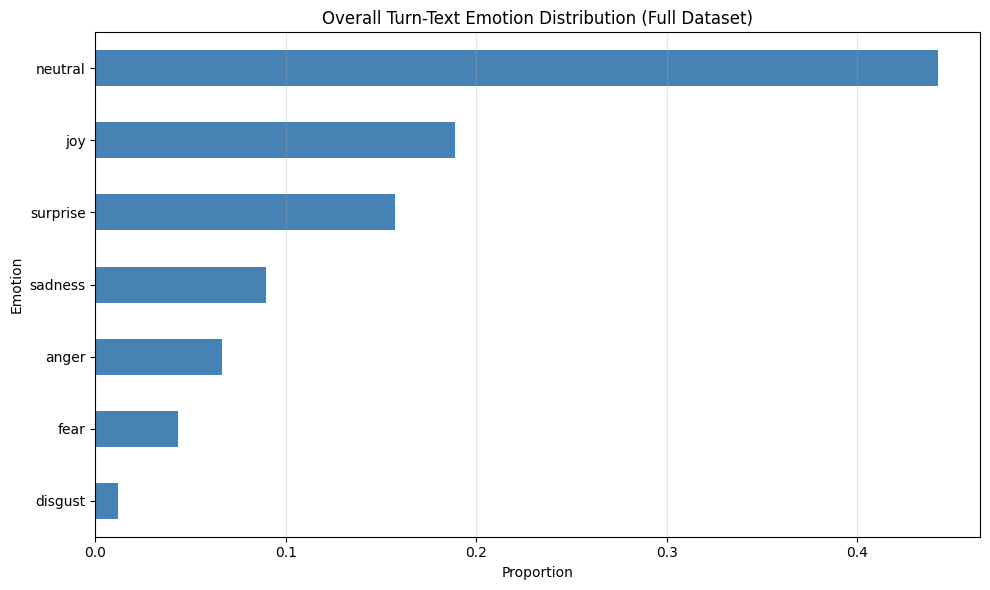


Overall Emotion Distribution:
emotion
neutral     0.442401
joy         0.188679
surprise    0.157531
sadness     0.089634
anger       0.066438
fear        0.043573
disgust     0.011744
Name: count, dtype: float64


In [42]:
# Compute overall emotion distribution across all turns
overall_emotion_dist = turns_df_full['emotion'].value_counts()
overall_emotion_dist_pct = overall_emotion_dist / overall_emotion_dist.sum()

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
overall_emotion_dist_pct.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Proportion')
ax.set_ylabel('Emotion')
ax.set_title('Overall Turn-Text Emotion Distribution (Full Dataset)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nOverall Emotion Distribution:")
print(overall_emotion_dist_pct.sort_values(ascending=False))


### 4.1.7 Emotion Evolution Graphs (All Emotion Probabilites per  Turn)
Below we visualize the emotional evolution across selected episodes. Each line represents one emotion, showing how frequently it appears as we move through the episode chronologically. This enables us to see emotional arcs—periods of heightened emotion, transitions, and overall narrative tone.


In [43]:
# This visualization shows ALL emotion probability scores for each turn, reading from the cached CSV data.

emotion_colors = {
    'anger': '#d62728',      # red
    'disgust': '#2ca02c',    # green
    'fear': '#ff7f0e',       # orange
    'joy': '#1f77b4',        # blue
    'neutral': '#7f7f7f',    # gray
    'sadness': '#9467bd',    # purple
    'surprise': '#bcbd22'    # yellow
}

def plot_all_emotion_probabilities(mp3_url, episode_title, min_turns=50):
    """
    Plot ALL emotion probabilities for a specific episode using cached probability data.
    
    Args:
        mp3_url: The mp3url identifier for the episode
        episode_title: Title of the episode for the plot
        min_turns: Minimum turns required to plot
    
    Returns:
        matplotlib figure, or None if episode doesn't meet criteria
    """
    
    # Get turns for this episode from the cached data
    episode_turns = turns_df_full[turns_df_full['mp3url'] == mp3_url].copy()
    
    if len(episode_turns) < min_turns:
        return None
    
    # Sort chronologically
    episode_turns = episode_turns.sort_values('startTime', na_position='last')
    
    # Get volatility and diversity from episode_summaries
    ep_summary = episode_summaries[episode_summaries['mp3url'] == mp3_url]
    volatility = ep_summary['volatility'].values[0] if len(ep_summary) > 0 else 0
    diversity = ep_summary['diversity'].values[0] if len(ep_summary) > 0 else 0
    
    # Get ALL emotion probabilities from cached columns
    emotion_prob_cols = ['anger_prob', 'disgust_prob', 'fear_prob', 'joy_prob', 'neutral_prob', 'sadness_prob', 'surprise_prob']
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot each emotion's probability trajectory using cached data
    for col in emotion_prob_cols:
        emotion = col.replace('_prob', '')
        probabilities = episode_turns[col].tolist()
        ax.plot(range(len(probabilities)), probabilities, 
               label=emotion, color=emotion_colors[emotion], linewidth=2.5, alpha=0.8)
    
    ax.set_xlabel('Turn Number (Chronological)', fontsize=12)
    ax.set_ylabel('Emotion Probability', fontsize=12)
    dominant = episode_turns['emotion'].value_counts().idxmax()
    ax.set_title(f'All Emotion Probabilities: {episode_title} ({len(episode_turns)} turns) | Volatility: {volatility:.3f} | Diversity: {diversity:.3f} | Dominant: {dominant}', 
                fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    return fig

#### 4.1.7a Emotion Probabilities (Most Volatile Episodes)

Plotting top 5 most volatile episodes with ALL emotion probabilities
Episode 1: If I’m Honest: Real Life in Psalms // Clothed With Splendor // Chris Dolson | 06.28.2020 (volatility: 0.865, turns: 53)


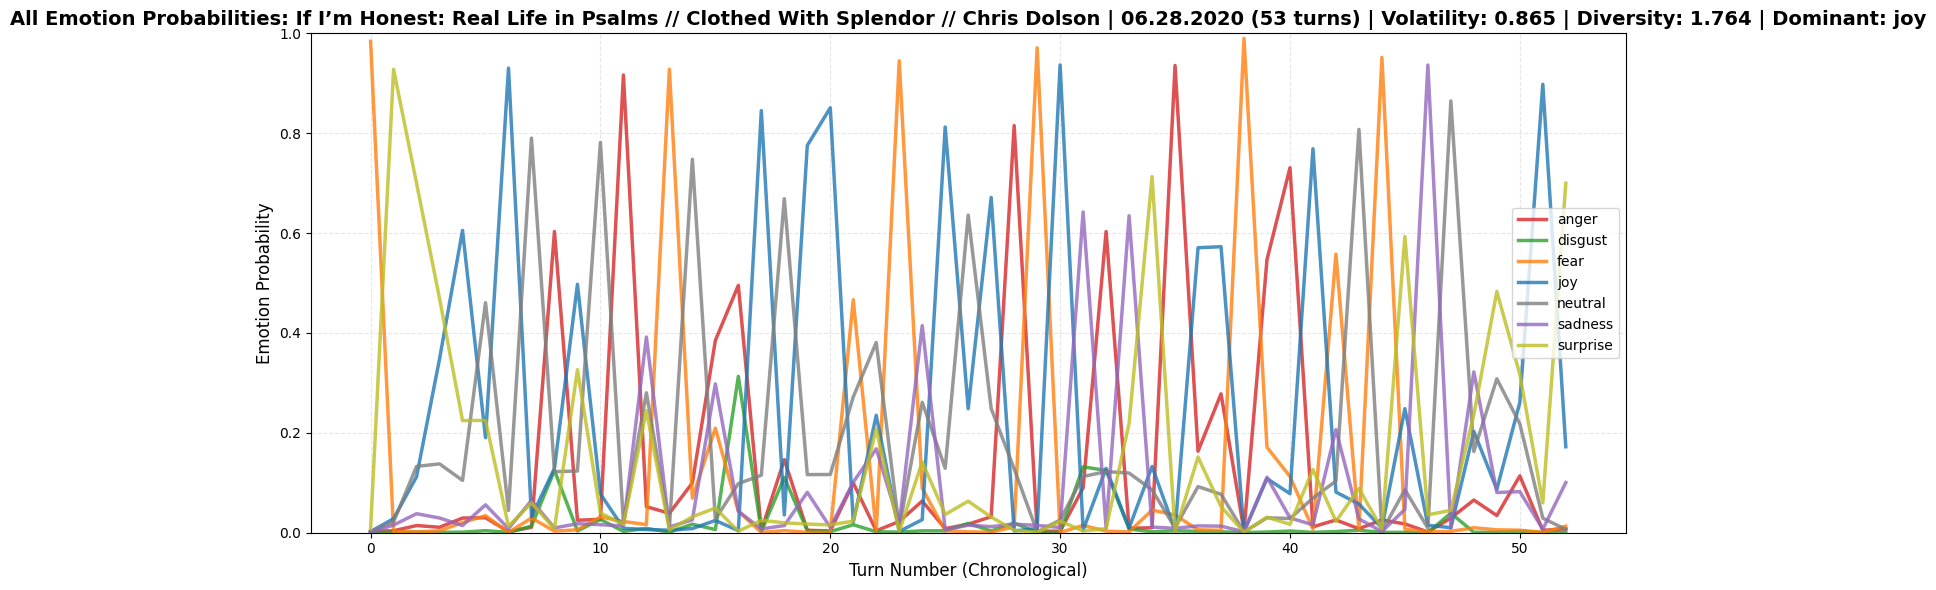

Episode 2: Fireside Chat: The Long Reach of the Great Depression of the 1780s (Dr. Scott C. Miller) (volatility: 0.863, turns: 74)


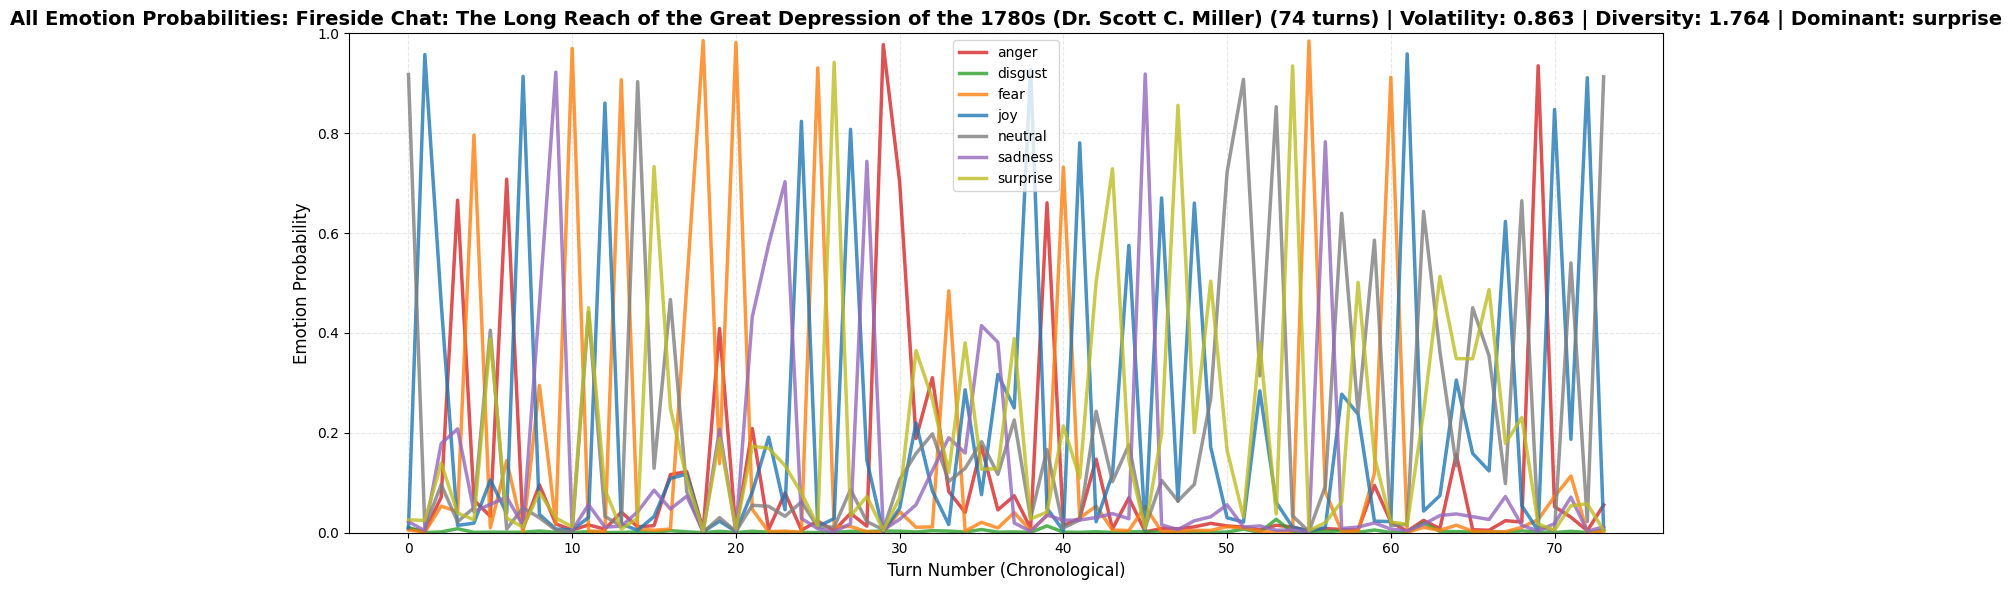

Episode 3: What Did The 5 Fingers Say to the Soul?... WAKE UP!!! (volatility: 0.863, turns: 52)


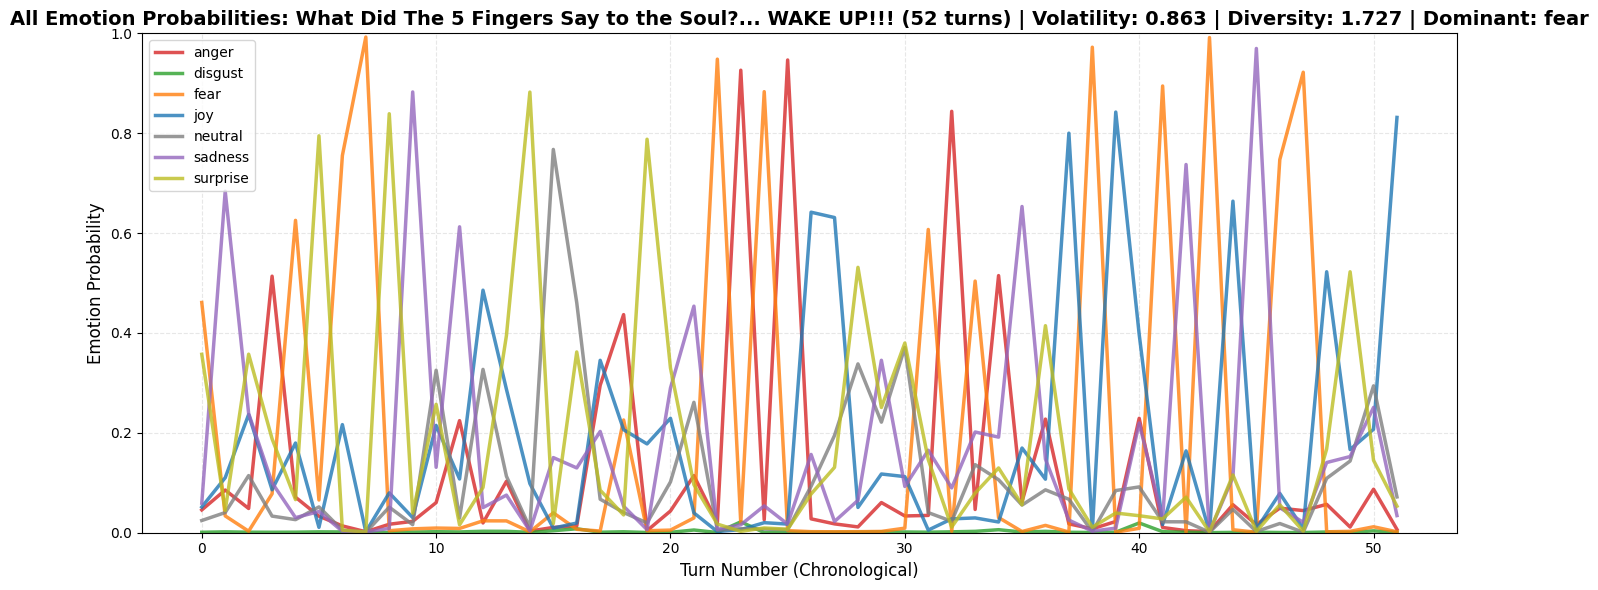

Episode 4: What Are You Made Of with Mike 'C-Roc' Ciorrocco (volatility: 0.855, turns: 84)


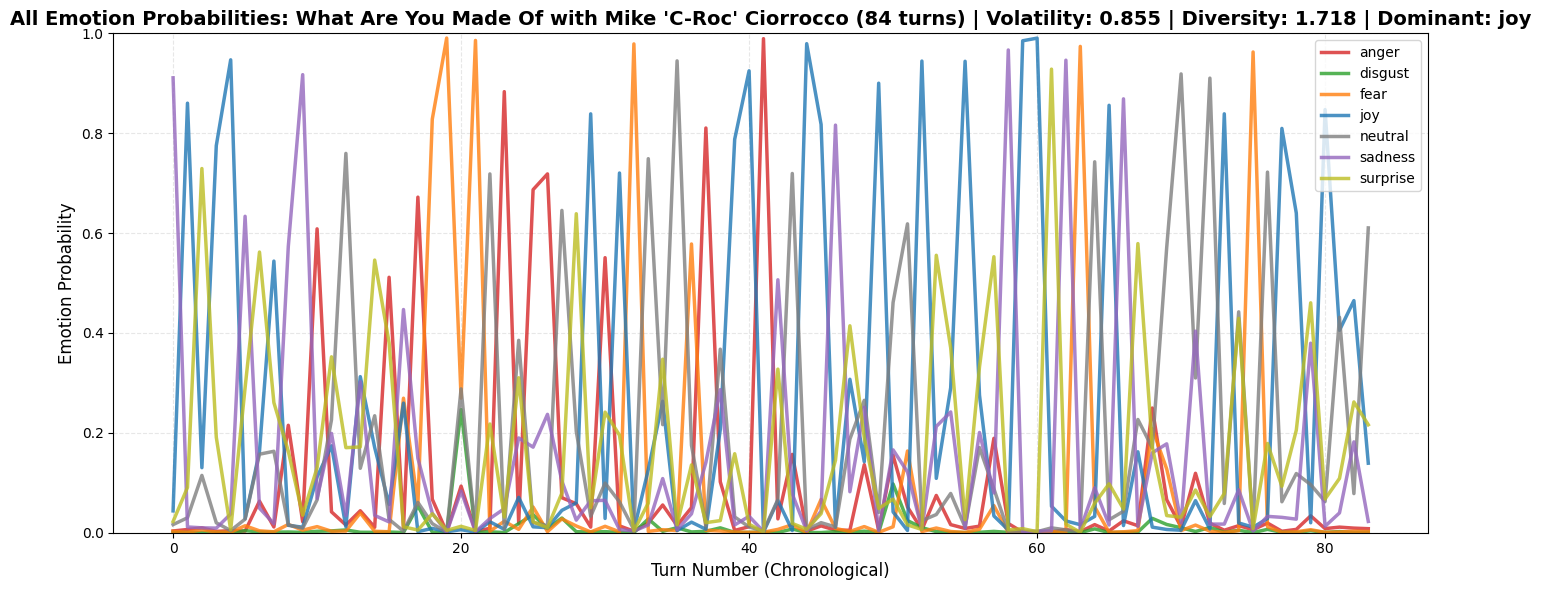

Episode 5: Sheep and Goat Care (volatility: 0.833, turns: 61)


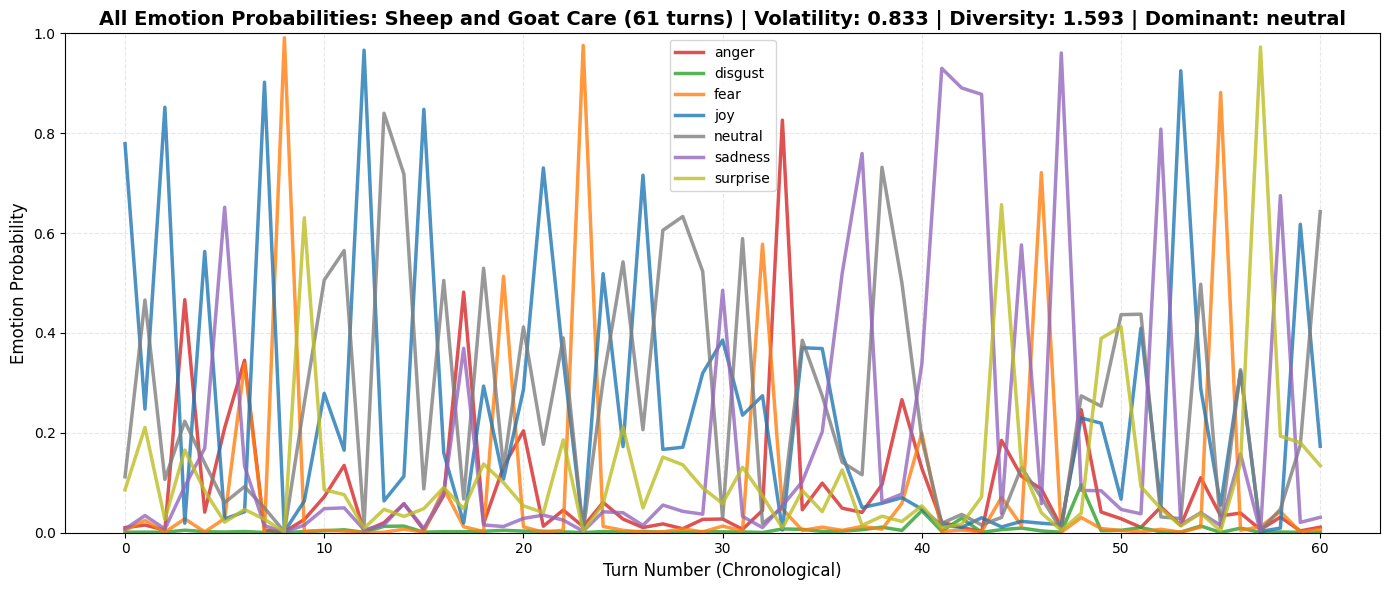

In [44]:
# Get top 5 most volatile episodes (≥50 turns)
filtered_episodes = episode_summaries[episode_summaries['total_turns'] >= 50].copy()
top_volatile = filtered_episodes.nlargest(5, 'volatility')

print("Plotting top 5 most volatile episodes with ALL emotion probabilities")

for idx, (_, row) in enumerate(top_volatile.iterrows(), 1):
    print(f"Episode {idx}: {row['epTitle']} (volatility: {row['volatility']:.3f}, turns: {row['total_turns']})")
    fig = plot_all_emotion_probabilities(row['mp3url'], row['epTitle'])
    if fig:
        plt.show()
        


#### 4.1.7b Emotion Probabilities (Least Volatile Episodes)

Plotting top 5 least volatile episodes with ALL emotion probabilities (from cached CSV)...
Episodes: 334 total turns

Episode 1: Ep6: Planet Puffin - Netting Puffins (volatility: 0.355,  diversity: 0.912,  turns: 63)


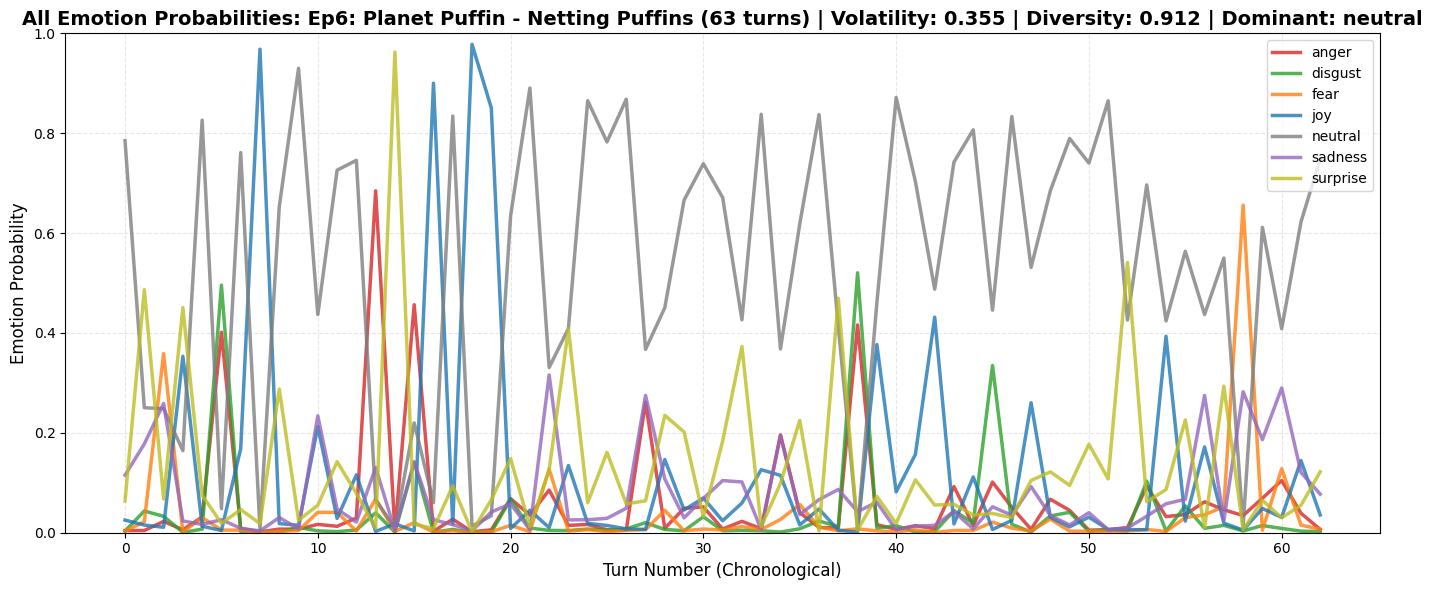

Episode 2: SOPP600: I'm currently learning the Dubois Toccata in G No 3 (volatility: 0.364,  diversity: 0.845,  turns: 56)


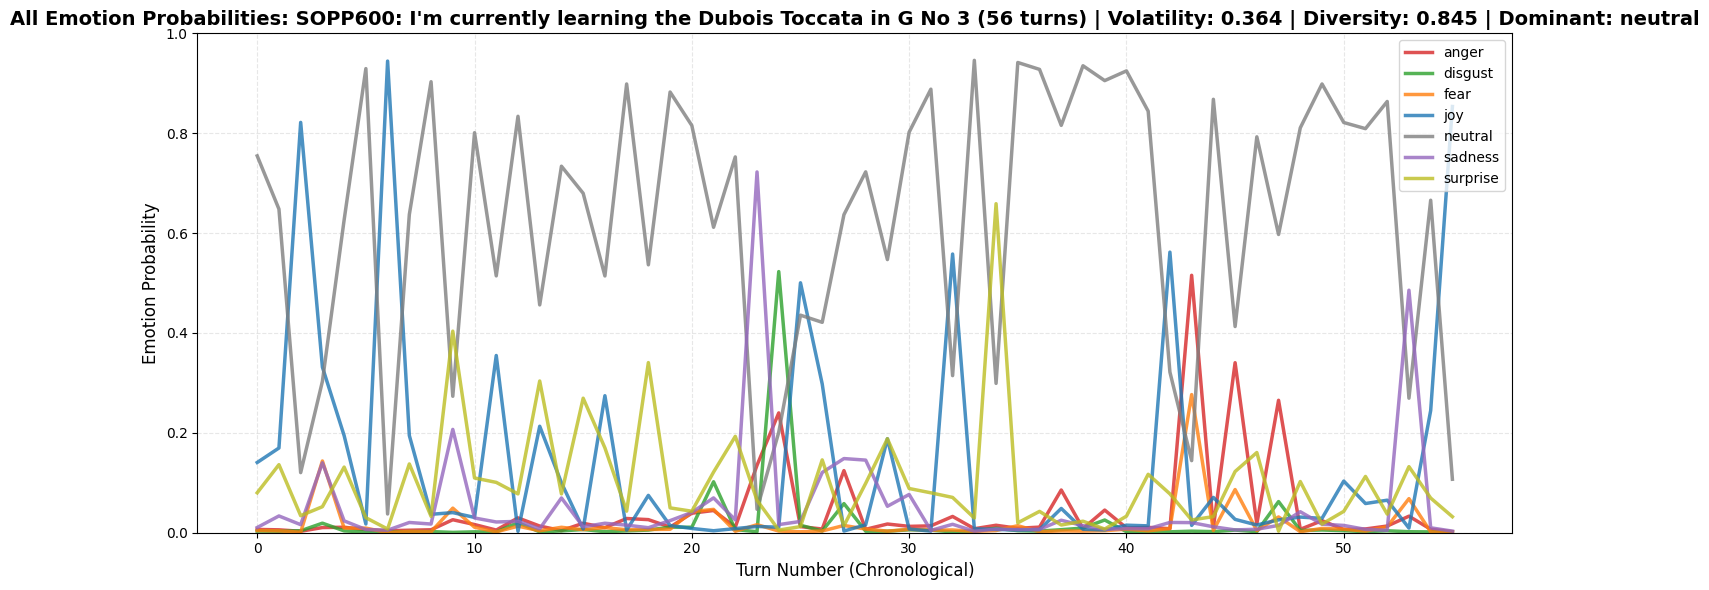

Episode 3: SOPP589: I am in the process of memorizing a piece, based upon what I am learning in this course! (volatility: 0.382,  diversity: 0.925,  turns: 90)


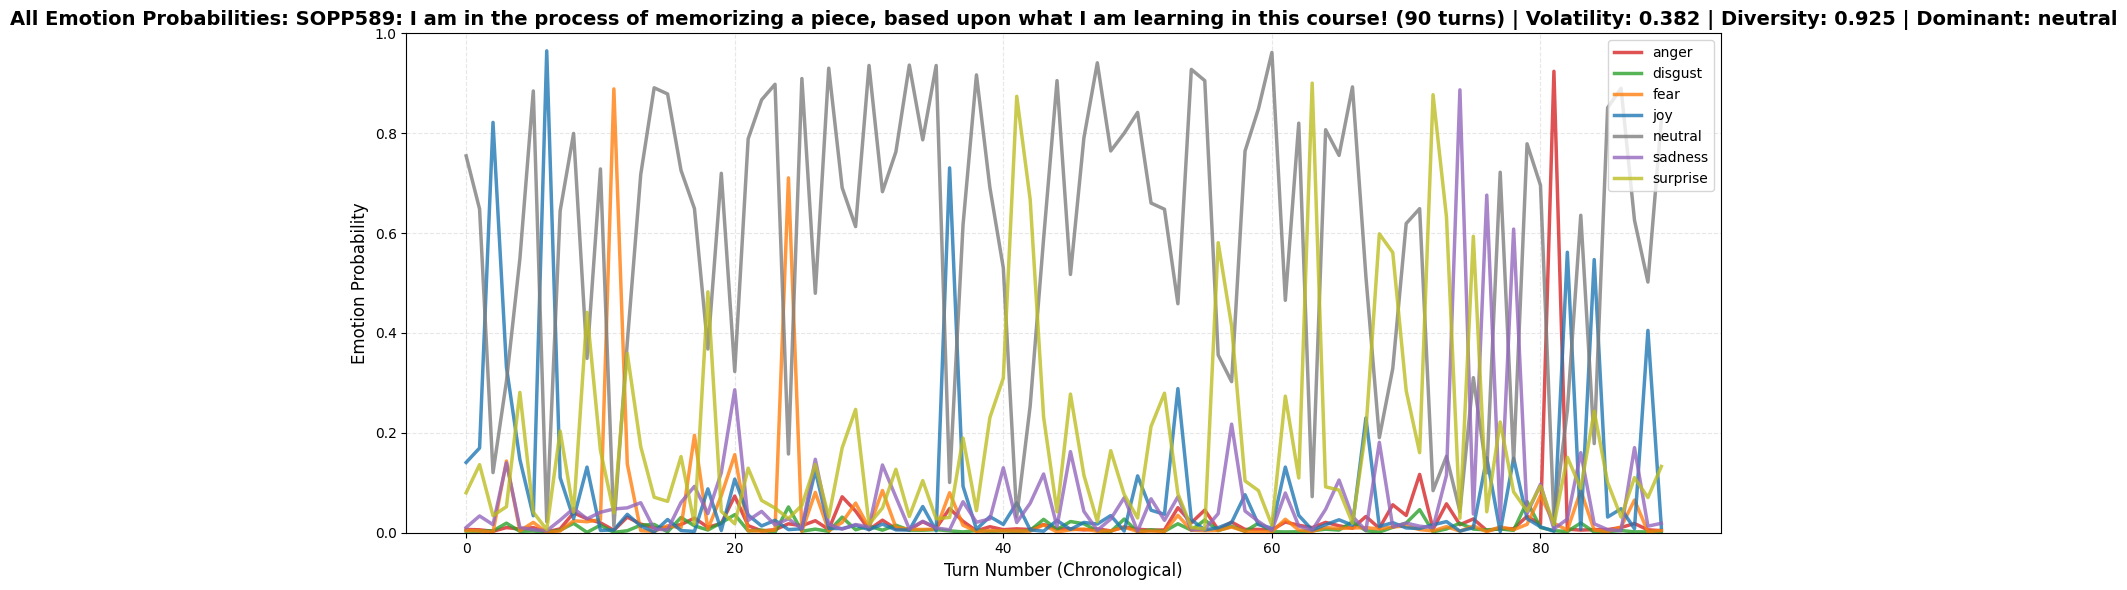

Episode 4: SOPP578: I would like to study the Bach's BWV 532 and 552 (volatility: 0.389,  diversity: 0.902,  turns: 73)


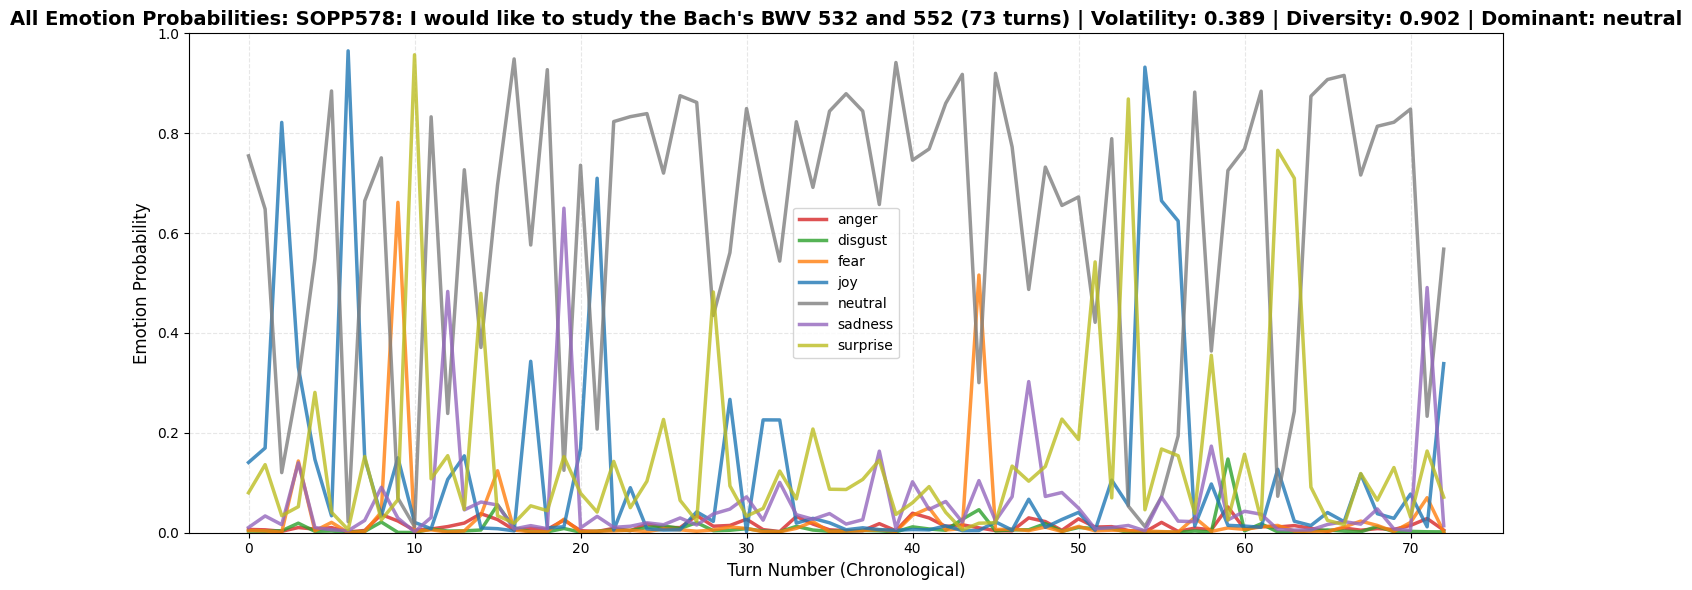

Episode 5: SOPP593: I am actually a jazz guitar player who has long been passionate about Baroque organ music (volatility: 0.392,  diversity: 0.912,  turns: 52)


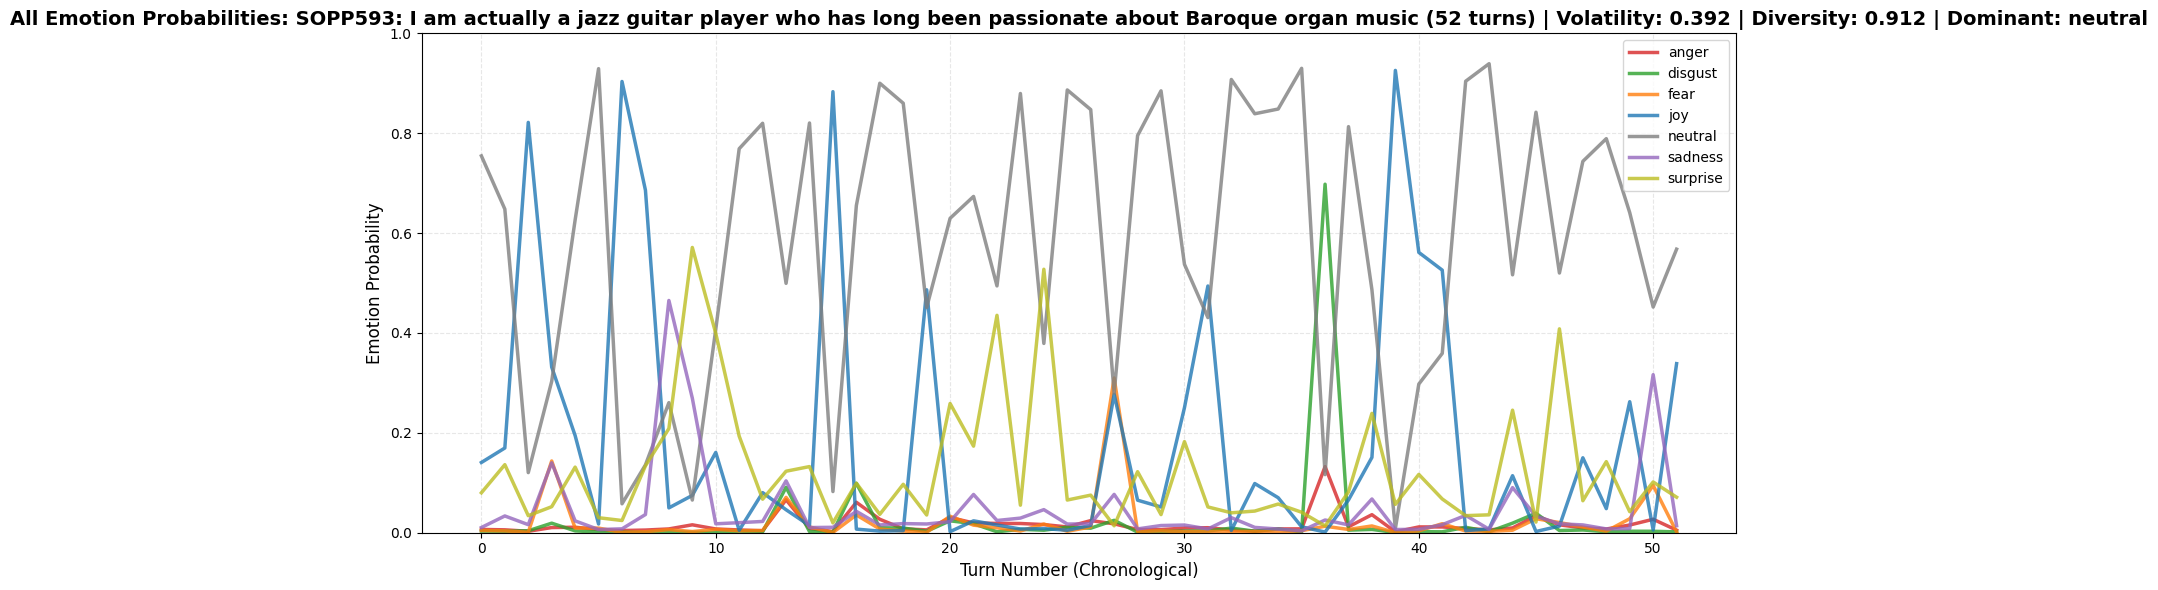

In [45]:
# Get top 5 least volatile episodes (≥50 turns)
filtered_episodes = episode_summaries[episode_summaries['total_turns'] >= 50].copy()
top_least_volatile = filtered_episodes.nsmallest(5, 'volatility')

print("Plotting top 5 least volatile episodes with ALL emotion probabilities (from cached CSV)...")
print(f"Episodes: {top_least_volatile['total_turns'].sum()} total turns\n")

for idx, (_, row) in enumerate(top_least_volatile.iterrows(), 1):
    print(f"Episode {idx}: {row['epTitle']} (volatility: {row['volatility']:.3f},  diversity: {row['diversity']:.3f},  turns: {row['total_turns']})")
    fig = plot_all_emotion_probabilities(row['mp3url'], row['epTitle'])
    if fig:
        plt.show()


### 4.1.8. Emotion Evolution Graphs (Average Dominant Emotion)

Below we visualize the emotional evolution of episodes using moving average smoothing to reveal broader emotional trends. Instead of displaying raw emotion probabilities, this approach computes the proportion of each emotion within a sliding window across the episode chronologically. This smoothed representation highlights the overall emotional arc and dominant patterns, filtering out momentary fluctuations to show sustained emotional shifts and narrative progression.

In [46]:
def plot_emotion_evolution(episode_summary, emotion_colors=None, min_turns=50):
    """
    Plot emotion evolution over time for a single episode.
    
    Args:
        episode_summary: Row from episode_summaries with emotion_sequence
        emotion_colors: Optional dict mapping emotions to colors
        min_turns: Minimum number of turns required to plot (default 50)
    
    Returns:
        matplotlib figure and axes, or None if episode doesn't meet minimum criteria
    """
    
    ep_title = episode_summary['epTitle']
    emotion_sequence = episode_summary['emotion_sequence']
    total_turns = episode_summary['total_turns']
    
    # Skip episodes with too few turns (not enough for meaningful evolution)
    if total_turns < min_turns:
        return None
    
    if not emotion_sequence:
        print(f"No emotion sequence for {ep_title}")
        return None
    
    # Only plot emotions that actually appear in this episode
    emotions_in_episode = sorted(set(emotion_sequence))
    
    if emotion_colors is None:
        import matplotlib.cm as cm
        colors = cm.get_cmap('tab10')
        emotion_colors = {emotion: colors(i % 10) for i, emotion in enumerate(emotions_in_episode)}
    
    # Compute moving average window size
    window_size = max(5, len(emotion_sequence) // 20)  # smooth over ~20 windows
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # For each emotion present in episode, compute moving average proportion
    for emotion in emotions_in_episode:
        emotion_timeline = []
        for i in range(len(emotion_sequence)):
            # Window centered at position i
            start = max(0, i - window_size // 2)
            end = min(len(emotion_sequence), i + window_size // 2 + 1)
            window = emotion_sequence[start:end]
            count = sum(1 for e in window if e == emotion)
            proportion = count / len(window)
            emotion_timeline.append(proportion)
        
        ax.plot(range(len(emotion_timeline)), emotion_timeline, 
               label=emotion, color=emotion_colors[emotion], linewidth=2.5, alpha=0.8)
    

    ax.set_xlabel('Turn Number (Chronological)', fontsize=12)
    ax.set_ylabel('Moving Average Proportion', fontsize=12)
    dominant = episode_summary.get('dominant_emotion', 'Unknown')
    ax.set_title(f'Emotion Evolution: {ep_title} ({total_turns} turns) | Dominant: {dominant}', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    return fig, ax

#### 4.1.8a Average Emotion Probabilities (Most Volatile Episodes)

Plotting emotion evolution for top 5 most volatile episodes (min 50 turns):

1. If I’m Honest: Real Life in Psalms // Clothed With Splendor // Chris Dolson | 06.28.2020 (volatility: 0.865, diversity: 1.764)


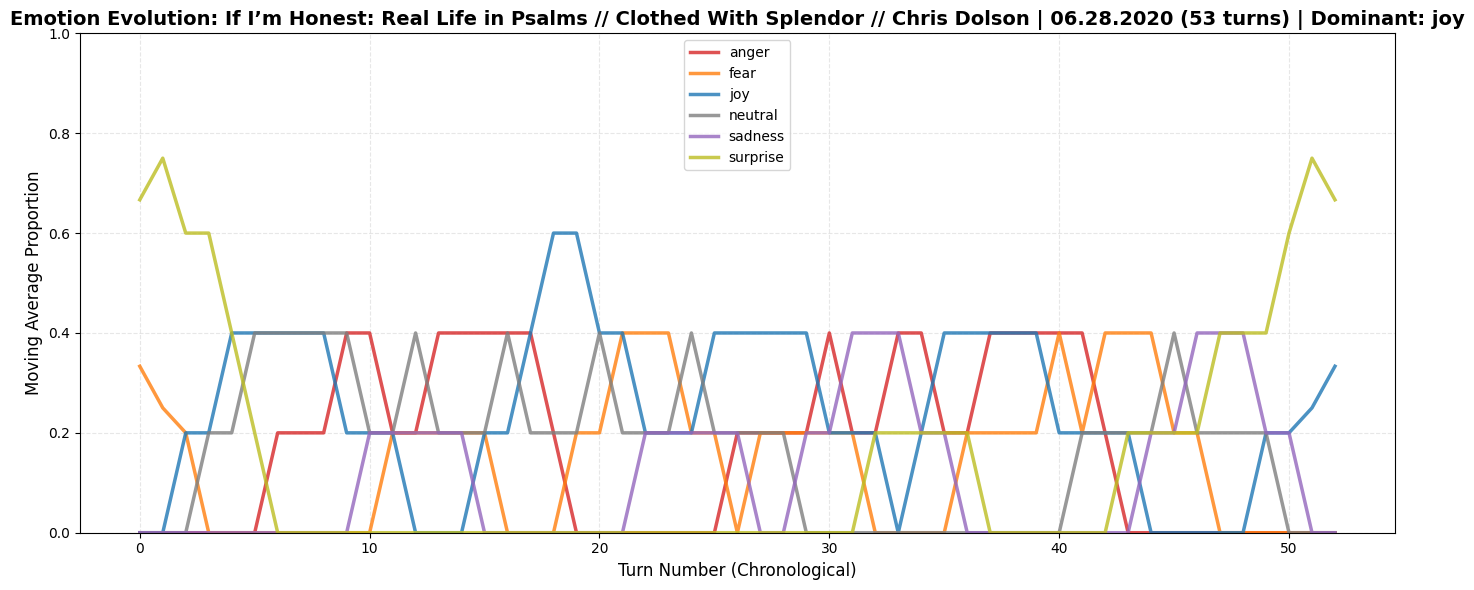

2. Fireside Chat: The Long Reach of the Great Depression of the 1780s (Dr. Scott C. Miller) (volatility: 0.863, diversity: 1.764)


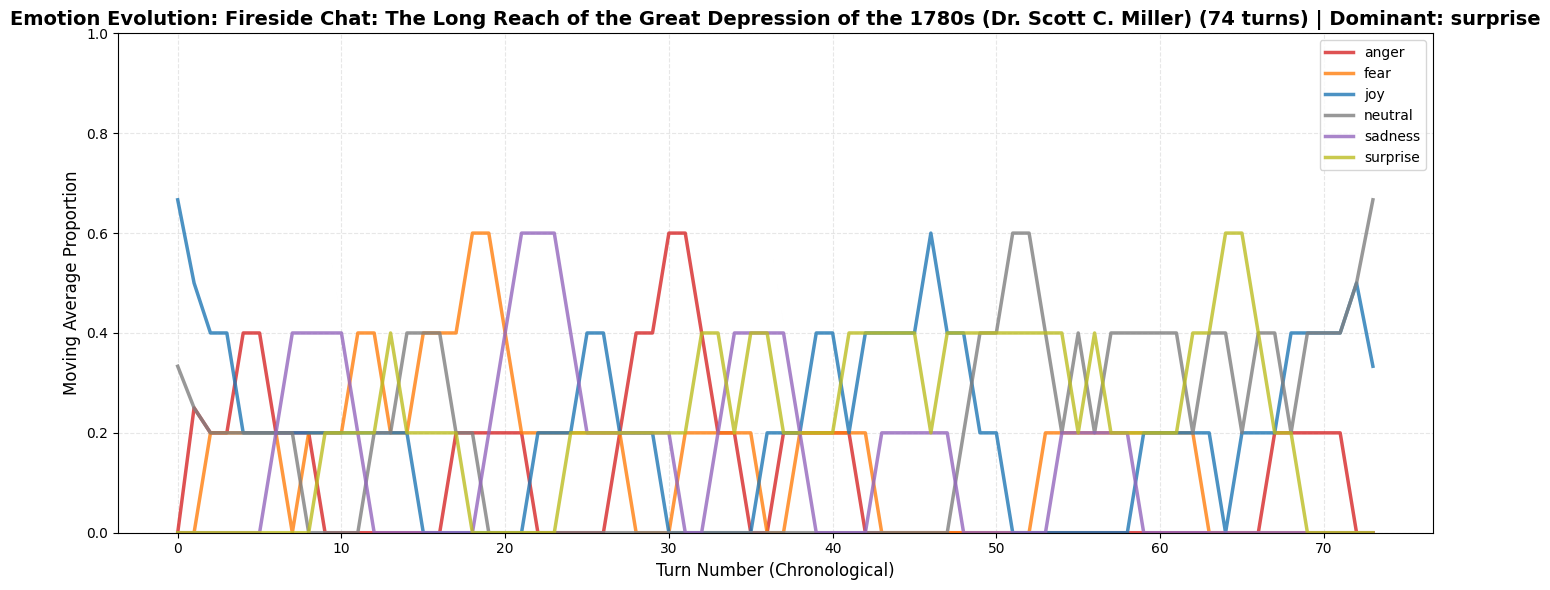

3. What Did The 5 Fingers Say to the Soul?... WAKE UP!!! (volatility: 0.863, diversity: 1.727)


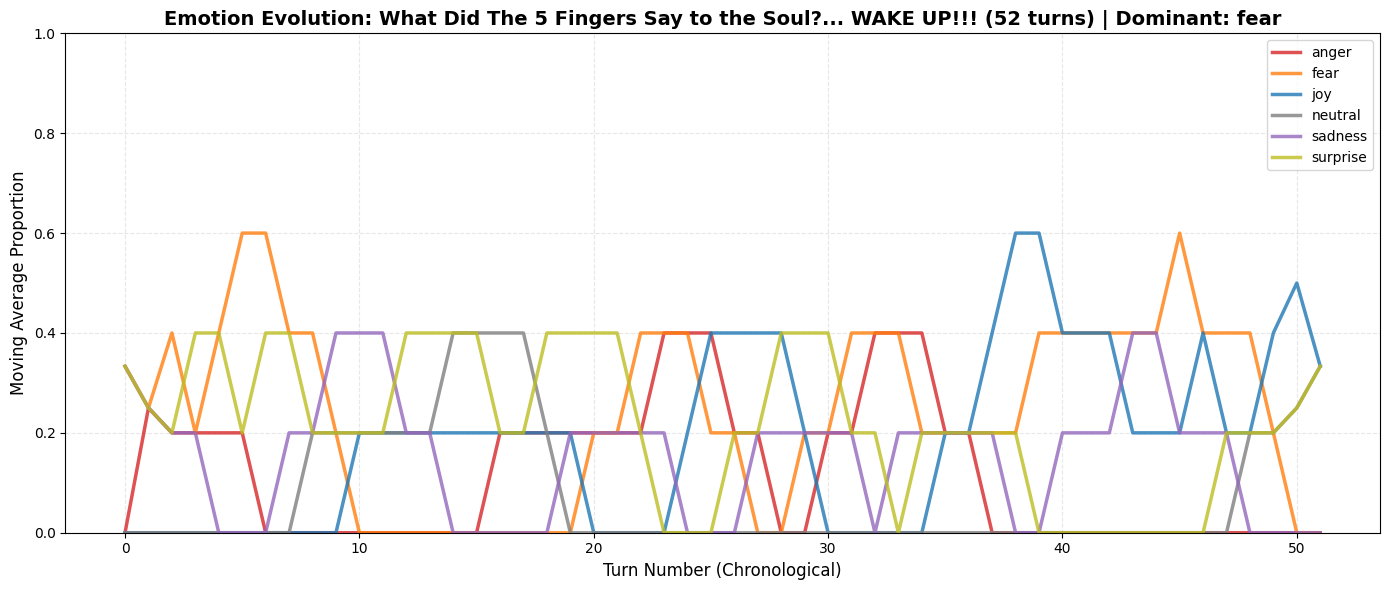

4. What Are You Made Of with Mike 'C-Roc' Ciorrocco (volatility: 0.855, diversity: 1.718)


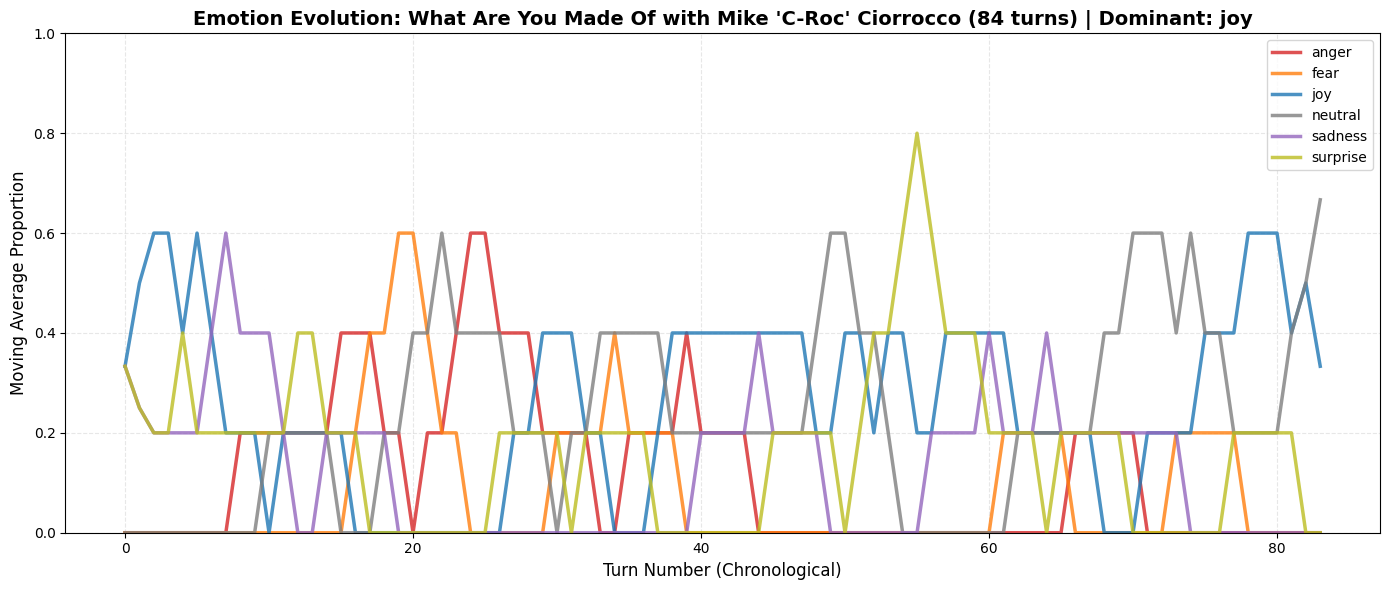

5. Sheep and Goat Care (volatility: 0.833, diversity: 1.593)


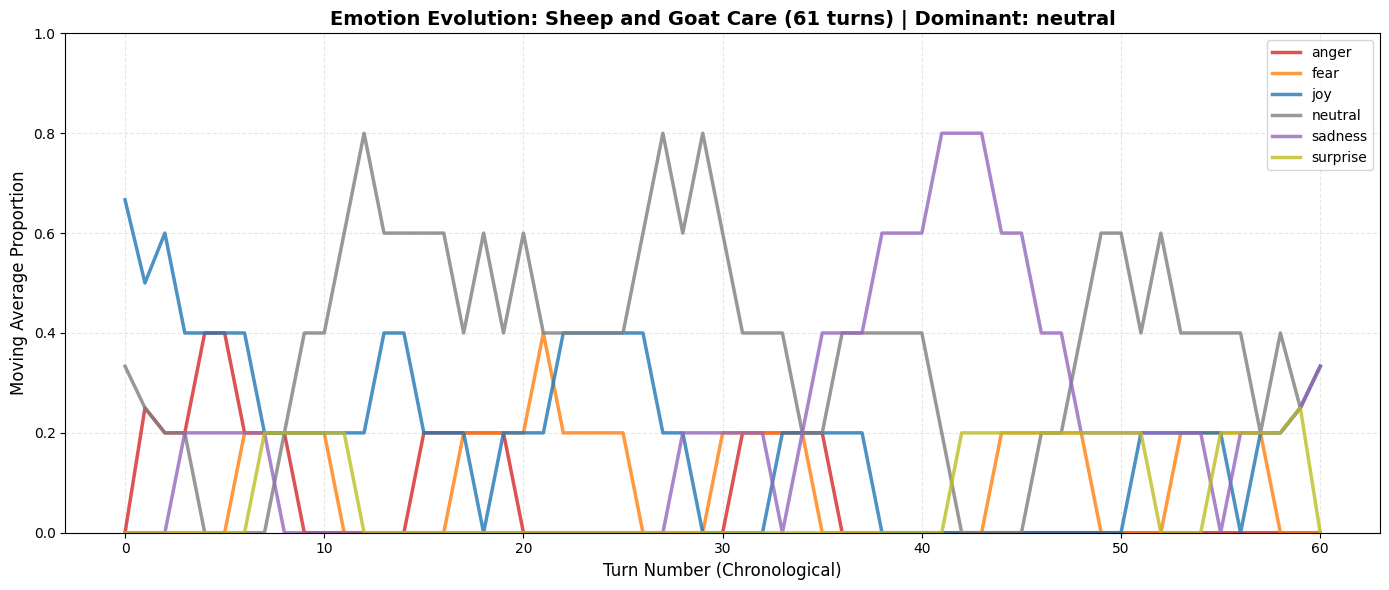

In [47]:
# Filter for episodes with >= 50 turns and plot top 10 most volatile
min_turn_threshold = 50
filtered_episodes = episode_summaries[episode_summaries['total_turns'] >= min_turn_threshold]
top_volatile = filtered_episodes.nlargest(5, 'volatility')
print(f"Plotting emotion evolution for top 5 most volatile episodes (min {min_turn_threshold} turns):\n")

for idx, (_, ep_summary) in enumerate(top_volatile.iterrows(), 1):
    print(f"{idx}. {ep_summary['epTitle']} (volatility: {ep_summary['volatility']:.3f}, diversity: {ep_summary['diversity']:.3f})")
    fig, ax = plot_emotion_evolution(ep_summary, emotion_colors, min_turns=min_turn_threshold)
    if fig is not None:
        plt.show()
        

#### 4.1.8a Average Emotion Probabilities (Least Volatile Episodes)

Plotting emotion evolution for top 5 most volatile episodes (min 50 turns):

1. Ep6: Planet Puffin - Netting Puffins (volatility: 0.355, diversity: 0.912)


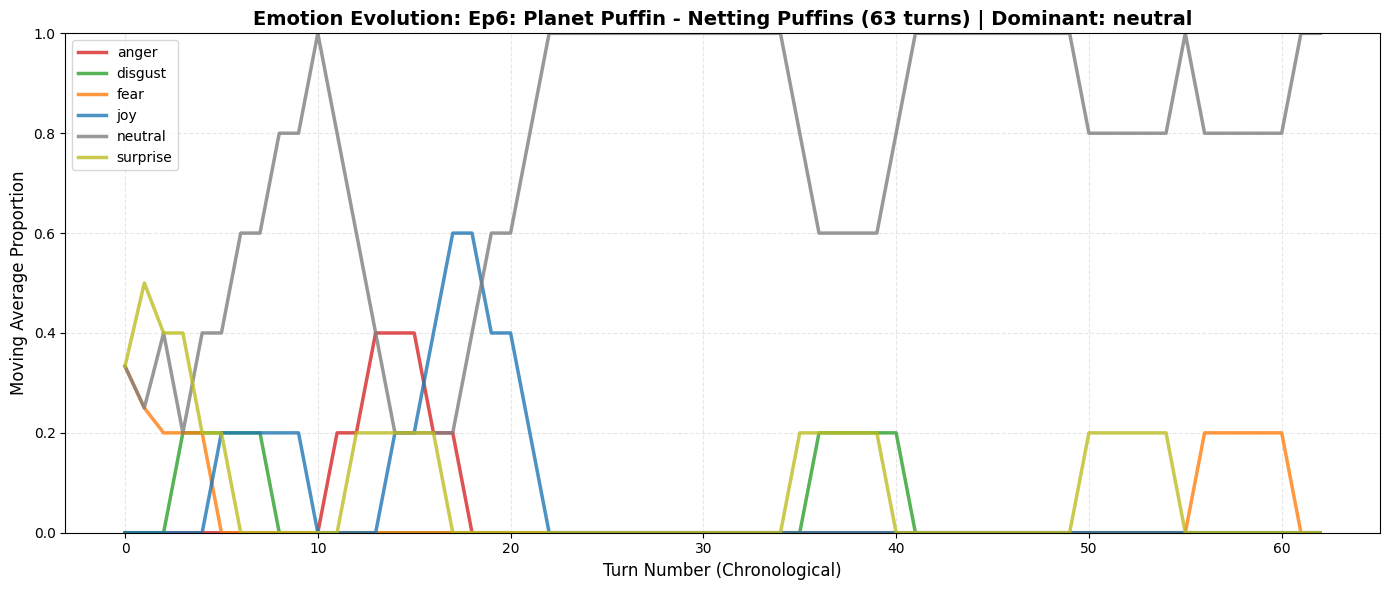

2. SOPP600: I'm currently learning the Dubois Toccata in G No 3 (volatility: 0.364, diversity: 0.845)


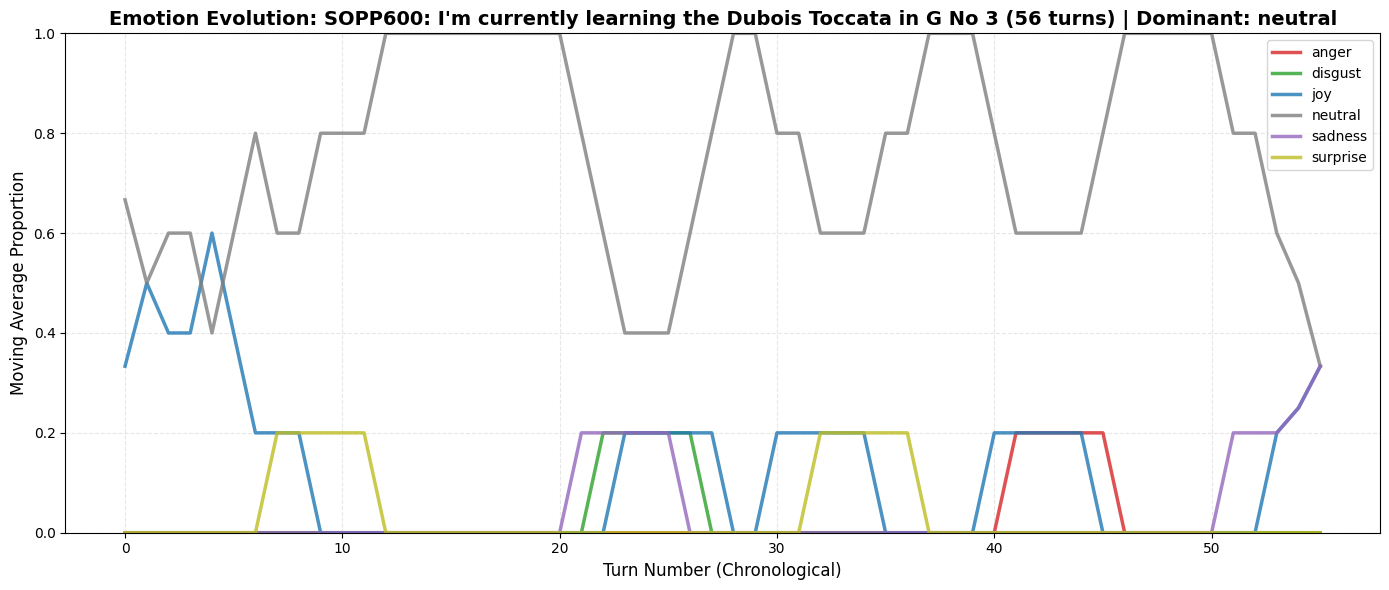

3. SOPP589: I am in the process of memorizing a piece, based upon what I am learning in this course! (volatility: 0.382, diversity: 0.925)


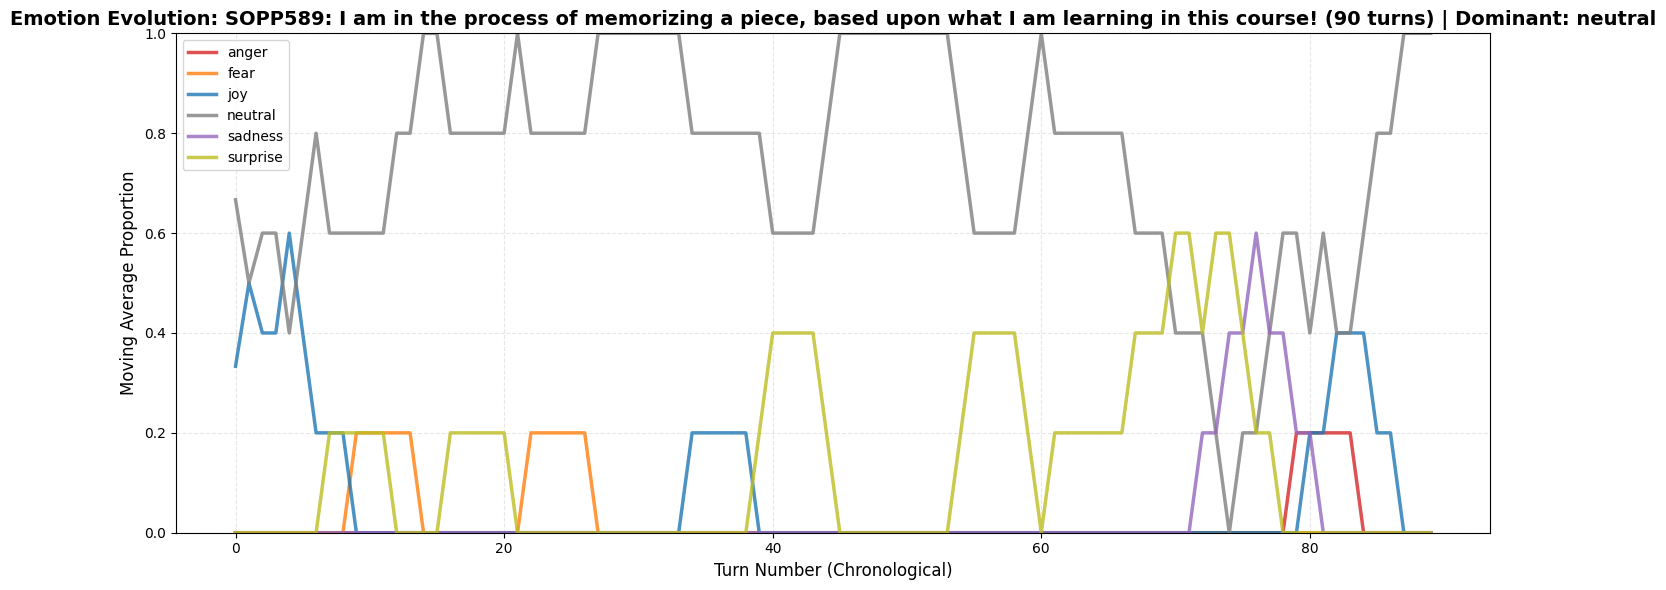

4. SOPP578: I would like to study the Bach's BWV 532 and 552 (volatility: 0.389, diversity: 0.902)


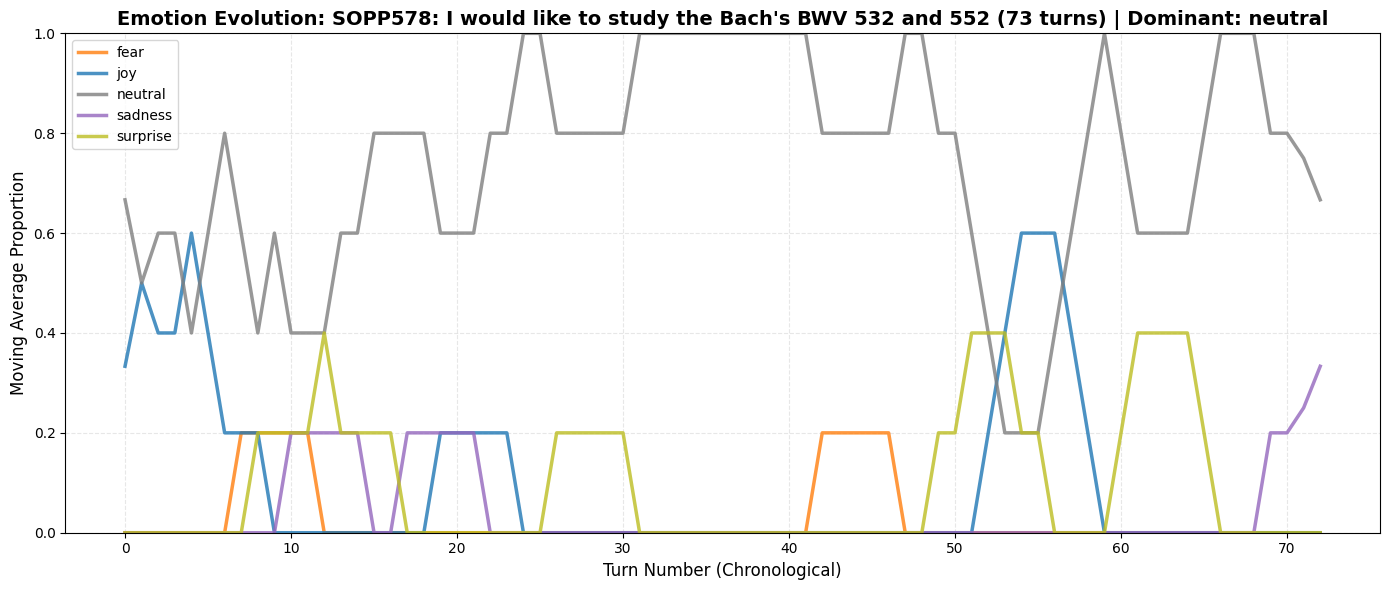

5. SOPP593: I am actually a jazz guitar player who has long been passionate about Baroque organ music (volatility: 0.392, diversity: 0.912)


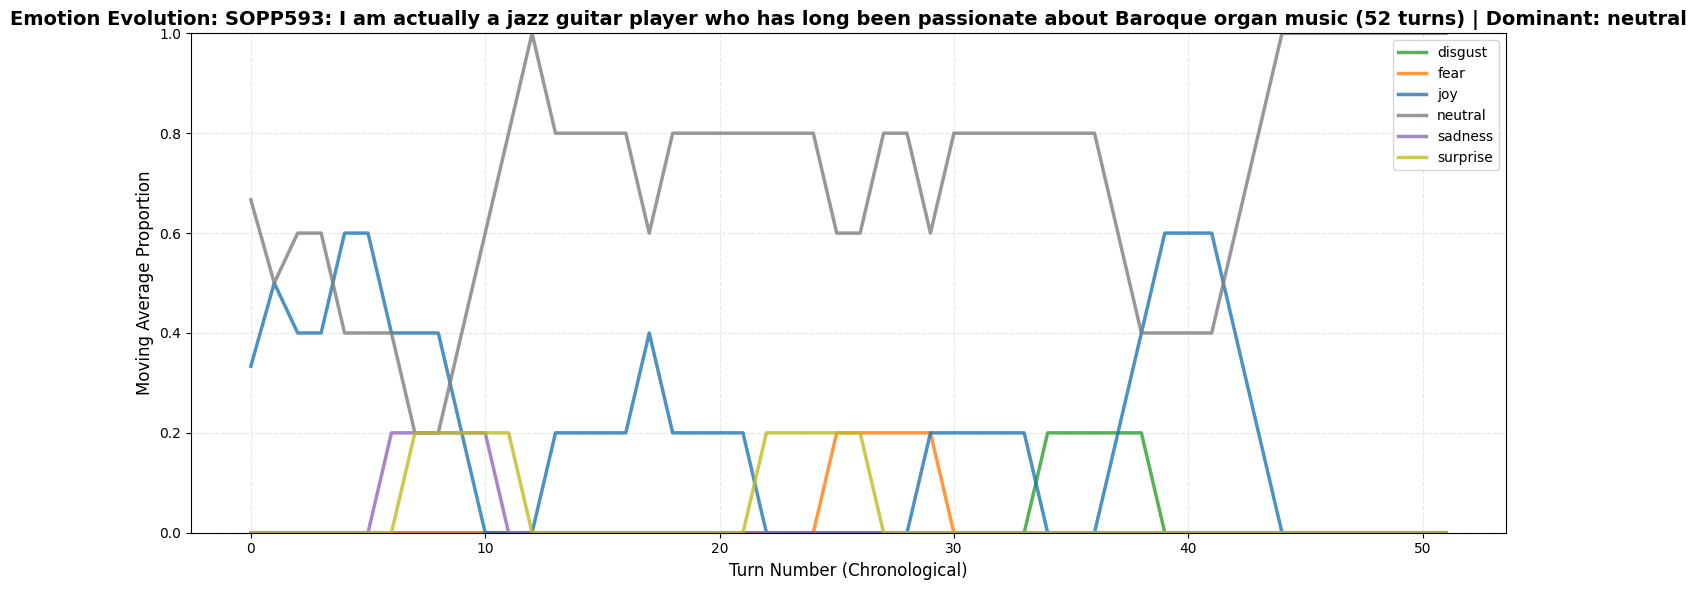

In [48]:
# Filter for episodes with >= 50 turns and plot top 10 most volatile
min_turn_threshold = 50
filtered_episodes = episode_summaries[episode_summaries['total_turns'] >= min_turn_threshold]
top_volatile = filtered_episodes.nsmallest(5, 'volatility')
print(f"Plotting emotion evolution for top 5 most volatile episodes (min {min_turn_threshold} turns):\n")

for idx, (_, ep_summary) in enumerate(top_volatile.iterrows(), 1):
    print(f"{idx}. {ep_summary['epTitle']} (volatility: {ep_summary['volatility']:.3f}, diversity: {ep_summary['diversity']:.3f})")
    fig, ax = plot_emotion_evolution(ep_summary, emotion_colors, min_turns=min_turn_threshold)
    if fig is not None:
        plt.show()

#### 4.1.9a Emotion Probabilities Examples (Most Volatile Episodes)

Episodes with 50+ turns: 565

Top 5 Most Volatile Episodes (50+ turns):

1. If I’m Honest: Real Life in Psalms // Clothed With Splendor // Chris Dolson | 06.28.2020 (53 turns, Volatility: 0.865)
2. Fireside Chat: The Long Reach of the Great Depression of the 1780s (Dr. Scott C. Miller) (74 turns, Volatility: 0.863)
3. What Did The 5 Fingers Say to the Soul?... WAKE UP!!! (52 turns, Volatility: 0.863)
4. What Are You Made Of with Mike 'C-Roc' Ciorrocco (84 turns, Volatility: 0.855)
5. Sheep and Goat Care (61 turns, Volatility: 0.833)


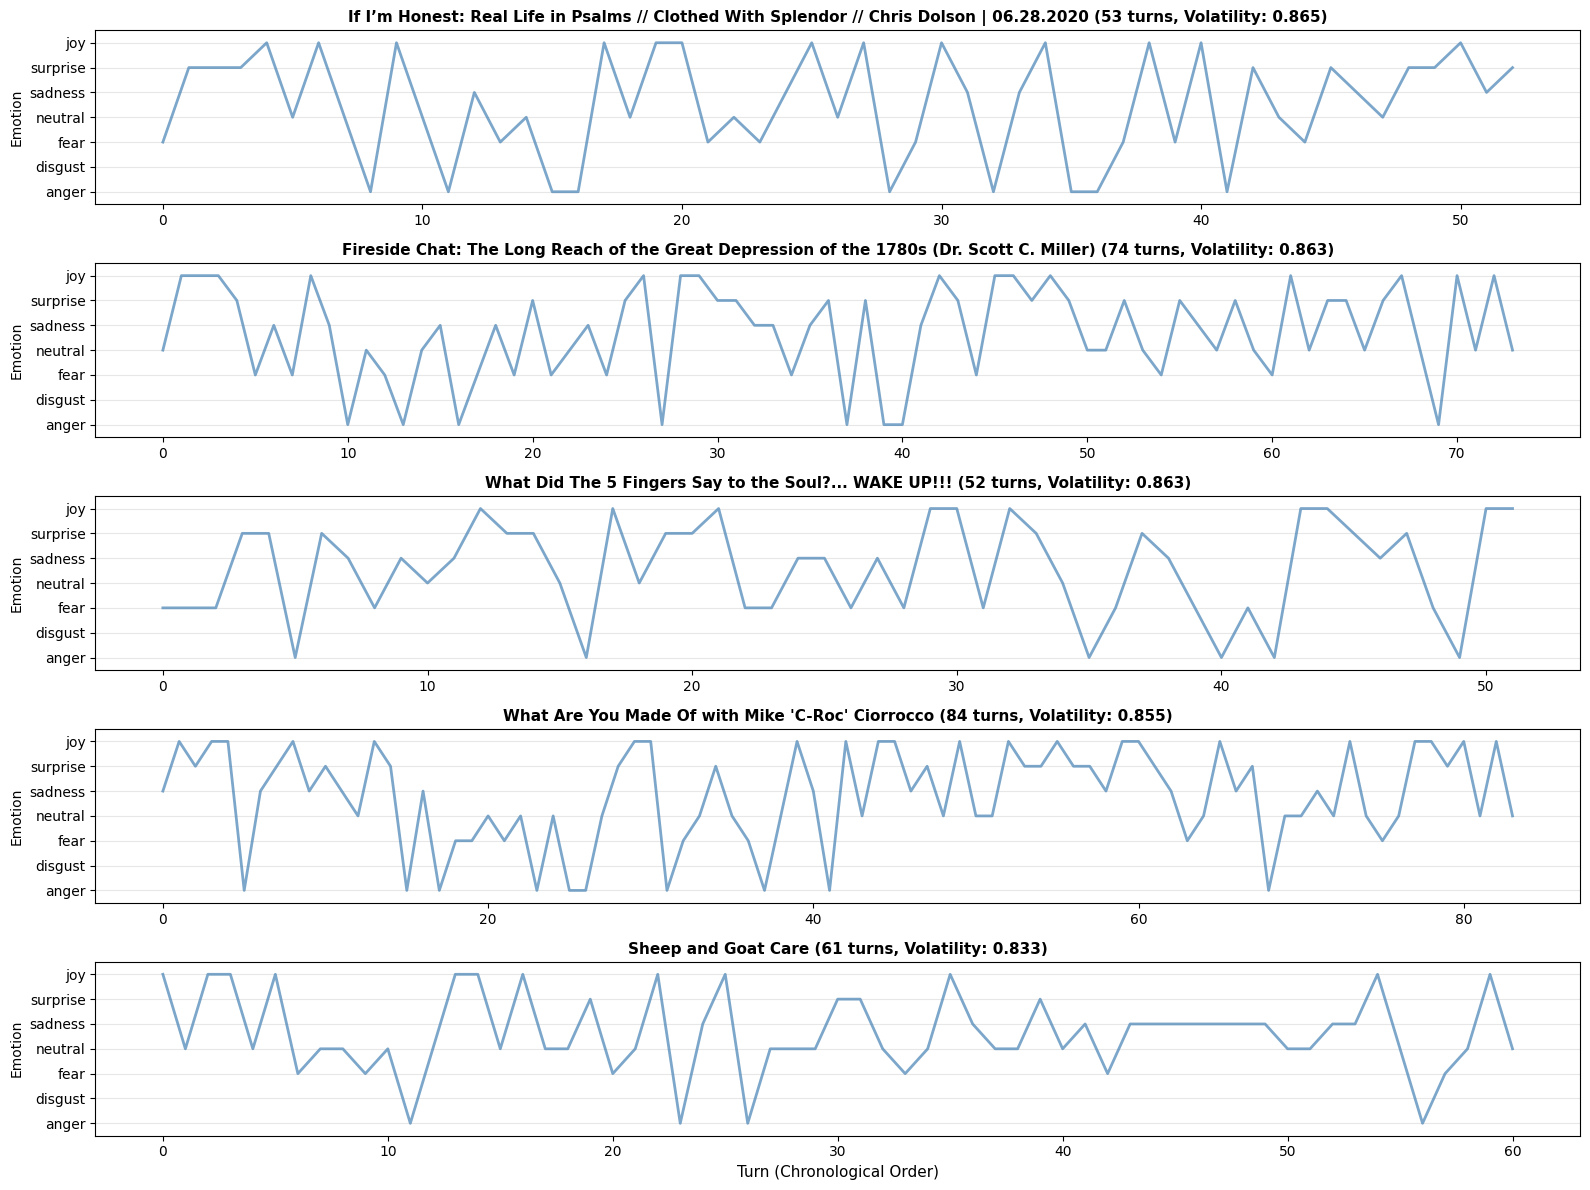

In [49]:
# Filter episodes with more than 50 turns
episodes_50plus = episode_summaries[episode_summaries['total_turns'] >= 50].copy()

print(f"Episodes with 50+ turns: {len(episodes_50plus)}")
print(f"\nTop 5 Most Volatile Episodes (50+ turns):\n")

# Get top 5 most volatile from episodes with 50+ turns
top_volatile_50 = episodes_50plus.nlargest(5, 'volatility')

for idx, (_, ep) in enumerate(top_volatile_50.iterrows()):
    print(f"{idx+1}. {ep['epTitle']} ({int(ep['total_turns'])} turns, Volatility: {ep['volatility']:.3f})")

# Create subplots for each episode
fig, axes = plt.subplots(5, 1, figsize=(16, 12))

# Map emotions to numeric values
emotion_map = {
    'anger': 0,
    'disgust': 1,
    'fear': 2,
    'neutral': 3,
    'sadness': 4,
    'surprise': 5,
    'joy': 6
}
emotion_labels = ['anger', 'disgust', 'fear', 'neutral', 'sadness', 'surprise', 'joy']

# Plot each episode
for idx, (_, ep) in enumerate(top_volatile_50.iterrows()):
    mp3_url = ep['mp3url']
    ep_title = ep['epTitle']
    
    # Get turns for this episode
    ep_turns = turns_df_full[turns_df_full['mp3url'] == mp3_url].copy()
    
    if len(ep_turns) == 0:
        continue
    
    # Map emotions to numbers
    ep_turns['emotion_numeric'] = ep_turns['emotion'].map(emotion_map)
    
    # Plot
    ax = axes[idx]
    ax.plot(range(len(ep_turns)), ep_turns['emotion_numeric'].values, linewidth=2, color='steelblue', alpha=0.7)
    
    # Formatting
    ax.set_yticks(range(len(emotion_labels)))
    ax.set_yticklabels(emotion_labels, fontsize=10)
    ax.set_ylabel('Emotion', fontsize=10)
    ax.set_title(f'{ep_title} ({len(ep_turns)} turns, Volatility: {ep["volatility"]:.3f})', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(-0.5, len(emotion_labels) - 0.5)
    
    if idx == 4:  # Only add x-label to bottom plot
        ax.set_xlabel('Turn (Chronological Order)', fontsize=11)

plt.tight_layout()
plt.show()

#### 4.1.9b Emotion Probabilities Examples (Most Volatile Episodes)

Episodes with 50+ turns: 565

Top 5 Least Volatile Episodes (50+ turns):

1. Ep6: Planet Puffin - Netting Puffins (63 turns, Volatility: 0.355)
2. SOPP600: I'm currently learning the Dubois Toccata in G No 3 (56 turns, Volatility: 0.364)
3. SOPP589: I am in the process of memorizing a piece, based upon what I am learning in this course! (90 turns, Volatility: 0.382)
4. SOPP578: I would like to study the Bach's BWV 532 and 552 (73 turns, Volatility: 0.389)
5. SOPP593: I am actually a jazz guitar player who has long been passionate about Baroque organ music (52 turns, Volatility: 0.392)


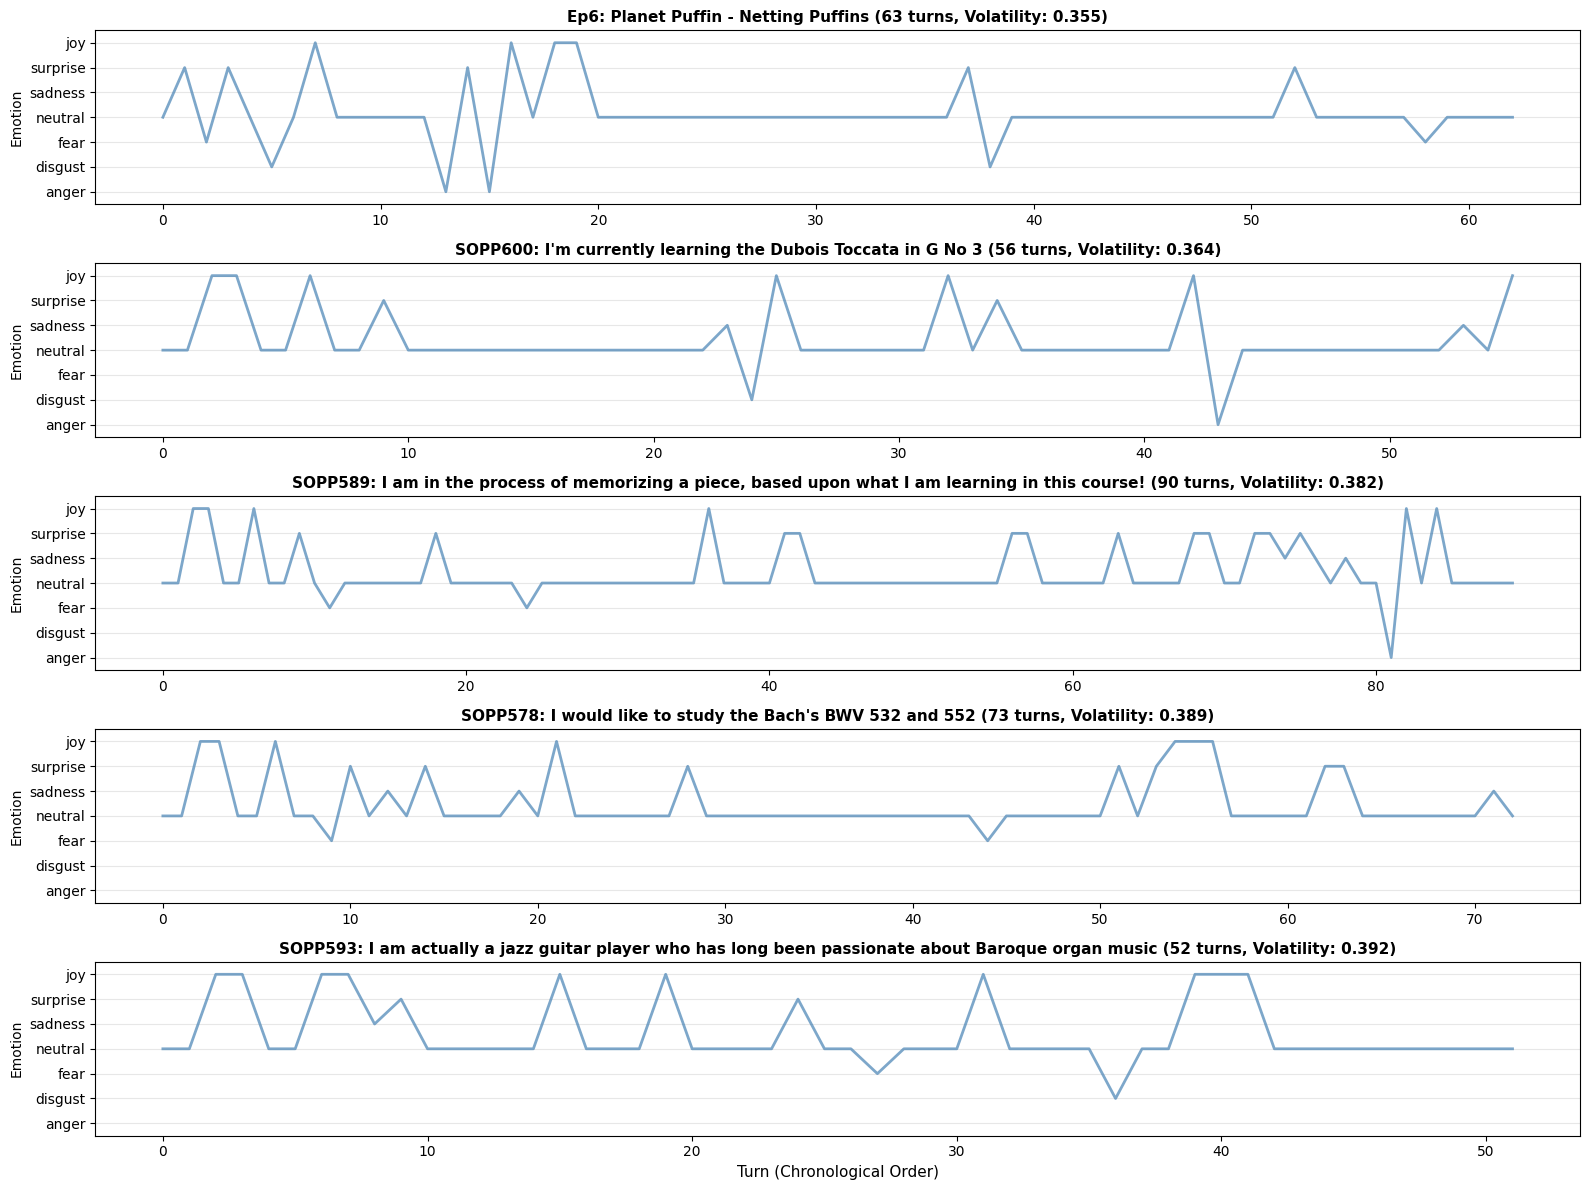

In [50]:
# Filter episodes with more than 50 turns
episodes_50plus = episode_summaries[episode_summaries['total_turns'] >= 50].copy()

print(f"Episodes with 50+ turns: {len(episodes_50plus)}")
print(f"\nTop 5 Least Volatile Episodes (50+ turns):\n")

# Get top 5 most volatile from episodes with 50+ turns
top_volatile_50 = episodes_50plus.nsmallest(5, 'volatility')

for idx, (_, ep) in enumerate(top_volatile_50.iterrows()):
    print(f"{idx+1}. {ep['epTitle']} ({int(ep['total_turns'])} turns, Volatility: {ep['volatility']:.3f})")

# Create subplots for each episode
fig, axes = plt.subplots(5, 1, figsize=(16, 12))

# Map emotions to numeric values
emotion_map = {
    'anger': 0,
    'disgust': 1,
    'fear': 2,
    'neutral': 3,
    'sadness': 4,
    'surprise': 5,
    'joy': 6
}
emotion_labels = ['anger', 'disgust', 'fear', 'neutral', 'sadness', 'surprise', 'joy']

# Plot each episode
for idx, (_, ep) in enumerate(top_volatile_50.iterrows()):
    mp3_url = ep['mp3url']
    ep_title = ep['epTitle']
    
    # Get turns for this episode
    ep_turns = turns_df_full[turns_df_full['mp3url'] == mp3_url].copy()
    
    if len(ep_turns) == 0:
        continue
    
    # Map emotions to numbers
    ep_turns['emotion_numeric'] = ep_turns['emotion'].map(emotion_map)
    
    # Plot
    ax = axes[idx]
    ax.plot(range(len(ep_turns)), ep_turns['emotion_numeric'].values, linewidth=2, color='steelblue', alpha=0.7)
    
    # Formatting
    ax.set_yticks(range(len(emotion_labels)))
    ax.set_yticklabels(emotion_labels, fontsize=10)
    ax.set_ylabel('Emotion', fontsize=10)
    ax.set_title(f'{ep_title} ({len(ep_turns)} turns, Volatility: {ep["volatility"]:.3f})', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(-0.5, len(emotion_labels) - 0.5)
    
    if idx == 4:  # Only add x-label to bottom plot
        ax.set_xlabel('Turn (Chronological Order)', fontsize=11)

plt.tight_layout()
plt.show()

## 5. Brand Safety Analysis

This section focuses on assessing the safety of podcast content by detecting potentially toxic, offensive, or unsafe language. We use a pretrained toxicity detection model to analyze episode-level transcripts and produce safety metrics suitable for content moderation and brand alignment decisions.

### 5.1 Overview

**Objective**: Assess the brand safety and content appropriateness of podcast episodes using automated toxicity detection.

**Approach**:
1. **Toxicity Detection Model**: Use a pretrained toxicity classifier (e.g., `unitary/toxic-bert`) to evaluate episode-level text
2. **Safety Metrics**: Compute episode-level safety statistics:
   - **Toxicity Ratio**: Percentage of content flagged as toxic/offensive
   - **Max Toxicity Score**: Highest individual toxicity score in the episode
   - **Mean Toxicity Score**: Average toxicity across segments
   - **Safety Label**: Binary classification (safe/unsafe) based on threshold
3. **Aggregation**: Combine turn-level predictions into episode-level summaries
4. **Visualization**: Display safety distributions across episodes and categories

**Expected Output**:
- Episode-level safety ratings and toxicity distributions
- Breakdowns by category (e.g., Comedy vs. News)
- Flagged episodes requiring human review
- Dashboard summarizing brand-safe content ratio


### 5.2 Install and Load Toxicity Detection Model

We use the `unitary/toxic-bert` model from Hugging Face, a pretrained transformer fine-tuned on toxicity classification. The model detects offensive, toxic, and potentially brand-unsafe language.

In [53]:
from transformers import pipeline
import numpy as np
import pandas as pd
import torch

# Load toxicity detection model
print("Loading toxicity detection model...")
toxicity_classifier = pipeline(
    "text-classification",
    model="unitary/toxic-bert",
    device=device,  # Use GPU if available
    truncation=True,
    max_length=256
)

print("Toxicity model loaded successfully!")
print(f"Model: unitary/toxic-bert")
print(f"Task: Multi-label toxicity classification (toxic/non-toxic)")


Loading toxicity detection model...


/opt/miniconda3/envs/nlp/lib/python3.12/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/opt/miniconda3/envs/nlp/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Toxicity model loaded successfully!
Model: unitary/toxic-bert
Task: Multi-label toxicity classification (toxic/non-toxic)


### 5.3 Compute Turn-Level Toxicity Scores

We apply the toxicity model to each speaker turn and record toxicity probabilities. This provides granular insight into where unsafe content appears within an episode.

In [54]:
import os, time
import numpy as np

toxicity_cache_path = "data/toxicity_cache/toxicity_scores.csv"


def get_toxic_prob(score_list):
    """
    score_list: list of dicts [{'label':..., 'score':...}, ...] for ONE text
    returns: P(TOXIC)
    """
    # try common label names
    for d in score_list:
        lab = d["label"].lower()
        if "toxic" in lab and "non" not in lab:   # matches "TOXIC", "toxic", etc.
            return float(d["score"])
    # fallback if labels are like LABEL_0 / LABEL_1:
    # assume LABEL_1 is toxic (common), otherwise take max as last resort
    by_label = {d["label"]: float(d["score"]) for d in score_list}
    if "LABEL_1" in by_label:
        return by_label["LABEL_1"]
    return max(by_label.values())


if os.path.exists(toxicity_cache_path):
    turns_df_full = pd.read_csv(toxicity_cache_path)
else:
    texts = turns_df_full["turnText"].fillna("").astype(str).tolist()

    batch_size = 256 if torch.cuda.is_available() else 32
    max_char_len = 1000

    toxicity_score = np.zeros(len(texts), dtype=np.float32)

    start = time.time()
    for idx in range(0, len(texts), batch_size):
        batch = texts[idx:idx+batch_size]

        run_texts, run_pos = [], []
        for j, t in enumerate(batch):
            t = t.strip()
            if not t:
                continue
            if len(t) > max_char_len:
                t = t[:max_char_len]
            run_texts.append(t)
            run_pos.append(idx + j)

        if not run_texts:
            continue

        # ✅ one call per batch, and get both class scores
        preds = toxicity_classifier(run_texts, return_all_scores=True)

        for p, pos in zip(preds, run_pos):
            toxicity_score[pos] = get_toxic_prob(p)

        if (idx // batch_size + 1) % 10 == 0:
            print(f"Processed {min(idx+batch_size, len(texts))}/{len(texts)} in {time.time()-start:.1f}s")

    turns_df_full["toxicity_score"] = toxicity_score
    turns_df_full["toxicity_label"] = np.where(turns_df_full["toxicity_score"] >= 0.5, "TOXIC", "NON_TOXIC")

    os.makedirs(os.path.dirname(toxicity_cache_path), exist_ok=True)
    turns_df_full.to_csv(toxicity_cache_path, index=False)

    os.makedirs(os.path.dirname(toxicity_cache_path), exist_ok=True)
    turns_df_full.to_csv(toxicity_cache_path, index=False)
    print(f"Saved cache to {toxicity_cache_path}")

    print(f"\nToxicity scores computed!")
    print(f"Toxicity label distribution:")
    print(turns_df_full['toxicity_label'].value_counts())
    print(f"\nToxicity score statistics:")
    print(turns_df_full['toxicity_score'].describe())

### 5.4 Aggregate Toxicity to Episode Level

We aggregate turn-level toxicity scores into episode-level summary statistics: maximum toxicity, mean toxicity, percentage flagged as toxic, and a binary safety label based on a threshold.

In [55]:
# Save toxicity scores to CSV
toxicity_cache_path = "data/toxicity_cache/toxicity_scores.csv"

# Create the cache directory if it doesn't exist
import os
os.makedirs(os.path.dirname(toxicity_cache_path), exist_ok=True)

# Save the dataframe with toxicity scores
turns_df_full.to_csv(toxicity_cache_path, index=False)

print(f"Toxicity scores saved to: {toxicity_cache_path}")
print(f"Total rows saved: {len(turns_df_full)}")
print(f"Columns: {list(turns_df_full.columns)}")
print(f"\n✓ Cache is ready for future runs - the computation will be skipped if this file exists!")

Toxicity scores saved to: data/toxicity_cache/toxicity_scores.csv
Total rows saved: 123379
Columns: ['mp3url', 'epTitle', 'speaker', 'turnText', 'startTime', 'endTime', 'emotion', 'emotion_score', 'anger_prob', 'disgust_prob', 'fear_prob', 'joy_prob', 'neutral_prob', 'sadness_prob', 'surprise_prob', 'toxicity_score', 'toxicity_label']

✓ Cache is ready for future runs - the computation will be skipped if this file exists!


In [56]:
# Define safety thresholds
TOXICITY_THRESHOLD = 0.5  # Classify turn as toxic if score >= threshold
EPISODE_SAFETY_THRESHOLD = 0.15  # Episode unsafe if toxicity ratio >= threshold

# Aggregate toxicity scores to episode level - use ALL episodes
episode_safety = []

# Get all unique episodes from turns_df_full (not filtered by episode_summaries)
all_mp3_urls = turns_df_full['mp3url'].unique()

for mp3_url in all_mp3_urls:
    # Get all turns for this episode
    ep_turns = turns_df_full[turns_df_full['mp3url'] == mp3_url].copy()
    
    if len(ep_turns) == 0:
        continue
    
    # Compute toxicity metrics
    toxicity_scores = ep_turns['toxicity_score'].values
    toxic_flags = (toxicity_scores >= TOXICITY_THRESHOLD).astype(int)
    
    max_toxicity = float(toxicity_scores.max())
    mean_toxicity = float(toxicity_scores.mean())
    toxicity_ratio = float(toxic_flags.sum() / len(toxic_flags))
    
    # Determine safety label
    is_safe = toxicity_ratio < EPISODE_SAFETY_THRESHOLD
    
    # Get episode info from episode_df1
    ep_info = episode_df1[episode_df1['mp3url'] == mp3_url]
    if len(ep_info) == 0:
        continue
    
    ep_title = ep_info.iloc[0]['epTitle']
    category = ep_info.iloc[0]['category1']
    
    episode_safety.append({
        'mp3url': mp3_url,
        'epTitle': ep_title,
        'category1': category,
        'max_toxicity': max_toxicity,
        'mean_toxicity': mean_toxicity,
        'toxicity_ratio': toxicity_ratio,
        'toxic_turns_count': int(toxic_flags.sum()),
        'total_turns': len(ep_turns),
        'is_safe': is_safe,
        'safety_label': 'Safe' if is_safe else 'Unsafe'
    })

# Create safety dataframe
safety_df = pd.DataFrame(episode_safety)

print("Episode-Level Safety Summary:")
print(f"Total episodes analyzed: {len(safety_df)}")
print(f"Total episodes in dataset: {len(episode_df1)}")
print(f"\nSafety distribution:")
print(safety_df['safety_label'].value_counts())
print(f"\nSafety percentage: {(safety_df['is_safe'].sum() / len(safety_df) * 100):.1f}% of episodes are safe")

print(f"\n=== Toxicity Metrics ===")
print(f"Max toxicity (max per episode):")
print(f"  Mean: {safety_df['max_toxicity'].mean():.3f}")
print(f"  Median: {safety_df['max_toxicity'].median():.3f}")
print(f"  Std: {safety_df['max_toxicity'].std():.3f}")

print(f"\nMean toxicity (average per episode):")
print(f"  Mean: {safety_df['mean_toxicity'].mean():.3f}")
print(f"  Median: {safety_df['mean_toxicity'].median():.3f}")
print(f"  Std: {safety_df['mean_toxicity'].std():.3f}")

print(f"\nToxicity ratio (% toxic turns per episode):")
print(f"  Mean: {safety_df['toxicity_ratio'].mean():.3f}")
print(f"  Median: {safety_df['toxicity_ratio'].median():.3f}")
print(f"  Std: {safety_df['toxicity_ratio'].std():.3f}")

Episode-Level Safety Summary:
Total episodes analyzed: 907
Total episodes in dataset: 907

Safety distribution:
safety_label
Safe      852
Unsafe     55
Name: count, dtype: int64

Safety percentage: 93.9% of episodes are safe

=== Toxicity Metrics ===
Max toxicity (max per episode):
  Mean: 0.517
  Median: 0.514
  Std: 0.385

Mean toxicity (average per episode):
  Mean: 0.050
  Median: 0.023
  Std: 0.079

Toxicity ratio (% toxic turns per episode):
  Mean: 0.037
  Median: 0.004
  Std: 0.081


### 5.5 Visualize Safety Distribution

Display toxicity metrics across all episodes with summary statistics and safety distribution plots.

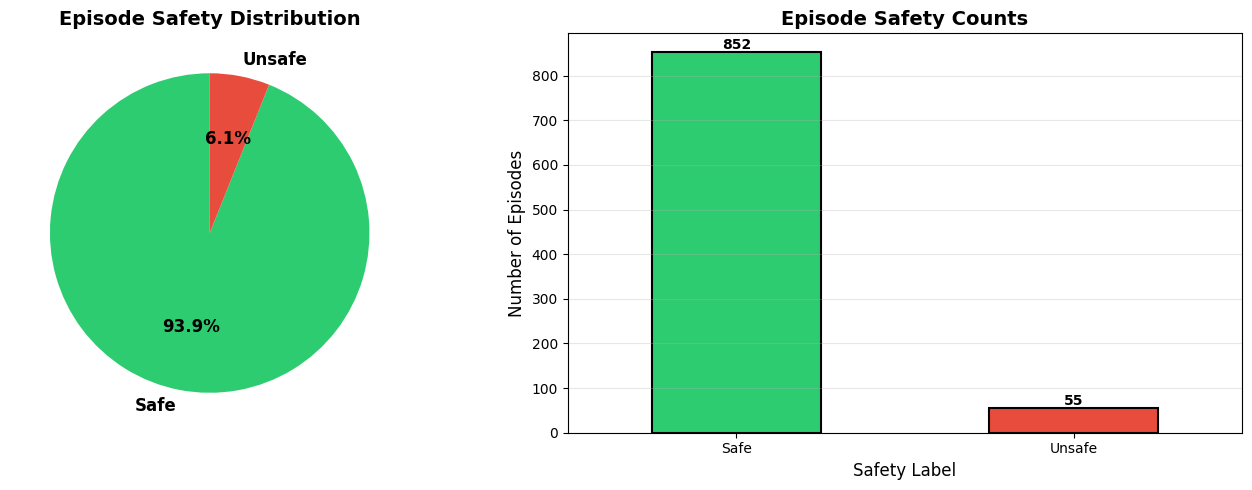

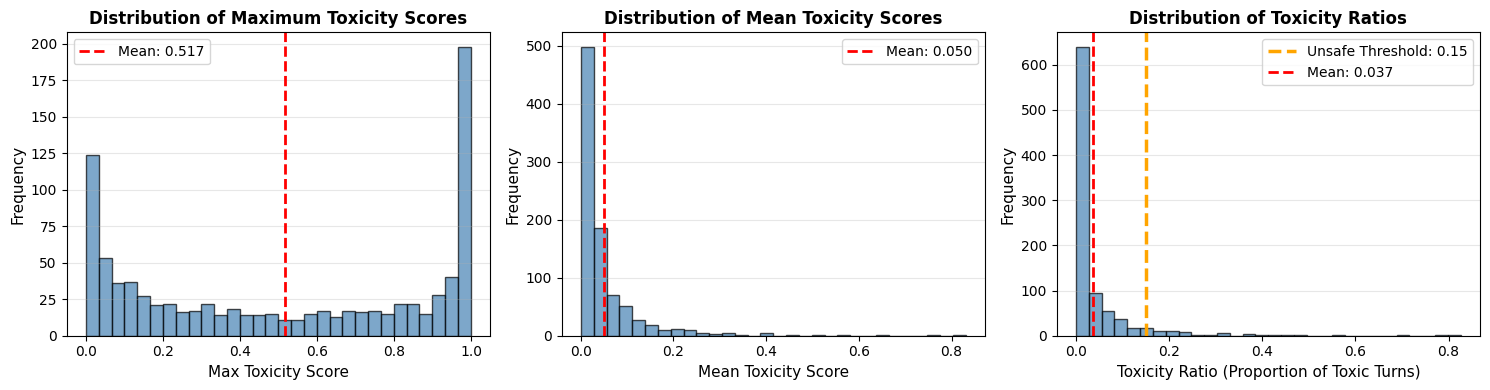

In [57]:
# Plot 1: Safety Label Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart of safety distribution
safety_counts = safety_df['safety_label'].value_counts()
colors_safety = ['#2ecc71', '#e74c3c']  # Green for Safe, Red for Unsafe
axes[0].pie(safety_counts.values, labels=safety_counts.index, autopct='%1.1f%%', 
            colors=colors_safety, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
axes[0].set_title('Episode Safety Distribution', fontsize=14, fontweight='bold')

# Bar chart
safety_counts.plot(kind='bar', ax=axes[1], color=colors_safety, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Safety Label', fontsize=12)
axes[1].set_ylabel('Number of Episodes', fontsize=12)
axes[1].set_title('Episode Safety Counts', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(safety_counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Plot 2: Toxicity Score Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Max toxicity histogram
axes[0].hist(safety_df['max_toxicity'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(safety_df['max_toxicity'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {safety_df["max_toxicity"].mean():.3f}')
axes[0].set_xlabel('Max Toxicity Score', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Maximum Toxicity Scores', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Mean toxicity histogram
axes[1].hist(safety_df['mean_toxicity'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(safety_df['mean_toxicity'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {safety_df["mean_toxicity"].mean():.3f}')
axes[1].set_xlabel('Mean Toxicity Score', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Distribution of Mean Toxicity Scores', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Toxicity ratio histogram
axes[2].hist(safety_df['toxicity_ratio'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[2].axvline(EPISODE_SAFETY_THRESHOLD, color='orange', linestyle='--', linewidth=2.5, label=f'Unsafe Threshold: {EPISODE_SAFETY_THRESHOLD}')
axes[2].axvline(safety_df['toxicity_ratio'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {safety_df["toxicity_ratio"].mean():.3f}')
axes[2].set_xlabel('Toxicity Ratio (Proportion of Toxic Turns)', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].set_title('Distribution of Toxicity Ratios', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 5.6 Safety Analysis by Category

Break down safety metrics by episode category to understand which content types are more likely to contain unsafe material.

Safety Metrics for Top 20 Most Popular Categories:
            Safe_Count  Total_Count  Safe_Pct  Avg_Toxicity_Ratio  Median_Toxicity_Ratio  Avg_Mean_Toxicity  Avg_Max_Toxicity
category1                                                                                                                    
business           157          157   100.000               0.010                  0.000              0.018             0.358
technology           8            8   100.000               0.003                  0.000              0.009             0.267
fiction              3            3   100.000               0.062                  0.079              0.070             0.699
government           3            3   100.000               0.013                  0.017              0.039             0.439
science              4            4   100.000               0.040                  0.036              0.054             0.575
kids                 4            4   100.000               0.051  

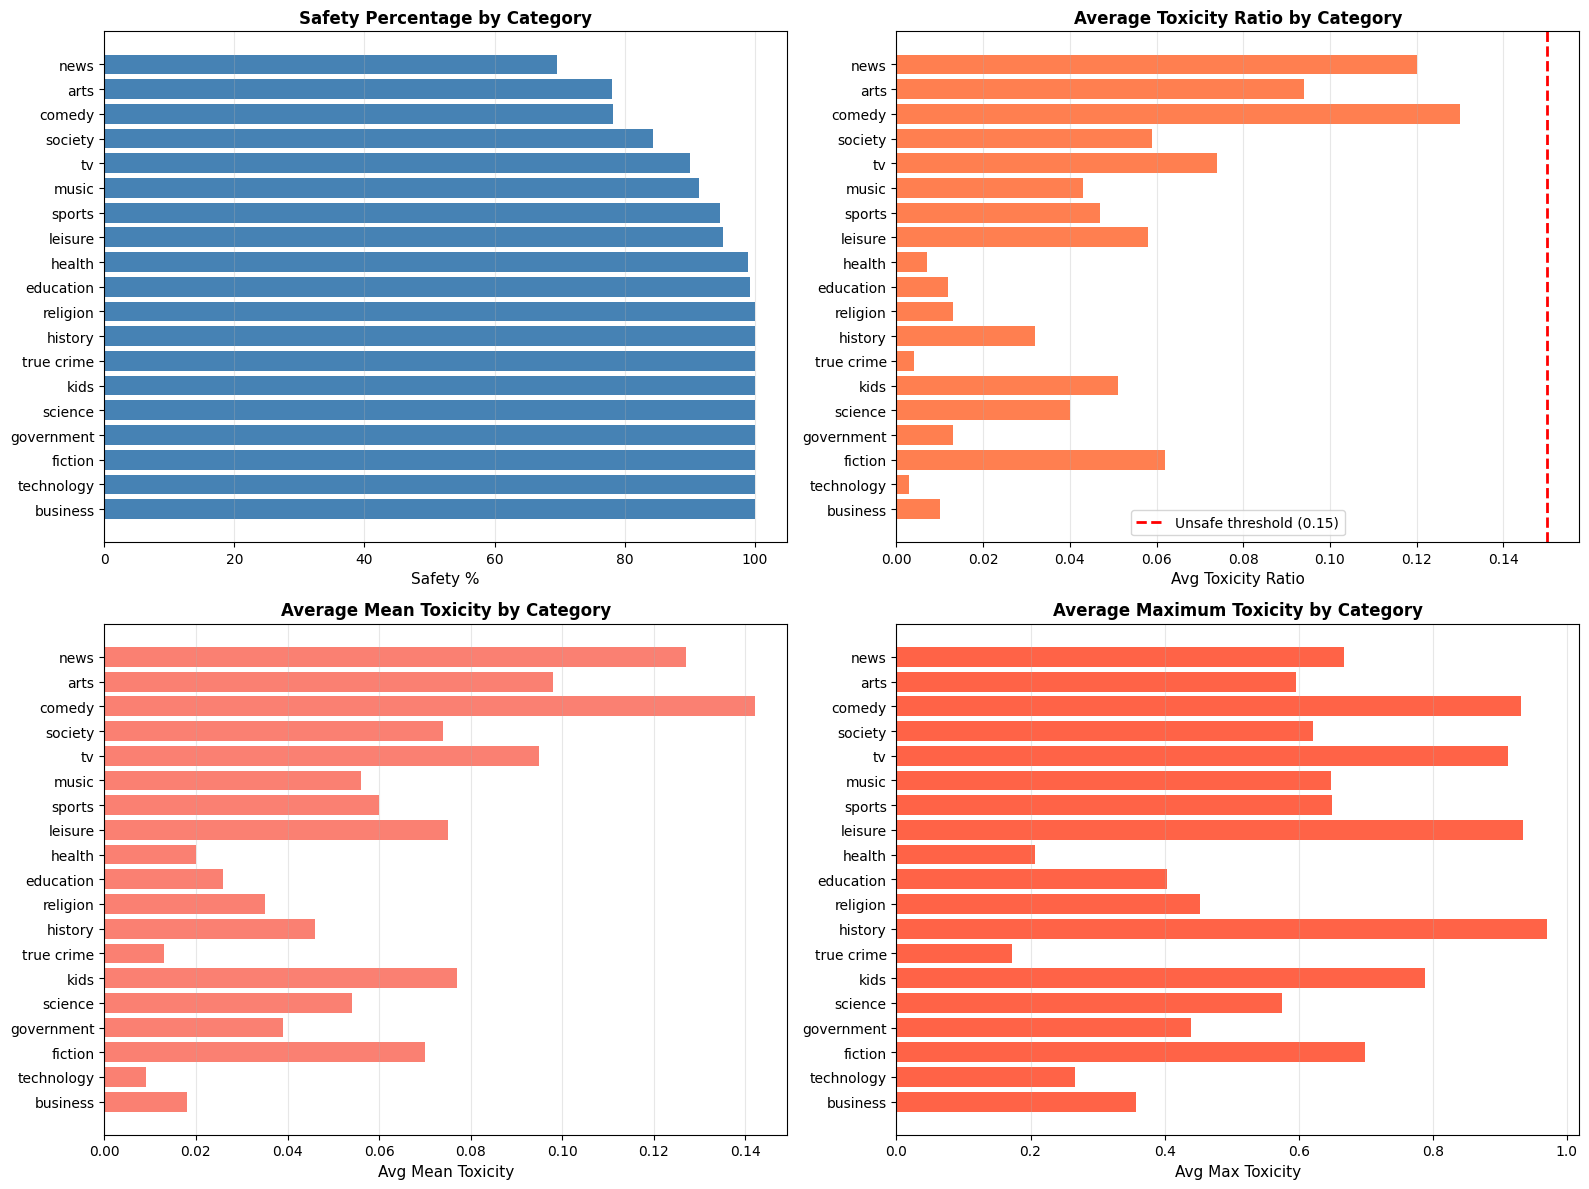

In [58]:
# Group by category and compute safety metrics
category_safety = safety_df.groupby('category1').agg({
    'is_safe': ['sum', 'count', lambda x: (x.sum() / len(x) * 100)],
    'toxicity_ratio': ['mean', 'median'],
    'mean_toxicity': 'mean',
    'max_toxicity': 'mean'
}).round(3)

category_safety.columns = ['Safe_Count', 'Total_Count', 'Safe_Pct', 
                           'Avg_Toxicity_Ratio', 'Median_Toxicity_Ratio',
                           'Avg_Mean_Toxicity', 'Avg_Max_Toxicity']

# Filter for top 20 most popular categories
top_20_categories = category_safety.nlargest(20, 'Total_Count')
top_20_categories = top_20_categories.sort_values('Safe_Pct', ascending=False)

print("Safety Metrics for Top 20 Most Popular Categories:")
print(top_20_categories.to_string())

# Create bar charts for top 20 categories
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Safety %
axes[0, 0].barh(top_20_categories.index, top_20_categories['Safe_Pct'], color='steelblue')
axes[0, 0].set_xlabel('Safety %', fontsize=11)
axes[0, 0].set_title('Safety Percentage by Category', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Avg Toxicity Ratio
axes[0, 1].barh(top_20_categories.index, top_20_categories['Avg_Toxicity_Ratio'], color='coral')
axes[0, 1].axvline(0.15, color='red', linestyle='--', linewidth=2, label='Unsafe threshold (0.15)')
axes[0, 1].set_xlabel('Avg Toxicity Ratio', fontsize=11)
axes[0, 1].set_title('Average Toxicity Ratio by Category', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(axis='x', alpha=0.3)

# Mean Toxicity
axes[1, 0].barh(top_20_categories.index, top_20_categories['Avg_Mean_Toxicity'], color='salmon')
axes[1, 0].set_xlabel('Avg Mean Toxicity', fontsize=11)
axes[1, 0].set_title('Average Mean Toxicity by Category', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Max Toxicity
axes[1, 1].barh(top_20_categories.index, top_20_categories['Avg_Max_Toxicity'], color='tomato')
axes[1, 1].set_xlabel('Avg Max Toxicity', fontsize=11)
axes[1, 1].set_title('Average Maximum Toxicity by Category', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 5.7 Identify Flagged Episodes

Display episodes flagged as unsafe for further review by content moderation teams.

In [59]:
# Show top 20 unsafe episodes (highest toxicity)
unsafe_episodes = safety_df[safety_df['is_safe'] == False].copy()
unsafe_episodes = unsafe_episodes.sort_values('toxicity_ratio', ascending=False).head(20)

print("=== TOP 20 FLAGGED (UNSAFE) EPISODES ===\n")

if len(unsafe_episodes) > 0:
    display_cols = ['epTitle', 'category1', 'toxicity_ratio', 'mean_toxicity', 'max_toxicity', 'toxic_turns_count', 'total_turns']
    print(unsafe_episodes[display_cols].to_string(index=False))
else:
    print("No unsafe episodes found!")

# Show episodes with highest individual toxic turns
print("\n\n=== TOP 15 EPISODES WITH HIGHEST MAXIMUM TOXICITY SCORE ===\n")
top_max_toxic = safety_df.nlargest(15, 'max_toxicity')
print(top_max_toxic[['epTitle', 'category1', 'max_toxicity', 'mean_toxicity', 'toxicity_ratio']].to_string(index=False))

# Show safe episodes for reference
safe_episodes = safety_df[safety_df['is_safe'] == True].copy()
print(f"\n\n=== SAFE EPISODES SUMMARY ===")
print(f"Total safe episodes: {len(safe_episodes)}")
print(f"\nSafest episodes (lowest mean toxicity):")
safest = safe_episodes.nsmallest(10, 'mean_toxicity')
print(safest[['epTitle', 'category1', 'mean_toxicity', 'max_toxicity', 'total_turns']].to_string(index=False))


=== TOP 20 FLAGGED (UNSAFE) EPISODES ===

                                                                            epTitle category1  toxicity_ratio  mean_toxicity  max_toxicity  toxic_turns_count  total_turns
                                                                  #TurnUpForJustice      news        0.826087       0.830537      0.998585                 19           23
                                             Maxy Smythe plays the Gold Dust Saloon    comedy        0.777778       0.764913      0.998996                  7            9
                                                            Who Gives A $#!t?? Pt.1      arts        0.708333       0.647457      0.998919                 34           48
                                                   Off the rails 😳/The Sade Effect💋      arts        0.575000       0.513853      0.998484                 46           80
                                                                  RamCast Episode 8    comedy        0.

### 5.8 Correlation: Emotions vs. Toxicity

Explore whether certain emotions correlate with higher toxicity scores, revealing patterns in how emotional content relates to brand safety concerns.

=== Emotion-Toxicity Analysis ===

          Turn_Count  Toxic_Count    Toxic_%  Mean_Toxicity  Median_Toxicity  Std_Toxicity
emotion                                                                                   
disgust         1449          512  35.334714          0.369            0.142         0.403
anger           8197         2845  34.707820          0.359            0.081         0.420
sadness        11059         1022   9.241342          0.115            0.011         0.242
fear            5376          443   8.240327          0.099            0.006         0.235
surprise       19436         1143   5.880840          0.071            0.002         0.206
joy            23279          901   3.870441          0.049            0.002         0.169
neutral        54583         1236   2.264441          0.035            0.002         0.127


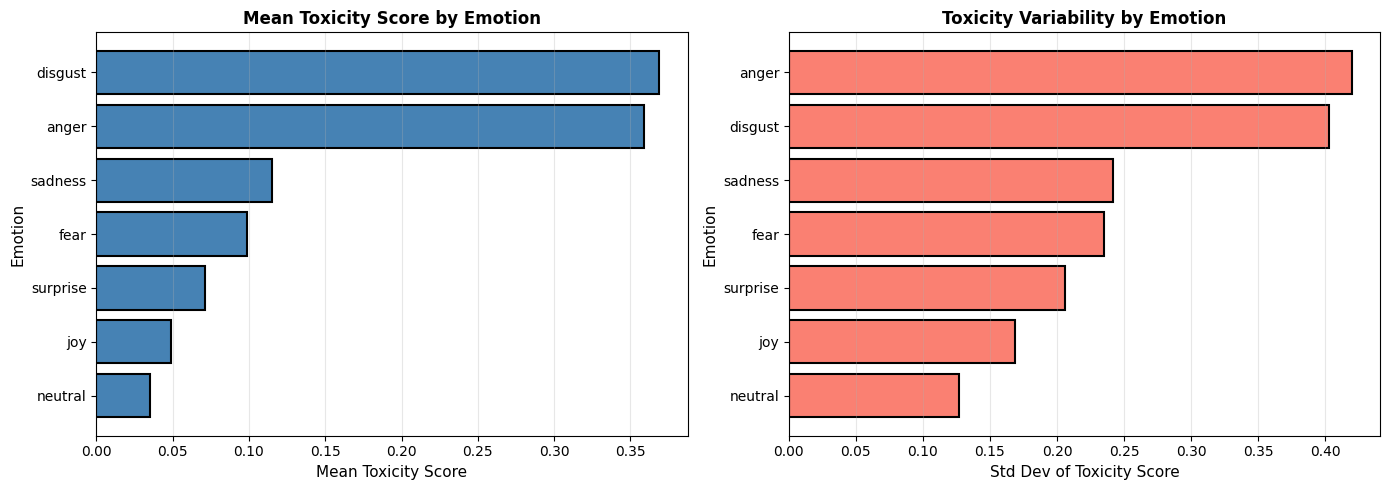

In [60]:
# Analyze relationship between emotions and toxicity
emotion_toxicity = turns_df_full.groupby('emotion').agg({
    'toxicity_score': ['count', 'mean', 'median', 'std']
}).round(3)

emotion_toxicity.columns = ['Turn_Count', 'Mean_Toxicity', 'Median_Toxicity', 'Std_Toxicity']

# Add toxic count and toxic percentage
toxic_counts = []
toxic_pcts = []
for emotion in emotion_toxicity.index:
    emotion_scores = turns_df_full[turns_df_full['emotion'] == emotion]['toxicity_score']
    toxic_count = (emotion_scores >= TOXICITY_THRESHOLD).sum()
    toxic_pct = (toxic_count / len(emotion_scores) * 100)
    toxic_counts.append(toxic_count)
    toxic_pcts.append(toxic_pct)

emotion_toxicity['Toxic_Count'] = toxic_counts
emotion_toxicity['Toxic_%'] = toxic_pcts

# Reorder columns
emotion_toxicity = emotion_toxicity[['Turn_Count', 'Toxic_Count', 'Toxic_%', 'Mean_Toxicity', 'Median_Toxicity', 'Std_Toxicity']]
emotion_toxicity = emotion_toxicity.sort_values('Mean_Toxicity', ascending=False)

print("=== Emotion-Toxicity Analysis ===\n")
print(emotion_toxicity.to_string())

# Visualize - two complementary plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Mean toxicity by emotion
mean_tox = emotion_toxicity['Mean_Toxicity'].sort_values(ascending=True)
axes[0].barh(mean_tox.index, mean_tox.values, color='steelblue', edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Mean Toxicity Score', fontsize=11)
axes[0].set_ylabel('Emotion', fontsize=11)
axes[0].set_title('Mean Toxicity Score by Emotion', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# 2. Standard deviation of toxicity (shows variability/spread)
std_tox = emotion_toxicity['Std_Toxicity'].sort_values(ascending=True)
axes[1].barh(std_tox.index, std_tox.values, color='salmon', edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Std Dev of Toxicity Score', fontsize=11)
axes[1].set_ylabel('Emotion', fontsize=11)
axes[1].set_title('Toxicity Variability by Emotion', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 5.9 Summary and Recommendations

Summarize findings from the brand safety analysis and provide actionable insights for content moderation.

In [61]:
print("=" * 70)
print("BRAND SAFETY ANALYSIS - EXECUTIVE SUMMARY")
print("=" * 70)

total_episodes = len(safety_df)
safe_episodes = safety_df['is_safe'].sum()
unsafe_episodes = total_episodes - safe_episodes
safe_pct = (safe_episodes / total_episodes * 100)

print(f"\n OVERALL METRICS:")
print(f"  • Total episodes analyzed: {total_episodes}")
print(f"  • Safe episodes: {safe_episodes} ({safe_pct:.1f}%)")
print(f"  • Unsafe episodes (flagged for review): {unsafe_episodes} ({100-safe_pct:.1f}%)")

print(f"\n TOXICITY STATISTICS:")
print(f"  • Average toxicity ratio across all episodes: {safety_df['toxicity_ratio'].mean():.3f}")
print(f"  • Median toxicity ratio: {safety_df['toxicity_ratio'].median():.3f}")
print(f"  • Max toxicity score (highest in dataset): {safety_df['max_toxicity'].max():.3f}")
print(f"  • Min toxicity score (lowest in dataset): {safety_df['max_toxicity'].min():.3f}")

print(f"\n CATEGORY INSIGHTS:")
if len(category_safety) > 0:
    safest_category = category_safety['Safe_Pct'].idxmax()
    riskiest_category = category_safety['Safe_Pct'].idxmin()
    safest_pct = category_safety.loc[safest_category, 'Safe_Pct']
    riskiest_pct = category_safety.loc[riskiest_category, 'Safe_Pct']
    
    print(f"  • Safest category: {safest_category} ({safest_pct:.1f}% safe)")
    print(f"  • Highest risk category: {riskiest_category} ({riskiest_pct:.1f}% safe)")

print(f"\n EMOTION-TOXICITY INSIGHTS:")
highest_toxic_emotion = emotion_toxicity['Mean_Toxicity'].idxmax()
lowest_toxic_emotion = emotion_toxicity['Mean_Toxicity'].idxmin()
highest_toxic_score = emotion_toxicity.loc[highest_toxic_emotion, 'Mean_Toxicity']
lowest_toxic_score = emotion_toxicity.loc[lowest_toxic_emotion, 'Mean_Toxicity']

print(f"  • Most toxic emotion: {highest_toxic_emotion} (avg toxicity: {highest_toxic_score:.3f})")
print(f"  • Least toxic emotion: {lowest_toxic_emotion} (avg toxicity: {lowest_toxic_score:.3f})")

#print(f"\n RECOMMENDATIONS:")
#print(f"  1. Prioritize human review for {unsafe_episodes} unsafe episodes")
#print(f"  2. Focus moderation efforts on high-risk categories: {riskiest_category}")
#print(f"  3. Monitor episodes containing {highest_toxic_emotion} for increased safety concerns")
#print(f"  4. Consider automated flagging for episodes exceeding {EPISODE_SAFETY_THRESHOLD*100:.0f}% toxic content threshold")
#print(f"  5. Use toxicity data for brand safety compliance and advertiser alignment")

print("\n" + "=" * 70)


BRAND SAFETY ANALYSIS - EXECUTIVE SUMMARY

 OVERALL METRICS:
  • Total episodes analyzed: 907
  • Safe episodes: 852 (93.9%)
  • Unsafe episodes (flagged for review): 55 (6.1%)

 TOXICITY STATISTICS:
  • Average toxicity ratio across all episodes: 0.037
  • Median toxicity ratio: 0.004
  • Max toxicity score (highest in dataset): 0.999
  • Min toxicity score (lowest in dataset): 0.001

 CATEGORY INSIGHTS:
  • Safest category: business (100.0% safe)
  • Highest risk category: news (69.6% safe)

 EMOTION-TOXICITY INSIGHTS:
  • Most toxic emotion: disgust (avg toxicity: 0.369)
  • Least toxic emotion: neutral (avg toxicity: 0.035)



## 6. Classification Model

### 6.1 Overview
**Objective:**  
The goal of this section is to build and evaluate a classification model that predicts the primary category (`category1`) of a podcast episode based on its transcript text. 

**Approach:**  
- Prepare the training and validation datasets (`train_df_cls`, `val_df_cls`) with episode-level text features and encoded category labels.
- Use a pre-trained `DistilRoBERTa` encoder and a linear classification head to learn the mapping from episode text (`all_text`) to the target category (`y_cat`).
- Evaluate model performance using accuracy and F1-score on the validation set.
- Analyze confusion matrices and per-class results to identify strengths, weaknesses, and potential areas for improvement.

**Expected Output:**  
A trained classification model capable of assigning a primary category to new podcast episodes based on their transcript.

### 6.2 Preprocessing

#### 6.2.1 Concat turn text
This function concatenates all `turnText` fields from a list of speaker turns (dictionaries) into a single string. It is useful for creating a unified episode transcript from individual speaker turns, which can then be used as input for episode-level models or text analysis.

In [135]:
def concat_turn_text(turns):
    if not isinstance(turns, list):
        return ""
    return " ".join(
        (t.get("turnText", "") or "").strip()
        for t in turns
        if isinstance(t, dict) and t.get("turnText") is not None
    ).strip()

def extract_turn_texts(turns):
    if not isinstance(turns, list):
        return []
    out = []
    for t in turns:
        if isinstance(t, dict) and "turnText" in t:
            txt = (t.get("turnText", "") or "").strip()
            if txt:
                out.append(txt)
    return out

#### 6.2.2 Building the category dataset

The `build_category_dataset` function constructs a dataset for episode-level category classification. It selects episodes with non-null turn lists and primary categories, concatenates all turn texts into a single document per episode, and encodes the primary category as the target label. This results in a feature matrix (episode transcripts) and a label vector (categories).

In [136]:
def build_category_dataset(episode_df, top_k=20):
    df = episode_df[["mp3url", "epTitle", "turns_list", "category1"]].dropna(subset=["turns_list", "category1"]).copy()

    top_categories = df["category1"].value_counts().nlargest(top_k).index
    df = df[df["category1"].isin(top_categories)].copy()

    df["all_text"] = df["turns_list"].apply(concat_turn_text)
    df = df[df["all_text"].str.len() > 0].copy()

    le = LabelEncoder()
    df["y_cat"] = le.fit_transform(df["category1"])

    return df.reset_index(drop=True), le

In [137]:
df_cls, le = build_category_dataset(episode_df1, top_k=20)
print(df_cls.shape, df_cls["y_cat"].nunique())

(907, 6) 19


### 6.3 Dataset
This section introduces the episode-level classification dataset used for predicting podcast categories. Each row represents a single episode, including its unique identifier, title, full transcript (as concatenated speaker turns), primary category label, and an integer-encoded target for modeling.

A custom collate function is used to dynamically batch variable-length episode transcripts by performing tokenization, padding, truncation, and alignment of turn-level and episode-level labels into fixed-size tensors suitable for model training.

In [138]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split

class EpisodeTextDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.loc[i]
        return {
            "text": r["all_text"],
            "y": int(r["y_cat"]),
        }

def collate_text(batch, tokenizer, max_len=256):
    texts = [b["text"] for b in batch]
    y = torch.tensor([b["y"] for b in batch], dtype=torch.long)
    enc = tokenizer(texts, padding=True, truncation=True, max_length=max_len, return_tensors="pt")
    return {**enc, "y": y}


### 6.4 Model Architecture

The `EpisodeClassifier` is a PyTorch neural network module designed for episode-level text classification using a pre-trained transformer encoder. The architecture consists of:

- **Encoder**: A transformer model loaded via `AutoModel.from_pretrained`, which converts input token IDs into contextual embeddings.
- **Dropout Layer**: Applied to the pooled `[CLS]` token embedding to prevent overfitting.
- **Classification Head**: A linear layer mapping the encoder's hidden size to the number of target classes.

**Forward Pass**:
- Inputs: `input_ids` and `attention_mask` (from the tokenizer).
- The encoder processes the inputs and outputs hidden states.
- The `[CLS]` token embedding (first token) is extracted and passed through dropout.
- The classification head produces logits for each class.


In [144]:
class EpisodeClassifier(nn.Module):
    def __init__(self, encoder_name, num_classes, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        H = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(H, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]          # CLS token
        cls = self.dropout(cls)
        logits = self.head(cls)
        return logits


### 6.5 Model Training

In [146]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
def train_episode_classifier(
    df_cls,
    le,
    encoder_name="distilroberta-base",
    max_len=256,
    batch_size=4,
    grad_accum_steps=4,
    epochs=3,
    lr=2e-5,
):
    # device: cuda / mps / cpu
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")

    df = df_cls.copy()

    # remove classes with <2 samples (stratify safety)
    counts = df["y_cat"].value_counts()
    df = df[df["y_cat"].isin(counts[counts >= 2].index)].copy()

    train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["y_cat"], random_state=42)

    tokenizer = AutoTokenizer.from_pretrained(encoder_name)
    num_classes = int(df["y_cat"].nunique())

    model = EpisodeClassifier(encoder_name, num_classes).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    train_loader = DataLoader(
        EpisodeTextDataset(train_df),
        batch_size=batch_size,
        shuffle=True,
        collate_fn=lambda b: collate_text(b, tokenizer, max_len=max_len),
    )
    val_loader = DataLoader(
        EpisodeTextDataset(val_df),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=lambda b: collate_text(b, tokenizer, max_len=max_len),
    )

    def eval_model():
        model.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                y = batch["y"].to(device)

                logits = model(input_ids, attention_mask)
                pred = logits.argmax(dim=-1)

                y_true.extend(y.cpu().numpy().tolist())
                y_pred.extend(pred.cpu().numpy().tolist())

        
        
        y_true = np.asarray(y_true, dtype=int)
        y_pred = np.asarray(y_pred, dtype=int)
        
        acc = accuracy_score(y_true,y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro',  zero_division=0)
        return acc, f1

    for epoch in range(1, epochs + 1):
        model.train()
        opt.zero_grad()
        total_loss = 0.0
        step = 0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            y = batch["y"].to(device)

            logits = model(input_ids, attention_mask)
            loss = loss_fn(logits, y) / grad_accum_steps
            loss.backward()

            total_loss += float(loss.item())
            step += 1

            if step % grad_accum_steps == 0:
                opt.step()
                opt.zero_grad()

        # finish leftover grads
        if step % grad_accum_steps != 0:
            opt.step()
            opt.zero_grad()

        acc, f1 = eval_model()
        print(f"Epoch {epoch}/{epochs} | train_loss={total_loss/max(1,step):.4f} | val_acc={acc:.3f} val_macro_f1={f1:.3f}")

        if torch.backends.mps.is_available():
            torch.mps.empty_cache()

    return model, tokenizer, device, train_df, val_df

model_cls, tok_cls, device_cls, train_df_cls, val_df_cls = train_episode_classifier(
    df_cls,
    le,
    encoder_name="distilroberta-base",
    max_len=128,
    batch_size=4,          # MPS-safe
    grad_accum_steps=8,    # effective batch ~16
    epochs=10,
    lr=2e-5,
)

/opt/miniconda3/envs/nlp/lib/python3.12/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Epoch 1/10 | train_loss=0.3122 | val_acc=0.176 val_macro_f1=0.017
Epoch 2/10 | train_loss=0.2707 | val_acc=0.357 val_macro_f1=0.089
Epoch 3/10 | train_loss=0.2103 | val_acc=0.555 val_macro_f1=0.258
Epoch 4/10 | train_loss=0.1495 | val_acc=0.637 val_macro_f1=0.324
Epoch 5/10 | train_loss=0.1102 | val_acc=0.687 val_macro_f1=0.383
Epoch 6/10 | train_loss=0.0842 | val_acc=0.692 val_macro_f1=0.404
Epoch 7/10 | train_loss=0.0630 | val_acc=0.747 val_macro_f1=0.478
Epoch 8/10 | train_loss=0.0456 | val_acc=0.758 val_macro_f1=0.541
Epoch 9/10 | train_loss=0.0303 | val_acc=0.780 val_macro_f1=0.561
Epoch 10/10 | train_loss=0.0198 | val_acc=0.764 val_macro_f1=0.545


### 6.6 Model Results

In [157]:
@torch.no_grad()
def predict_episode_categories(model, tokenizer, df_some, le, device, max_len=256):
    model.eval()
    texts = df_some["all_text"].astype(str).tolist()
    enc = tokenizer(texts, padding=True, truncation=True, max_length=max_len, return_tensors="pt")
    enc = {k: v.to(device) for k, v in enc.items()}
    logits = model(enc["input_ids"], enc["attention_mask"])
    probs = torch.softmax(logits, dim=-1).cpu().numpy()
    pred = probs.argmax(axis=1)
    pred_label = le.inverse_transform(pred)
    return pred_label, probs.max(axis=1)

sample = val_df_cls.sample(5, random_state=0).reset_index(drop=True)
pred_label, pred_conf = predict_episode_categories(model_cls, tok_cls, sample, le, device_cls)

print("-" * 60)
for i, row in sample.iterrows():
    print(f"\nTitle: {row['epTitle']}")
    print(f"True Category: {row['category1']}")
    print(f"Predicted Category: {pred_label[i]} (Confidence: {pred_conf[i]:.3f})\n")
    print("-" * 60)


------------------------------------------------------------

Title: Episode 34: How Will Concerts Return Post-Pandemic?
True Category: leisure
Predicted Category: leisure (Confidence: 0.926)

------------------------------------------------------------

Title: Young & Christian with Pastor Jospeh Manaway 
True Category: education
Predicted Category: religion (Confidence: 0.899)

------------------------------------------------------------

Title: 075: How To 2.5X Your Revenue In 6 Months
True Category: business
Predicted Category: business (Confidence: 0.915)

------------------------------------------------------------

Title: The “Blood in the Water” Mentality
True Category: education
Predicted Category: health (Confidence: 0.654)

------------------------------------------------------------

Title: Ep6: Planet Puffin - Netting Puffins
True Category: education
Predicted Category: education (Confidence: 0.903)

------------------------------------------------------------


## 7. Multi-task model
This section will explore the development of a multi-task learning model that jointly predicts the primary category, the brand safety (toxicity) label for each podcast episode and the emotion per turn. By leveraging shared representations from episode transcripts, the model aims to improve performance on classification compared to training a single task model.

### 7.1 Overview
### Objective
Develop a multi-task learning model that simultaneously predicts:
- The primary category of each podcast episode
- The brand safety (toxicity) label for each episode
- The dominant emotion for each speaker turn

**Approach:**
- **Shared Representation:** Use a shared encoder `distilbert-base-uncased`.
- **Task-specific Heads:** Attach separate output layers for category classification, toxicity detection, and emotion prediction.
- **Joint Training:** Train the model end-to-end using a combined loss function that balances all three tasks.
- **Evaluation:** Assess performance on each task individually and compare to single-task baselines.

**Expected Output:**
- A trained multi-task model capable of predicting episode category, safety label, and turn-level emotion in a single forward pass.
- Performance metrics for each task and analysis of task interdependencies.
- Insights into how multi-task learning improves (or affects) results compared to single task classification model.

### 7.2 Preprocessing



#### 7.2.1 Add Episode Toxicity from Turn Cache

The `add_episode_toxicity_from_turn_cache` function aggregates turn-level toxicity scores (previously computed and cached by the single task model) to the episode level. 
These aggregated episode-level toxicity metrics are used as pseudo labels for the multi-task model. By leveraging toxicity scores computed from a separate, pretrained toxicity detector, we can provide supervision for the brand safety prediction task without requiring manual annotation. This approach enables the model to learn to predict episode safety directly from transcript content, using the cached toxicity statistics as ground-truth targets during training.

In [64]:
import os
import pandas as pd

def add_episode_toxicity_from_turn_cache(
    df_cat,
    turn_cache_path="data/toxicity_cache/toxicity_scores.csv",
    agg="max",   # "max" or "mean"
    col_out="y_tox",
):
    if not os.path.exists(turn_cache_path):
        raise FileNotFoundError(f"Turn-level toxicity cache not found: {turn_cache_path}")

    turn_df = pd.read_csv(turn_cache_path)

    # sanity
    required = {"mp3url", "epTitle", "toxicity_score"}
    missing = required - set(turn_df.columns)
    if missing:
        raise ValueError(f"Cache missing columns {missing}. Found: {turn_df.columns.tolist()}")

    if agg == "max":
        ep = turn_df.groupby(["mp3url","epTitle"], as_index=False)["toxicity_score"].max()
    elif agg == "mean":
        ep = turn_df.groupby(["mp3url","epTitle"], as_index=False)["toxicity_score"].mean()
    else:
        raise ValueError("agg must be 'max' or 'mean'")

    ep = ep.rename(columns={"toxicity_score": col_out})

    out = df_cat.merge(ep, on=["mp3url","epTitle"], how="left")

    if out[col_out].isna().any():
        n = int(out[col_out].isna().sum())
        print(f"Warning: {n} episodes in df_cat had no match in toxicity cache (missing {col_out}).")

    return out


#### 7.2.2 Compute Emotion Soft Labels from Cache

The `compute_emotion_soft_labels_from_cache` function aggregates turn-level emotion predictions (previously computed and cached) to produce episode-level "soft labels" for emotion. Instead of assigning a single dominant emotion per episode, it calculates the proportion (distribution) of each emotion across all turns in an episode. These soft labels represent the probability distribution of emotions and are useful for training models with richer supervision, enabling the model to learn from the full emotional landscape of each episode rather than just a single label. This approach supports multi-label or distributional learning objectives in multi-task models.


In [65]:
def compute_emotion_soft_labels_from_cache(df_cat, emotions_csv_path):
    emo_labels = ['anger','disgust','fear','joy','neutral','sadness','surprise']
    prob_cols = [f"{e}_prob" for e in emo_labels]

    emo_df = pd.read_csv(emotions_csv_path)
    emo_df = emo_df.sort_values(["mp3url","epTitle","startTime"], kind="stable")

    emo_by_ep = (
        emo_df.groupby(["mp3url","epTitle"])
        .apply(lambda g: pd.Series({
            "turns_texts": g["turnText"].astype(str).tolist(),
            "y_emo": g[prob_cols].to_numpy(dtype=np.float32)
        }))
        .reset_index()
    )

    df_cat = df_cat.merge(
        emo_by_ep,
        on=["mp3url","epTitle"],
        how="left"
    )

    return df_cat, emo_labels


### 7.3 Dataset

The multi-task dataset is constructed at the episode level, where each row represents a single podcast episode. For each episode, the dataset includes:

- **Episode Metadata:** Unique identifiers (`mp3url`, `epTitle`) and primary category (`category1`).
- **Transcript Features:** The full episode transcript, created by concatenating all `turnText` fields from the episode's speaker turns.
- **Category Label:** The encoded primary category (`y_cat`), used for episode-level category classification.
- **Toxicity Label:** An aggregated toxicity score (`y_tox`), computed from turn-level toxicity predictions (e.g., maximum or mean toxicity across all turns), used for brand safety prediction.
- **Emotion Soft Labels:** A matrix of emotion probabilities (`y_emo`), representing the distribution of emotions across all turns in the episode, used for emotion prediction.



In [66]:
from torch.utils.data import Dataset


class EpisodeTurnDataset(Dataset):
    def __init__(self, df, use_emotion=False):
        self.df = df.reset_index(drop=True)
        self.use_emotion = use_emotion

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.loc[i]
        item = {
            "mp3url": row["mp3url"],
            "epTitle": row["epTitle"],
            "turns": row["turns_list"],
            "y_cat": int(row["y_cat"]),
            "y_tox": float(row["y_tox"]),
        }
        if self.use_emotion:
            item["turns_texts"] = row["turns_texts"]
            item["y_emo"] = row["y_emo"]  # numpy [T,E]
        return item

def collate_episode_turns(batch, tokenizer, max_len=64, use_emotion=True, max_turns=64, window_mode="random"):
    """
    window_mode: "random" | "first" | "last"
    """
    assert use_emotion, "This collate is intended for use_emotion=True"

    B = len(batch)
    E = batch[0]["y_emo"].shape[1]  # number of emotions

    turns_texts = []
    y_emo_list = []
    turn_counts = []

    for b in batch:
        texts = b["turns_texts"]
        y_emo = b["y_emo"]  # numpy array [T,E]

        T0 = len(texts)
        assert y_emo.shape[0] == T0, f"Mismatch: turns_texts len={T0} vs y_emo.shape[0]={y_emo.shape[0]}"

        # choose window
        if T0 > max_turns:
            if window_mode == "random":
                start = np.random.randint(0, T0 - max_turns + 1)
            elif window_mode == "first":
                start = 0
            elif window_mode == "last":
                start = T0 - max_turns
            else:
                raise ValueError("window_mode must be 'random', 'first', or 'last'")

            end = start + max_turns
            texts = texts[start:end]
            y_emo = y_emo[start:end, :]
        # else keep as-is

        turns_texts.append(texts)
        y_emo_list.append(y_emo)
        turn_counts.append(len(texts))

    T = max(turn_counts) if B > 0 else 0
    turn_mask = torch.zeros(B, T, dtype=torch.bool)

    # pad texts to [B,T]
    padded_texts = []
    for i, texts in enumerate(turns_texts):
        turn_mask[i, :len(texts)] = True
        padded_texts.append(texts + [""] * (T - len(texts)))

    flat = [t for ep in padded_texts for t in ep]  # B*T

    enc = tokenizer(
        flat, padding=True, truncation=True, max_length=max_len, return_tensors="pt"
    )
    L = enc["input_ids"].shape[1]
    input_ids = enc["input_ids"].view(B, T, L)
    attention_mask = enc["attention_mask"].view(B, T, L)

    # targets
    y_cat = torch.tensor([b["y_cat"] for b in batch], dtype=torch.long)
    y_tox = torch.tensor([b["y_tox"] for b in batch], dtype=torch.float32)

    # pad y_emo to [B,T,E]
    y_emo_pad = torch.zeros(B, T, E, dtype=torch.float32)
    for i, arr in enumerate(y_emo_list):
        if arr.shape[0] > 0:
            y_emo_pad[i, :arr.shape[0], :] = torch.tensor(arr, dtype=torch.float32)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "turn_mask": turn_mask,
        "y_cat": y_cat,
        "y_tox": y_tox,
        "y_emo": y_emo_pad,
    }

In [143]:
df_cat, le = build_category_dataset(episode_df1, top_k=20)
df_cat = add_episode_toxicity_from_turn_cache(
    df_cat,
    turn_cache_path="data/toxicity_cache/toxicity_scores.csv",
    agg="max",        # max over turns is usually a good “brand safety” proxy
    col_out="y_tox"
)
df_cat, emo_labels = compute_emotion_soft_labels_from_cache(
    df_cat,
    emotions_csv_path="data/emotion_cache/emotion_predictions.csv"
)

df_cat.head(20)

/var/folders/qv/8ghds0hx12s2tw7v8qcq17580000gn/T/ipykernel_56268/653770809.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,mp3url,epTitle,turns_list,category1,all_text,y_cat,y_tox,turns_texts,y_emo
0,https://www.buzzsprout.com/783020/4252475-best...,Best of SingOut SpeakOut No.3,"[{'speaker': '['SPEAKER_00']', 'turnText': 'im...",music,im simon shapiro sing speak give philosophies ...,10,0.014334,[im simon shapiro sing speak give philosophies...,"[[0.013648478, 0.0002000313, 0.9580909, 0.0090..."
1,https://www.buzzsprout.com/783020/3983942-toda...,Today Is Yesterday,"[{'speaker': '['SPEAKER_05']', 'turnText': 'im...",music,im simon shapiro sing speak give philosophies ...,10,0.269658,[im simon shapiro sing speak give philosophies...,"[[0.016969467, 0.00022080357, 0.8845618, 0.047..."
2,https://www.buzzsprout.com/783020/3892169-satu...,Saturn Return,"[{'speaker': '['SPEAKER_03']', 'turnText': 'im...",music,im simon shapiro sing speak give philosophies ...,10,0.099276,[im simon shapiro sing speak give philosophies...,"[[0.016969467, 0.00022080357, 0.8845618, 0.047..."
3,https://www.buzzsprout.com/783020/3791501-quar...,Quarterlife Crisis,"[{'speaker': '['SPEAKER_00']', 'turnText': 'im...",music,im simon shapiro sing speak give philosophies ...,10,0.006672,[im simon shapiro sing speak give philosophies...,"[[0.016969467, 0.00022080357, 0.8845618, 0.047..."
4,http://dts.podtrac.com/redirect.mp3/feeds.soun...,Episode 33 'California’s Higher Education Lan...,"[{'speaker': '['SPEAKER_00']', 'turnText': 'hi...",education,hi eli ortiz oakley chancellor california comm...,3,0.008847,[hi eli ortiz oakley chancellor california com...,"[[0.015789563, 0.00045122037, 0.0044175447, 0...."
5,https://traffic.libsyn.com/secure/glassboxpodc...,Ep 46 - Broken Missionary plus Case for Book o...,"[{'speaker': '['SPEAKER_04']', 'turnText': 'co...",religion,confirmation bias treasured enemy opinions acu...,12,0.990994,[confirmation bias treasured enemy opinions ac...,"[[0.33247572, 0.015229115, 0.18149365, 0.03144..."
6,https://traffic.megaphone.fm/APO1966610268.mp3,Opioid Addictions- It Can Happen To Anyone,"[{'speaker': '['SPEAKER_00']', 'turnText': 'hi...",health,hi welcome get fit radio show host irene cook ...,6,0.188027,[hi welcome get fit radio show host irene cook...,"[[0.0020427615, 0.00048173466, 0.00029462008, ..."
7,https://traffic.megaphone.fm/APO9003433456.mp3,Why Diets Fail- Trust the Process,"[{'speaker': '['SPEAKER_00']', 'turnText': 'pl...",health,playing hi welcome get fit radio radio show ke...,6,0.092208,[playing hi welcome get fit radio radio show k...,"[[0.23757328, 0.010206812, 0.0035307673, 0.129..."
8,https://traffic.megaphone.fm/APO2000908093.mp3,Summer Fitness Hacks To Stay Fit,"[{'speaker': '['SPEAKER_02']', 'turnText': 'ic...",health,ic playing hi welcome get fit radio show host ...,6,0.281961,[ic playing hi welcome get fit radio show host...,"[[0.0051974924, 0.0006507122, 0.008851377, 0.7..."
9,https://traffic.megaphone.fm/APO8920212301.mp3,Intermittent Fasting - Yay or Nay?,"[{'speaker': '['SPEAKER_02']', 'turnText': 'go...",health,go matter live lets go hi welcome get fit radi...,6,0.158350,"[go matter live lets go hi, welcome get fit ra...","[[0.016272184, 0.00312751, 0.0031019435, 0.435..."


### 7.4 Model Architecture

The multi-task model is designed to jointly predict three targets for each podcast episode:

1. **Primary Category** (episode-level, multi-class classification)
2. **Brand Safety (Toxicity)** (episode-level, regression or binary classification)
3. **Turn-Level Emotion** (sequence-level, multi-class or distributional prediction per turn)

**Architecture Overview:**

- **Shared Encoder:**  
    The model uses a shared transformer encoder (`DistilBERT`) to process the episode transcript or turn texts. This encoder learns a common representation that captures the semantic and contextual information of the episode.

- **Task-Specific Heads:**  
    After the shared encoder, the model branches into separate heads for each task:
    - **Category Head:** A classification layer that predicts the primary category (`y_cat`) for the episode.
    - **Toxicity Head:** A regression or classification layer that predicts the aggregated toxicity score (`y_tox`) for the episode.
    - **Emotion Head:** A sequence classifier or regressor that predicts the emotion distribution (`y_emo`) for each turn in the episode.

In [68]:
import torch
from transformers import AutoModel
import torch.nn as nn

class MultiTaskEpisodeModel(nn.Module):
    def __init__(self, encoder_name, num_categories=20, num_emotions=7, dropout=0.1, use_emotion=False):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        H = self.encoder.config.hidden_size
        self.use_emotion = use_emotion
        self.dropout = nn.Dropout(dropout)

        # turn-level emotion logits (optional)
        if use_emotion:
            self.emotion_head = nn.Sequential(
                nn.Linear(H, H), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(H, num_emotions)
            )

        # episode-level heads
        self.category_head = nn.Sequential(
            nn.Linear(H, H), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(H, num_categories)
        )
        self.tox_head = nn.Sequential(
            nn.Linear(H, H), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(H, 1)  # regression
        )

    def forward(self, input_ids, attention_mask, turn_mask=None):
        """
        input_ids: [B,T,L]
        attention_mask: [B,T,L]
        turn_mask: [B,T]
        """
        B, T, L = input_ids.shape
        flat_ids = input_ids.view(B*T, L)
        flat_am  = attention_mask.view(B*T, L)

        out = self.encoder(input_ids=flat_ids, attention_mask=flat_am)
        turn_emb = out.last_hidden_state[:, 0, :]           # [B*T,H]
        turn_emb = self.dropout(turn_emb).view(B, T, -1)    # [B,T,H]

        emo_logits = None
        if self.use_emotion:
            emo_logits = self.emotion_head(turn_emb)        # [B,T,E]

        # masked mean pooling over turns for episode embedding
        if turn_mask is None:
            ep_emb = turn_emb.mean(dim=1)
        else:
            w = turn_mask.float().unsqueeze(-1)
            ep_emb = (turn_emb * w).sum(dim=1) / w.sum(dim=1).clamp_min(1.0)

        ep_emb = self.dropout(ep_emb)
        cat_logits = self.category_head(ep_emb)             # [B,C]
        tox_pred = self.tox_head(ep_emb).squeeze(-1)        # [B]

        return emo_logits, cat_logits, tox_pred


### 7.5 Loss Functions

The multi-task model jointly optimizes three loss functions, one for each prediction task:

1. **Category Loss (`L_cat`)**  
    - **Type:** Cross-Entropy Loss  
    - **Purpose:** Measures how well the model predicts the correct primary category for each episode.  

2. **Toxicity Loss (`L_tox`)**  
    - **Type:** Mean Squared Error (MSE) Loss  
    - **Purpose:** Measures the error between the predicted and true episode-level toxicity scores.  

3. **Emotion Loss (`L_emo`)**  
    - **Type:** Kullback-Leibler (KL) Divergence or Cross-Entropy Loss  
    - **Purpose:** Measures the difference between the predicted emotion distribution and the true (soft) emotion distribution for each turn.  

**Total Loss:**  
The overall loss is a weighted sum of the all the individual losses.

In [69]:
def multitask_losses(emo_logits, cat_logits, tox_pred, batch, use_emotion=False, emo_weight=1.0, cat_weight=1.0, tox_weight=1.0):
    # category
    loss_cat = nn.CrossEntropyLoss()(cat_logits, batch["y_cat"])

    # toxicity regression target in [0,1]
    loss_tox = nn.MSELoss()(tox_pred, batch["y_tox"])

    loss_emo = torch.tensor(0.0, device=cat_logits.device)
    if use_emotion and emo_logits is not None:
        # teacher probs: y_emo [B,T,E], mask padded turns
        teacher = batch["y_emo"].to(emo_logits.device)                      # probs
        mask = batch["turn_mask"].to(emo_logits.device).float().unsqueeze(-1)

        student_logp = torch.log_softmax(emo_logits, dim=-1)                # log probs
        # KL(teacher || student): sum teacher * (log teacher - log student)
        kl = teacher * (torch.log(teacher.clamp_min(1e-8)) - student_logp)
        kl = (kl * mask).sum() / mask.sum().clamp_min(1.0)
        loss_emo = kl

    total = cat_weight*loss_cat + tox_weight*loss_tox + emo_weight*loss_emo
    return total, {"cat": loss_cat.detach(), "tox": loss_tox.detach(), "emo": loss_emo.detach()}


### 7.6 Model training


In [ ]:
# Import required libraries for metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, mean_absolute_error,  f1_score
import numpy as np

def metrics(y_true_cat, cat_logits, y_true_tox, y_pred_tox, y_true_emo, y_pred_emo_logits, cat_weight=1, tox_weight=1, emo_weight=1):
    cat_logits = cat_logits.detach().cpu().numpy()
    y_pred_emo_logits = y_pred_emo_logits.detach().cpu().numpy()
    y_true_cat = y_true_cat.detach().cpu().numpy()
    y_true_tox = y_true_tox.detach().cpu().numpy()
    y_pred_tox = y_pred_tox.detach().cpu().numpy()
    y_true_emo = y_true_emo.detach().cpu().numpy()

    y_pred_cat = np.argmax(cat_logits, axis=-1)
    y_pred_emo = (y_pred_emo_logits > 0.5).astype(int)  # threshold for multi-label

    # 1. Category metrics
    cat_acc = accuracy_score(y_true_cat, y_pred_cat)
    cat_prec, cat_rec, cat_f1, _ = precision_recall_fscore_support(y_true_cat, y_pred_cat, average='macro',  zero_division=0)

    # 2. Toxicity metrics
    tox_mae = mean_absolute_error(y_true_tox, y_pred_tox)

    # 3. Emotions metrics
    y_true_emo = y_true_emo.reshape(-1, y_true_emo.shape[-1])
    y_pred_emo = y_pred_emo.reshape(-1, y_pred_emo.shape[-1])


    # Convert to numpy arrays
    y_true_emo = (y_true_emo > 0).astype(int)
    y_pred_emo = (y_pred_emo > 0.5).astype(int)  # Use 0.5 threshold for sigmoid outputs

    emo_f1_macro = f1_score(y_true_emo, y_pred_emo, average='macro', zero_division=0)


    # 4. Overall score
    norm_tox_mae = min(tox_mae / 1, 1)
    total = cat_weight + tox_weight + emo_weight
    cat_weight /= total
    tox_weight /= total
    emo_weight /= total
    all_score = cat_weight * cat_f1 + tox_weight * (1 - norm_tox_mae) + emo_weight * emo_f1_macro

    return cat_acc, cat_f1, tox_mae, emo_f1_macro, all_score


In [133]:
def eval_epoch(model,val_loader,use_emotion):
        model.eval()
        cat_accs,cat_f1s, tox_maes, emo_f1_macros, all_scores = [], [], [], [], []
        with torch.no_grad():
            for batch in val_loader:
                for k in ["input_ids","attention_mask","turn_mask","y_cat","y_tox"]:
                    batch[k] = batch[k].to(device)
                if use_emotion:
                    batch["y_emo"] = batch["y_emo"].to(device)

                emo_logits, cat_logits, tox_pred = model(batch["input_ids"], batch["attention_mask"], batch["turn_mask"])
                cat_acc, cat_f1, tox_mae, emo_f1_macro, all_score = metrics(
                    batch["y_cat"], cat_logits, batch["y_tox"], tox_pred, batch["y_emo"], emo_logits, cat_weight, tox_weight, emo_weight
                )
                cat_accs.append(cat_acc)
                cat_f1s.append(cat_f1)
                tox_maes.append(tox_mae)
                emo_f1_macros.append(emo_f1_macro)
                all_scores.append(all_score)

        avg_cat_acc = np.mean(cat_accs) if cat_accs else 0
        avg_cat_f1 = np.mean(cat_f1s) if cat_f1s else 0
        avg_tox_mae = np.mean(tox_maes) if tox_maes else 0
        avg_emo_f1_macro = np.mean(emo_f1_macros) if emo_f1_macros else 0
        avg_all_score = np.mean(all_scores) if all_scores else 0

        return avg_cat_acc, avg_cat_f1, avg_tox_mae, avg_emo_f1_macro, avg_all_score


In [134]:
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
import torch
import numpy as np
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

if torch.backends.mps.is_available():
    torch.mps.empty_cache()

# -------------------------------
# Data Preparation and Model Setup
# -------------------------------
df = df_cat
use_emotion=True
encoder_name="distilroberta-base"
max_len=128
epochs=10
batch_size=4
lr=2e-5
max_len = 64
max_turns = 32          
window_mode = "random"
best_score = -np.inf
patience = 3
patience_counter = 0
best_model_state = None
cat_weight,tox_weight = 1, 1
emo_weight = 1 if use_emotion else 0

num_categories = len(le.classes_)
num_emotions = len(emo_labels) if (use_emotion and emo_labels is not None) else 0

model = MultiTaskEpisodeModel(
    encoder_name=encoder_name,
    num_categories=num_categories,
    num_emotions=num_emotions,
    use_emotion=use_emotion,
).to(device)

tokenizer = AutoTokenizer.from_pretrained(encoder_name)

counts = df["y_cat"].value_counts()
valid_classes = counts[counts >= 2].index

df = df[df["y_cat"].isin(valid_classes)].copy()


train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["y_cat"], random_state=42)

train_ds = EpisodeTurnDataset(train_df, use_emotion=use_emotion)
val_ds   = EpisodeTurnDataset(val_df, use_emotion=use_emotion)


collate = lambda b: collate_episode_turns(
    b, tokenizer,
    max_len=max_len,
    use_emotion=True,
    max_turns=max_turns,
    window_mode=window_mode
)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate)

optim = torch.optim.AdamW(model.parameters(), lr=lr)

# -------------------------------
# Training
# -------------------------------
print('Starting Multi-task Model training')
print('----------------------------------')
print(f"Parameters used:")
print(f"  epochs: {epochs}")
print(f"  batch_size: {batch_size}")
print(f"  lr: {lr}")
print(f"  patience: {patience}")
print(f"  encoder_name: {encoder_name}")
print(f"  use_emotion: {use_emotion}")
print(f"  emo_labels: {emo_labels}")
print(f"  max_len: {max_len}")
print(f"  num_categories: {num_categories}")
print(f"  num_emotions: {num_emotions}")
print(f"  train_df shape: {train_df.shape}")
print(f"  val_df shape: {val_df.shape}")
print('----------------------------------')

for epoch in range(1, epochs+1):
    model.train()
    running = {"cat": 0.0, "tox": 0.0, "emo": 0.0, "total": 0.0}
    n = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
    for batch in progress_bar:
        for k in ["input_ids","attention_mask","turn_mask","y_cat","y_tox"]:
            batch[k] = batch[k].to(device)
        if use_emotion:
            batch["y_emo"] = batch["y_emo"].to(device)

        optim.zero_grad()
        emo_logits, cat_logits, tox_pred = model(batch["input_ids"], batch["attention_mask"], batch["turn_mask"])
        # Compute losses
        loss, parts = multitask_losses(emo_logits, cat_logits, tox_pred, batch, use_emotion=use_emotion,
                                        emo_weight=emo_weight if use_emotion else 0.0, cat_weight=cat_weight, tox_weight=tox_weight)
        loss.backward()
        optim.step()

        running["total"] += loss.item()
        running["cat"] += parts["cat"].item()
        running["tox"] += parts["tox"].item()
        running["emo"] += parts["emo"].item()
        n += 1

        progress_bar.set_postfix({"loss": loss.item()})

    # Evaluation
    avg_cat_acc, avg_cat_f1, avg_tox_mae, avg_emo_f1_macro, avg_all_score = eval_epoch(model,val_loader,use_emotion)
    
    print(
        f"Epoch {epoch}/{epochs} \n"
        f"Losses  | "
        f"Total={running['total']/n:.4f} | Category={running['cat']/n:.4f} | Toxicity={running['tox']/n:.4f} | Emotion={running['emo']/n:.4f} \n"
        f'Metrics | '
        f"Category Accuracy (AVG)={avg_cat_acc:.3f} | "
        f"Category F1 score (AVG)={avg_cat_f1:.3f} | "
        f"Toxicity MAE (AVG)={avg_tox_mae:.4f} | "
        f"Emotion F1 score (AVG)={avg_emo_f1_macro:.3f} | "
        f"Overall Score={avg_all_score:.4f}"
    )
    
    # Patience
    if avg_all_score > best_score:
        best_score = avg_all_score
        patience_counter = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        print(f"Early stopping patience {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            if best_model_state is not None:
                model.load_state_dict(best_model_state)
            break

    if torch.backends.mps.is_available():
        torch.mps.empty_cache()


ckpt = {
    "model_state": model.state_dict(),
    "encoder_name": encoder_name,
    "label_classes": le.classes_.tolist(),
    "use_emotion": True,
    "emo_labels": emo_labels if emo_labels is not None else None,
}

torch.save(ckpt, "data/models/multitask_episode_model.pt")


/opt/miniconda3/envs/nlp/lib/python3.12/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Starting Multi-task Model training
----------------------------------
Parameters used:
  epochs: 10
  batch_size: 4
  lr: 2e-05
  patience: 3
  encoder_name: distilroberta-base
  use_emotion: True
  emo_labels: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
  max_len: 64
  num_categories: 19
  num_emotions: 7
  train_df shape: (724, 9)
  val_df shape: (182, 9)
----------------------------------


Epoch 1/10:   0%|          | 0/181 [00:00<?, ?it/s]

Epoch 1/10 
Losses  | Total=3.3646 | Category=2.4809 | Toxicity=0.1145 | Emotion=0.7692 
Metrics | Category Accuracy (AVG)=0.370 | Category F1 score (AVG)=0.258 | Toxicity MAE (AVG)=0.2570 | Emotion F1 score (AVG)=0.301 | Overall Score=0.4342


Epoch 2/10:   0%|          | 0/181 [00:00<?, ?it/s]

...

Epoch 8/10 
Losses  | Total=1.3078 | Category=0.9472 | Toxicity=0.0582 | Emotion=0.3024 
Metrics | Category Accuracy (AVG)=0.641 | Category F1 score (AVG)=0.534 | Toxicity MAE (AVG)=0.2066 | Emotion F1 score (AVG)=0.407 | Overall Score=0.5783
Early stopping patience 1/3


Epoch 9/10:   0%|          | 0/181 [00:00<?, ?it/s]

Epoch 9/10 
Losses  | Total=1.1852 | Category=0.8526 | Toxicity=0.0471 | Emotion=0.2856 
Metrics | Category Accuracy (AVG)=0.658 | Category F1 score (AVG)=0.554 | Toxicity MAE (AVG)=0.2084 | Emotion F1 score (AVG)=0.414 | Overall Score=0.5867


Epoch 10/10:   0%|          | 0/181 [00:00<?, ?it/s]

Epoch 10/10 
Losses  | Total=1.1003 | Category=0.7814 | Toxicity=0.0457 | Emotion=0.2733 
Metrics | Category Accuracy (AVG)=0.685 | Category F1 score (AVG)=0.588 | Toxicity MAE (AVG)=0.1977 | Emotion F1 score (AVG)=0.425 | Overall Score=0.6051


### 7.7 Model Results

The multi-task model jointly predicts episode category, brand safety (toxicity), and turn-level emotion. 

In [ ]:
import numpy as np
import pandas as pd
import torch

@torch.no_grad()
def predict_episodes(model, df_eval, tokenizer, device, emo_labels, le,
                    max_len=64, max_turns=64, window_mode="first", batch_size=1):
    """
    window_mode:
      - "first" for deterministic testing
      - "random" to sample a random window
      - "last" for last window
    """
    model.eval()

    # dataset/loader
    ds = EpisodeTurnDataset(df_eval, use_emotion=True)
    collate = lambda b: collate_episode_turns(
        b, tokenizer, max_len=max_len, use_emotion=True, max_turns=max_turns, window_mode=window_mode
    )
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=collate)

    rows = []
    for batch in loader:
        for k in ["input_ids","attention_mask","turn_mask","y_cat","y_tox","y_emo"]:
            batch[k] = batch[k].to(device)

        emo_logits, cat_logits, tox_pred = model(batch["input_ids"], batch["attention_mask"], batch["turn_mask"])

        cat_probs = torch.softmax(cat_logits, dim=-1).cpu().numpy()
        cat_pred_idx = cat_probs.argmax(axis=1)
        cat_pred_prob = cat_probs.max(axis=1)

        tox_pred = tox_pred.cpu().numpy()

        # emotion (window-level)
        emo_probs = torch.softmax(emo_logits, dim=-1).cpu().numpy()  # [B,T,E]
        emo_top = emo_probs.argmax(axis=-1)                          # [B,T]

        # build output rows per episode
        B = cat_pred_idx.shape[0]
        for i in range(B):
            # episode keys aren't in batch; grab from df_eval in order (since shuffle=False, batch_size small)
            # easiest: use df_eval.reset_index and index by running counter
            rows.append({
                "pred_category_id": int(cat_pred_idx[i]),
                "pred_category": le.inverse_transform([int(cat_pred_idx[i])])[0] if hasattr(le, "inverse_transform") else int(cat_pred_idx[i]),
                "pred_category_prob": float(cat_pred_prob[i]),
                "pred_episode_toxicity": float(tox_pred[i]),
                "window_turns": int(batch["turn_mask"][i].sum().item()),
                "window_emotion_sequence": [emo_labels[j] for j in emo_top[i, :int(batch["turn_mask"][i].sum().item())]],
            })

    return pd.DataFrame(rows)

#### 7.7.1 Output Example

Below is an example of the multi-task model’s prediction output for a single podcast episode. The model processes the episode transcript and produces:

- **Predicted Category:** The most likely primary category for the episode, along with its confidence score.
- **Predicted Toxicity:** The estimated brand safety (toxicity) score for the episode.
- **Predicted Turn-Level Emotions:** The dominant emotion predicted for each speaker turn within the selected transcript window.

**Example Output:**

| Field                   | Value                                 |
|-------------------------|---------------------------------------|
| Predicted Category      | Comedy                                |
| Category Confidence     | 0.87                                  |
| Predicted Toxicity      | 0.12                                  |
| Window Turns            | 32                                    |
| Window Emotion Sequence | joy, joy, neutral, joy, surprise, ... |


In [159]:
counts = df_cat["y_cat"].value_counts()
valid_classes = counts[counts >= 2].index

df_cat = df_cat[df_cat["y_cat"].isin(valid_classes)].copy()



train_df, val_df = train_test_split(df_cat, test_size=0.15, stratify=df_cat["y_cat"], random_state=42)

val_sample = val_df.sample(5, random_state=0).reset_index(drop=True)

preds = predict_episodes(
    model=model,
    df_eval=val_sample,
    tokenizer=tokenizer,
    device=device,
    emo_labels=emo_labels,
    le=le,
    max_len=64,
    max_turns=64,
    window_mode="first",   # deterministic for testing
    batch_size=1
)

display(pd.concat([val_sample[["mp3url","epTitle","category1","y_tox"]].reset_index(drop=True), preds], axis=1))

for i, (idx, row) in enumerate(val_sample.iterrows()):
    print(f"\n{'='*60}")
    print(f"Sample {i+1}")
    print(f"Title:      {row['epTitle']}")
    print(f"Category:   {row['category1']}")
    print(f"True y_tox: {row['y_tox']:.3f}")
    print(f"Predicted Category: {preds.loc[i, 'pred_category']} (prob: {preds.loc[i, 'pred_category_prob']:.2f})")
    print(f"Predicted y_tox:   {preds.loc[i, 'pred_episode_toxicity']:.3f}")
    print(f"Predicted window turns: {preds.loc[i, 'window_turns']}")
    # Print predicted window emotion sequence, breaking every 10 emotions for readability
    emo_seq = preds.loc[i, 'window_emotion_sequence']
    if isinstance(emo_seq, list):
        for j in range(0, len(emo_seq), 10):
            if j==0 : print("Predicted window emotion sequence:", emo_seq[j:j+10])
            else: print(emo_seq[j:j+10])
    else:
        print(f"Predicted window emotion sequence: {emo_seq}")
    print(f"{'-'*60}")
    # Print first 200 chars of episode text, breaking every 80 chars for readability
    text = row['all_text'][:200]
    for j in range(0, len(text), 80):
        print(text[j:j+80])


,mp3url,epTitle,category1,y_tox,pred_category_id,pred_category,pred_category_prob,pred_episode_toxicity,window_turns,window_emotion_sequence
0,https://api.spreaker.com/download/episode/3156...,Praxis Prep Part 1 - preservice teacher perspe...,education,0.018564,6,health,0.456919,0.205157,35,"[surprise, joy, joy, joy, neutral, neutral, jo..."
1,https://podcasts.captivate.fm/media/10d5f762-9...,"S1E07 - Dr. Dre, The Chronic",music,0.998211,10,music,0.575092,1.073990,64,"[joy, surprise, neutral, neutral, sadness, sad..."
2,https://anchor.fm/s/72873b70/podcast/play/4278...,Episode 20: Medical Music Therapy & Musical In...,music,0.150935,10,music,0.881970,0.749762,64,"[joy, joy, surprise, surprise, neutral, neutra..."
3,https://anchor.fm/s/a95405c/podcast/play/13948...,Started from the Bottom,society,0.532540,14,society,0.598084,0.617088,41,"[joy, sadness, surprise, joy, joy, neutral, ne..."
4,https://t.subsplash.com/r/aHR0cHM6Ly9jZG4uc3Vi...,Acts 24,religion,0.974859,12,religion,0.976295,0.592574,42,"[joy, joy, sadness, joy, surprise, sadness, jo..."



Sample 1
Title:      Praxis Prep Part 1 - preservice teacher perspective featuring Jordyn Pistilli E68
Category:   education
True y_tox: 0.019
Predicted Category: health (prob: 0.46)
Predicted y_tox:   0.205
Predicted window turns: 35
Predicted window emotion sequence: ['surprise', 'joy', 'joy', 'joy', 'neutral', 'neutral', 'joy', 'neutral', 'neutral', 'neutral']
['neutral', 'surprise', 'fear', 'sadness', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'surprise']
['neutral', 'neutral', 'neutral', 'joy', 'neutral', 'neutral', 'fear', 'joy', 'fear', 'fear']
['surprise', 'joy', 'joy', 'joy', 'joy']
------------------------------------------------------------
im stacey lindes podcast pd part education podcast network like show youre liste
ning shows network individually owned opinions expressed may reflect others find
 interesting education podcasts edupodca

Sample 2
Title:      S1E07 - Dr. Dre, The Chronic
Category:   music
True y_tox: 0.998
Predicted Category: music (prob: 0.58